# Water Quality Irrigation Suitability Prediction
## Machine Learning, Deep Learning & Explainable AI

---

### Coursework Information
- **Course Unit:** Introduction to Machine Learning (CSC 2201)
- **Group:** Group 3 – Day Class

---

## Group Members

| NO. | NAME | STUDENT NUMBER  | REGISTRATION NUMBER |
|-----|------|------------------------|--------------|
| 1 | Kigozi Allan       | 2400725792 |24/U/25792/PS |
| 2 | Keith Paul Kato    | 2400726593 |24/U/26593/EVE|
| 3 | Mugole Joel        | 2400707060 |24/U/07060/EVE|
| 4 | Nalubega Shadiah   | 2400708715 |24/U/08715/EVE|
| 5 | Ageno Elizabeth    | 2400725850 |24/U/25850/EVE|

---

## A Note on the Dataset's Label

Before diving into the results, it is important to be transparent about something we discovered during our exploratory analysis that significantly shaped how we interpreted our findings.

The target column, Irrigation Suitability, does not represent an independent expert judgment about overall water quality. Its values are phrases like "pH reading indicates the water is suitable for irrigation" — which already tells you that the label is derived directly from pH alone. When we checked this, we confirmed that for every row where pH is recorded, the engineered feature PH_in_range perfectly predicts the label. In other words, 100% of the target can be reproduced from a single feature.

This means that when models like XGBoost or Random Forest achieve near-perfect F1 scores, they are not learning a rich relationship between multiple water quality parameters — they are recovering the pH threshold rule used to construct the label.

To understand how much of the performance is genuine versus rule recovery, we carried out three additional experiments: ablation tests removing PH_in_range (§22.b/22.c), a chronological train/test split (§28), and Leave-One-Biosphere-Out cross-validation (§31). We encourage anyone reading this notebook to keep those results in mind alongside the headline metrics.

## Introduction

### The Irrigation Water Quality Problem
Across Sub-Saharan Africa, smallholder farmers rely heavily on surface and shallow-ground water sources for irrigation. Poor-quality water — high salinity, abnormal pH, low dissolved oxygen, or chemical contamination — silently degrades soil structure, lowers crop yields, and accelerates land salinisation. In water-scarce regions, an entire growing season can be lost before the underlying water-quality issue is even diagnosed.

### Why Water Quality Matters
Irrigation water is not just a delivery medium for moisture — it directly shapes soil chemistry, microbial life, and nutrient availability. The FAO classifies irrigation water along several axes (salinity, sodium hazard, pH, ion toxicity), but laboratory testing is slow, expensive, and out of reach for most rural communities. A faster, data-driven screening layer is needed.

### Why Machine Learning Helps
Citizen-science sensor networks now generate dense, multi-parameter water-quality observations (pH, EC, dissolved oxygen, temperature, location). Machine learning models can:
- learn the **non-linear interactions** between these parameters that a single FAO threshold cannot capture,
- flag *suitable* vs *not suitable* samples in seconds at near-zero marginal cost,
- expose **which features** drive each decision through Explainable AI (SHAP, LIME) — giving farmers and extension officers a justification, not just a label.

### Environmental & Societal Impact
A reliable irrigation-suitability classifier supports:
- **Sustainable agriculture** — early detection of saline or contaminated water prevents long-term soil damage.
- **Water conservation** — unsuitable sources can be diverted to non-irrigation uses instead of being discarded.
- **Food security** — better water decisions translate directly into more dependable yields.
- **Climate resilience** — as droughts intensify, every irrigation decision must be data-informed.

### Objectives of This Notebook
1. Perform a thorough **exploratory data analysis** of citizen-science water-quality observations.
2. Engineer features grounded in **FAO irrigation guidelines**.
3. Train and tune **12 classical ML models + 2 neural networks** with GridSearchCV.
4. Apply **SMOTE** to mitigate class imbalance without leakage.
5. Compare models using a **comprehensive metric suite** (Accuracy, F1, ROC-AUC, MCC, Brier, etc.).
6. Provide **global and local explanations** through SHAP and LIME.
7. Recommend a **production-ready model** with a transparent justification.

## Methodology — End-to-End Pipeline

The project follows a reproducible, modular ML pipeline. Each stage feeds cleanly into the next, and every modelling decision is traceable back to an EDA insight or a domain (FAO) rule.

```text
          ┌──────────────────────────────┐
          │   1. Data Collection      │
          │   Citizen-science sensors │
          └──────────────┬───────────────┘
                         ▼
          ┌──────────────────────────────┐
          │   2. Data Cleaning           │
          │   Drop / impute / IQR-cap    │
          └──────────────┬───────────────┘
                         ▼
          ┌──────────────────────────────┐
          │   3. Exploratory Data        │
          │      Analysis (EDA)          │
          │   Univariate · Bivariate ·   │
          │   Geo · Temporal · PCA       │
          └──────────────┬───────────────┘
                         ▼
          ┌──────────────────────────────┐
          │   4. Feature Engineering     │
          │   FAO flags · log · ratios   │
          │   ANOVA + MI + RF selection  │
          └──────────────┬───────────────┘
                         ▼
          ┌──────────────────────────────┐
          │   5. Train / Test Split      │
          │   Stratified · 80 / 20       │
          └──────────────┬───────────────┘
                         ▼
          ┌──────────────────────────────┐
          │   6. SMOTE Oversampling      │
          │   Train-fold only            │
          └──────────────┬───────────────┘
                         ▼
          ┌──────────────────────────────┐
          │   7. Model Training & Tuning │
          │   10 classical + 2 NN + 2    │
          │   ensembles, GridSearchCV    │
          └──────────────┬───────────────┘
                         ▼
          ┌──────────────────────────────┐
          │   8. Evaluation              │
          │   12 metrics · ROC · PR ·    │
          │   Calibration · 5-fold CV    │
          └──────────────┬───────────────┘
                         ▼
          ┌──────────────────────────────┐
          │   9. Explainable AI          │
          │   SHAP (global) +            │
          │   LIME (local) + agreement   │
          └──────────────┬───────────────┘
                         ▼
          ┌──────────────────────────────┐
          │  10. Production Recommendation│
          └──────────────────────────────┘
```

**Design principles followed throughout:**
- **No data leakage** — SMOTE, scaling and feature selection are fit on the training fold only.
- **Reproducibility** — every random source is seeded (`np.random`, `tf.random`, `sklearn`, `imblearn`).
- **Comparability** — every tuned model is evaluated with the *same* metric suite on the *same* held-out test set.
- **Interpretability** — every final recommendation is backed by SHAP and LIME explanations.

In [19]:
!pip install -q lime shap imbalanced-learn xgboost

## 1. Imports & Setup

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.stats as stats
warnings.filterwarnings('ignore')

# Sklearn - model selection & preprocessing
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_val_score, StratifiedKFold,
                                     learning_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier,
                              AdaBoostClassifier,
                              ExtraTreesClassifier,
                              VotingClassifier,
                              StackingClassifier)
from sklearn.calibration import calibration_curve

# Sklearn - metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, auc,
                             average_precision_score, precision_recall_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, matthews_corrcoef,
                             cohen_kappa_score, balanced_accuracy_score,
                             log_loss, brier_score_loss)

# Sklearn - feature selection
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import (SelectFromModel, SelectKBest,
                                       f_classif, mutual_info_classif, RFE)

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Gradient boosting
from xgboost import XGBClassifier

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2 as keras_l2

# Explainable AI
import shap
import lime
import lime.lime_tabular

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 90

## 2. Load Dataset

The dataset is a **citizen-science environmental water-quality monitoring** file collected from three biosphere reserves in southern Africa - **Kruger 2 Canyons BR**, **Vhembe BR** and **Marico BR**. It contains physicochemical, environmental, temporal and geospatial attributes relevant to irrigation suitability assessment.

In [21]:
from pathlib import Path
# Try both common working directories so the notebook loads whether it is run
# from the project root (`python -m jupyter ...`) or from the notebooks/ folder.
_DATA_NAME = 'citizen-science-water-quality-monitoring-wq-parameters_local_time.csv'
for _candidate in [Path('../data/raw') / _DATA_NAME,
                   Path('data/raw') / _DATA_NAME,
                   Path(__file__).parent.parent / 'data' / 'raw' / _DATA_NAME if '__file__' in globals() else Path()]:
    if _candidate.exists():
        df = pd.read_csv(_candidate)
        print(f'Loaded from: {_candidate.resolve()}')
        break
else:
    raise FileNotFoundError(
        f"Could not locate {_DATA_NAME}. Expected it at data/raw/ relative to the project root."
    )


Loaded from: C:\Users\Asus\OneDrive\Desktop\ML PROJECT\Water-Quality-Irrigation-Suitability\data\raw\citizen-science-water-quality-monitoring-wq-parameters_local_time.csv


In [22]:
df.shape


(480, 23)

In [23]:
df.columns.tolist()


['Biosphere',
 'id',
 'river',
 'site',
 'weather',
 'other_weather',
 'start_comment',
 'dissolved_oxgen_ppm',
 'dissolved_oxygen_percent',
 'time',
 'Nitrate',
 'Phosphate',
 'Solinity (Parts per Thousand)',
 'Salinity Percentage',
 'tds',
 'Electrical Conductivity',
 'PH',
 'Irrigation Suitability',
 'Air Temperature',
 'latitude',
 'longitude',
 'Altitude (m)',
 'Location Accuracy (m)']

**Columns.** The columns mix physicochemical measurements (`PH`, `Electrical Conductivity`, `dissolved_oxygen_percent`, `Air Temperature`, …), location metadata (`Biosphere`, `river`, `site`, `latitude`, `longitude`, `Altitude`), a `time` timestamp, weather descriptors, and the target `Irrigation Suitability`. Several columns (`Nitrate`, `Phosphate`, salinity variants, `tds`) are nearly empty and will be dropped in Section 4.

In [24]:
df.head()


,Biosphere,id,river,site,weather,other_weather,start_comment,dissolved_oxgen_ppm,dissolved_oxygen_percent,time,...,Salinity Percentage,tds,Electrical Conductivity,PH,Irrigation Suitability,Air Temperature,latitude,longitude,Altitude (m),Location Accuracy (m)
0,Kruger 2 Canyons BR,Kubjaname Site 1,Kubjaname,Site 1,partly_cloudy,NaN,NaN,NaN,NaN,03/13/2024 08:31,...,NaN,NaN,NaN,NaN,pH reading indicates the water is NOT suitable...,NaN,-24.304498,30.504863,609.0,5.000
1,Kruger 2 Canyons BR,Kubjaname Site 3,Kubjaname,Site 3,partly_cloudy,NaN,NaN,NaN,224.7,03/13/2024 09:10,...,NaN,NaN,73.3,8.11,pH reading indicates the water is suitable for...,26.8,-24.302362,30.505223,622.8,4.800
2,Kruger 2 Canyons BR,Olifants Site 1,Olifants,Site 1,light_rain,NaN,NaN,NaN,146.7,03/14/2024 08:08,...,NaN,NaN,199.0,8.59,pH reading indicates the water is NOT suitable...,26.3,-24.361747,30.658613,467.4,4.100
3,Kruger 2 Canyons BR,Moetladimo Site 1,Moetladimo,Site 1,cloudy,NaN,NaN,NaN,125.7,03/19/2024 07:52,...,NaN,NaN,47.5,8.19,pH reading indicates the water is suitable for...,25.3,-24.258722,30.453870,610.2,3.814
4,Vhembe BR,Levubu River Lambani site 1,Levubu River,Lambani site 1,sunny,NaN,NaN,3.34,43.2,06/21/2024 10:51,...,NaN,NaN,128.6,7.91,pH reading indicates the water is suitable for...,18.0,-22.745560,30.884358,391.7,5.000


**Preview.** The first five rows confirm the units (µS/cm for conductivity, % for DO, °C for air temperature) and show that `Irrigation Suitability` is stored as the text labels `Suitable` / `Not Suitable` — it will be label-encoded to 1 / 0 in Section 3.3 before any modelling.

## 3. Exploratory Data Analysis (EDA)

EDA drives every preprocessing and modelling decision. We go deep beyond surface-level plots and include:
- structural inspection (dtypes, memory, cardinality)
- missing-value profiling + heatmap
- target distribution + class imbalance assessment
- univariate distributions + KDE overlays + skewness + Q-Q plots
- categorical-feature analysis
- correlation analysis (Pearson + Spearman)
- bivariate analysis (boxplots, violin, swarm)
- pairwise & PCA-projected views
- statistical hypothesis tests (t-test, Mann-Whitney, chi-square)
- **geospatial** analysis of sampling sites
- **temporal** analysis of measurement timestamps
- per-biosphere comparisons

### 3.1 Structural Inspection

In [25]:
print("Basic Info")
print(df.info())
print()
print("Memory usage (KB):", df.memory_usage(deep=True).sum() / 1024)
print()
print("Cardinality per column")
for c in df.columns:
    print(f"  {c:35s}  unique={df[c].nunique():5d}  example={df[c].dropna().iloc[0] if df[c].notna().any() else 'NA'}")

Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Biosphere                      480 non-null    object 
 1   id                             480 non-null    object 
 2   river                          480 non-null    object 
 3   site                           480 non-null    object 
 4   weather                        480 non-null    object 
 5   other_weather                  3 non-null      object 
 6   start_comment                  32 non-null     object 
 7   dissolved_oxgen_ppm            295 non-null    float64
 8   dissolved_oxygen_percent       312 non-null    float64
 9   time                           480 non-null    object 
 10  Nitrate                        0 non-null      float64
 11  Phosphate                      0 non-null      float64
 12  Solinity (Parts per Thousand)  0 non-nu

In [26]:
print("Statistical Summary (numeric)")
df.describe().T

Statistical Summary (numeric)


,count,mean,std,min,25%,50%,75%,max
dissolved_oxgen_ppm,295.0,16.519017,39.955406,0.000000,2.390000,8.630000,13.065000,502.000000
dissolved_oxygen_percent,312.0,71.809679,56.813510,0.000000,17.400000,73.890000,114.680000,316.000000
Nitrate,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Phosphate,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Solinity (Parts per Thousand),0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salinity Percentage,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tds,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Electrical Conductivity,472.0,175.703496,142.886853,2.500000,74.100000,128.100000,230.000000,620.000000
PH,447.0,13.307405,63.947635,0.000000,7.635000,7.970000,8.280000,842.000000
Air Temperature,471.0,19.616051,13.890493,11.000000,16.350000,18.100000,20.600000,218.000000


### 3.2 Missing-Value Analysis

In [27]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'missing': missing, 'pct': missing_pct}).sort_values('missing', ascending=False)
print("Missing values per column")
print(miss_df)

Missing values per column
                               missing     pct
Solinity (Parts per Thousand)      480  100.00
Salinity Percentage                480  100.00
tds                                480  100.00
Phosphate                          480  100.00
Nitrate                            480  100.00
other_weather                      477   99.38
start_comment                      448   93.33
dissolved_oxgen_ppm                185   38.54
dissolved_oxygen_percent           168   35.00
PH                                  33    6.88
Air Temperature                      9    1.88
Electrical Conductivity              8    1.67
Biosphere                            0    0.00
id                                   0    0.00
river                                0    0.00
site                                 0    0.00
weather                              0    0.00
time                                 0    0.00
Irrigation Suitability               0    0.00
latitude                          

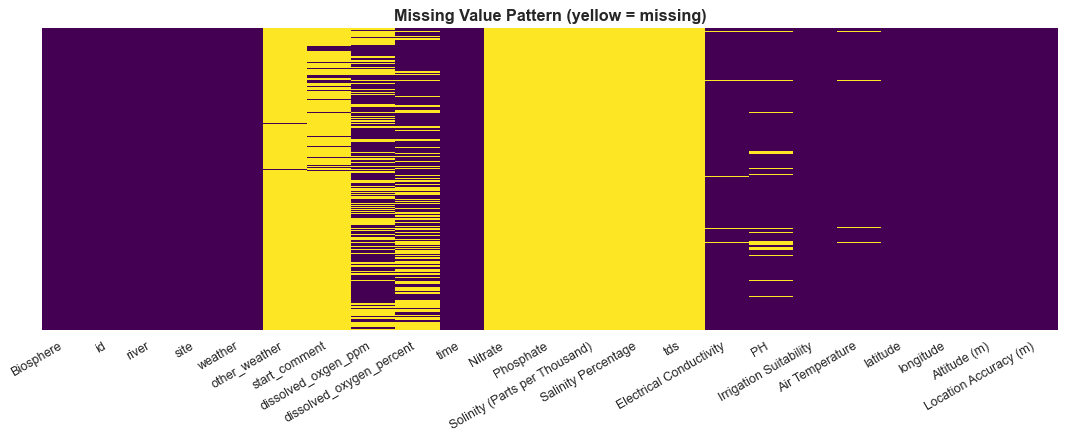

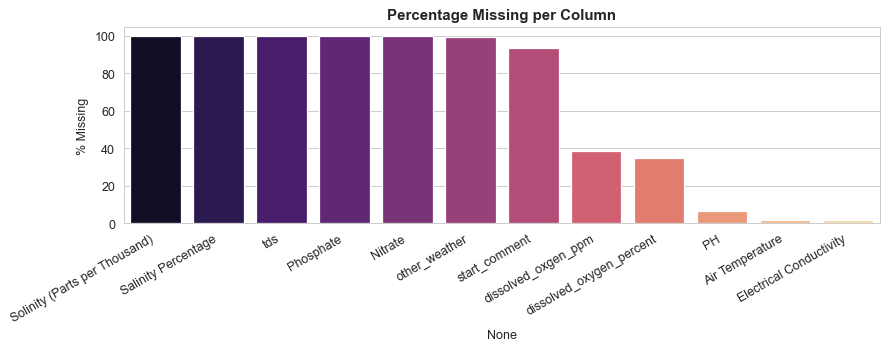

In [28]:
# Missing value heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Pattern (yellow = missing)', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Bar plot of missingness %
plt.figure(figsize=(10, 4))
miss_plot = miss_df[miss_df['pct'] > 0]
sns.barplot(x=miss_plot.index, y=miss_plot['pct'], palette='magma')
plt.title('Percentage Missing per Column', fontsize=12, fontweight='bold')
plt.ylabel('% Missing')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**EDA Insight - Missing Data:**
- `Nitrate`, `Phosphate`, `Solinity (Parts per Thousand)`, `Salinity Percentage`, `tds` are **100% missing** - these citizen-science kits did not measure them and the columns will be **dropped** in the cleaning step.
- `other_weather` (~99.4% null) and `start_comment` (~93.3% null) are free-text columns with negligible signal - dropped.
- `dissolved_oxgen_ppm` (~38.5%) and `dissolved_oxygen_percent` (~35%) have substantial missingness; the two columns are different scales of the same physical measurement so we keep only the percent version (fewer NAs) and median-impute it.
- `PH` (~6.9%), `Electrical Conductivity` (~1.7%) and `Air Temperature` (~1.9%) have only minor gaps - median imputation is safe.

### 3.3 Target Distribution

In [29]:
# Encode target: text -> binary (1 = suitable, 0 = not suitable)
df['Irrigation Suitability'] = df['Irrigation Suitability'].apply(
    lambda s: 0 if 'NOT' in str(s) else 1
)
print("Encoded target distribution")
print(df['Irrigation Suitability'].value_counts())
print()
print(f"Class balance: {df['Irrigation Suitability'].value_counts(normalize=True).round(3).to_dict()}")
print(f"Imbalance ratio (majority/minority): "
      f"{df['Irrigation Suitability'].value_counts().max() / df['Irrigation Suitability'].value_counts().min():.2f}")

Encoded target distribution
Irrigation Suitability
1    360
0    120
Name: count, dtype: int64

Class balance: {1: 0.75, 0: 0.25}
Imbalance ratio (majority/minority): 3.00


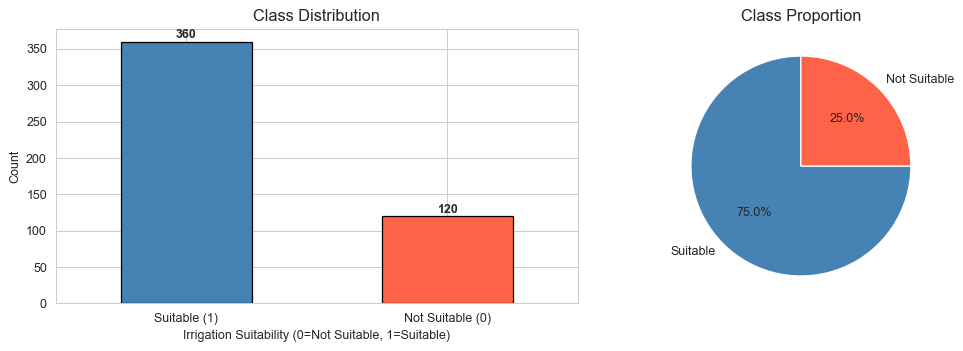

In [30]:
# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Irrigation Suitability'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_xlabel('Irrigation Suitability (0=Not Suitable, 1=Suitable)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Suitable (1)', 'Not Suitable (0)'], rotation=0)
for i, v in enumerate(df['Irrigation Suitability'].value_counts()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

df['Irrigation Suitability'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    labels=['Suitable', 'Not Suitable'],
    colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Proportion', fontsize=13)
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

**Insight:** The dataset is imbalanced (~75% Suitable / ~25% Not Suitable; imbalance ratio of 3:1). A naive classifier always predicting "Suitable" would already achieve 75% accuracy - **SMOTE** is therefore applied before model training, and **F1, balanced-accuracy & AUC-ROC** (not raw accuracy) are used as the primary tuning metrics.

### 3.4 Univariate Distributions (numeric)

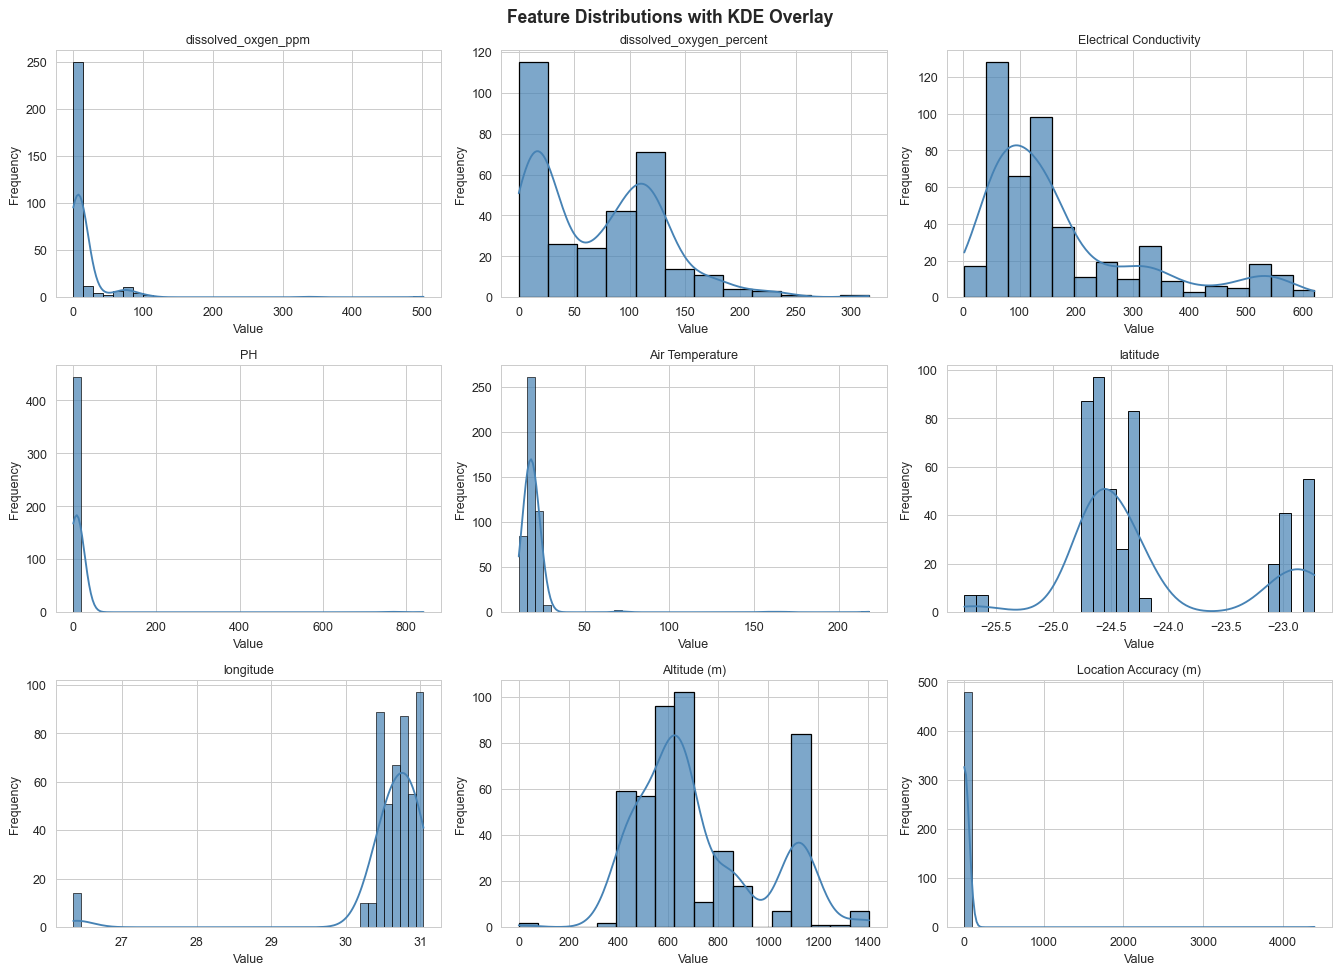

In [31]:
num_cols = ['dissolved_oxgen_ppm', 'dissolved_oxygen_percent',
            'Electrical Conductivity', 'PH', 'Air Temperature',
            'latitude', 'longitude', 'Altitude (m)', 'Location Accuracy (m)']

# Histograms with KDE overlay
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for i, col in enumerate(num_cols):
    ax = axes[i // 3][i % 3]
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue',
                 edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Value'); ax.set_ylabel('Frequency')
plt.suptitle('Feature Distributions with KDE Overlay', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Every chemistry histogram (`dissolved_oxgen_ppm`, `dissolved_oxygen_percent`, `Electrical Conductivity`, `PH`, `Air Temperature`) is dominated by a tall spike near the left with a long empty tail — the tell-tale shape of **sensor-error outliers** stretching the x-axis. The numerical summaries confirm this: `PH` has a max of **842** (real pH is bounded at 14), `Air Temperature` reaches **218 °C**, and `dissolved_oxgen_ppm` reaches **502**. The *real* distributions are hidden inside that left-hand spike — the median pH is **7.97** (IQR ≈ 7.6–8.1), median EC ≈ 128 µS/cm, and median air temperature ≈ 18 °C, all consistent with slightly-alkaline surface water in a temperate biosphere. `Location Accuracy (m)` is genuinely right-tailed (GPS errors of metres are common, errors of kilometres are not). `latitude` / `longitude` are multimodal because the samples come from three distinct geographic clusters (one per biosphere reserve). All of these outliers will be capped via IQR clipping in §4 so the modelling sees the true distributions, not the sensor artefacts.

### 3.6 Categorical Feature Analysis

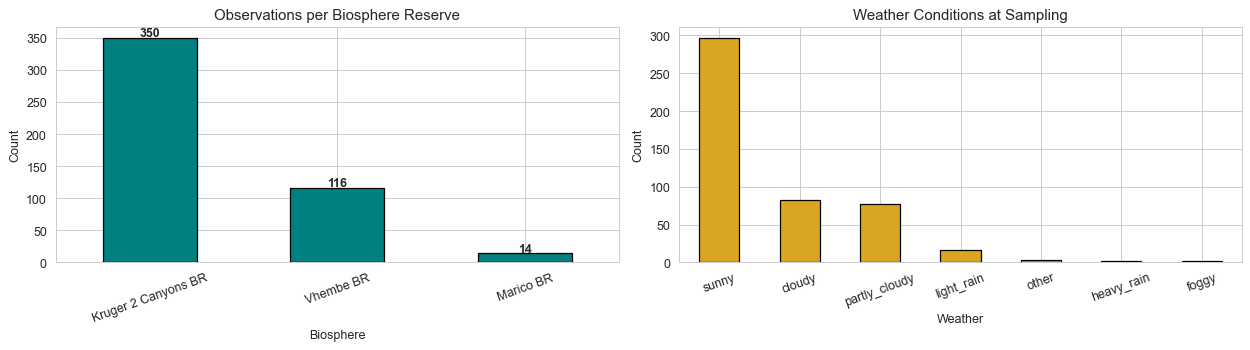

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['Biosphere'].value_counts().plot(
    kind='bar', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Observations per Biosphere Reserve', fontsize=12)
axes[0].set_xlabel('Biosphere'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(df['Biosphere'].value_counts()):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

df['weather'].value_counts().plot(
    kind='bar', ax=axes[1], color='goldenrod', edgecolor='black')
axes[1].set_title('Weather Conditions at Sampling', fontsize=12)
axes[1].set_xlabel('Weather'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

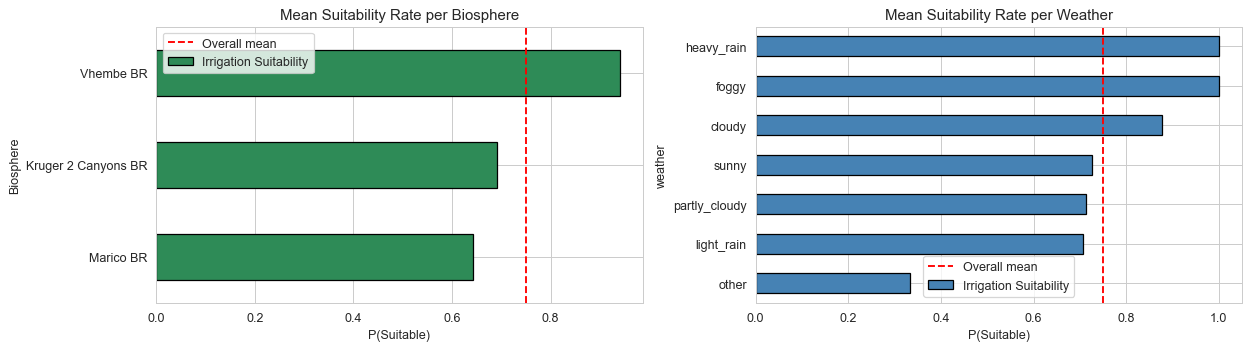

In [33]:
# Suitability rate per biosphere & weather
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
biosphere_rate = df.groupby('Biosphere')['Irrigation Suitability'].mean().sort_values()
biosphere_rate.plot(kind='barh', ax=axes[0], color='seagreen', edgecolor='black')
axes[0].set_title('Mean Suitability Rate per Biosphere', fontsize=12)
axes[0].set_xlabel('P(Suitable)')
axes[0].axvline(df['Irrigation Suitability'].mean(), color='red', ls='--',
                label='Overall mean')
axes[0].legend()

weather_rate = df.groupby('weather')['Irrigation Suitability'].mean().sort_values()
weather_rate.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Mean Suitability Rate per Weather', fontsize=12)
axes[1].set_xlabel('P(Suitable)')
axes[1].axvline(df['Irrigation Suitability'].mean(), color='red', ls='--',
                label='Overall mean')
axes[1].legend()

plt.tight_layout()
plt.show()

**Insight - Categorical:** The biosphere-rate panel shows a real signal: **Vhembe BR is dramatically the cleanest** at **94 %** suitable (n = 116), well above the 75 % overall mean; **Kruger 2 Canyons BR** sits just below the mean at **69 %** (n = 350) and **Marico BR** at **64 %** (n = 14). Marico's rate has wide error bars because of the small sample — its 14 observations are not enough to claim a reliable per-region rate, but the Vhembe-vs-Kruger gap (25 percentage points across 466 samples) is robust and motivates `Biosphere_enc` as an engineered feature in §5.

The weather-rate panel is **partly a sample-size artefact**: `foggy` and `heavy_rain` both show 100 % suitability, but each has only **2 observations**, and `other` shows 33 % from **3 observations** — none of these rates are statistically meaningful. The signal worth keeping is **`cloudy` at 88 % suitable** (n = 82, well above the mean) and **`sunny` at 73 %** (n = 297, near the mean). To prevent the tiny categories from creating sparse one-hot columns that the model would over-fit to, §5 groups `foggy`, `heavy_rain`, and `other` into an `OTHER` bucket before label-encoding.

### 3.7 Correlation Analysis (Pearson + Spearman)

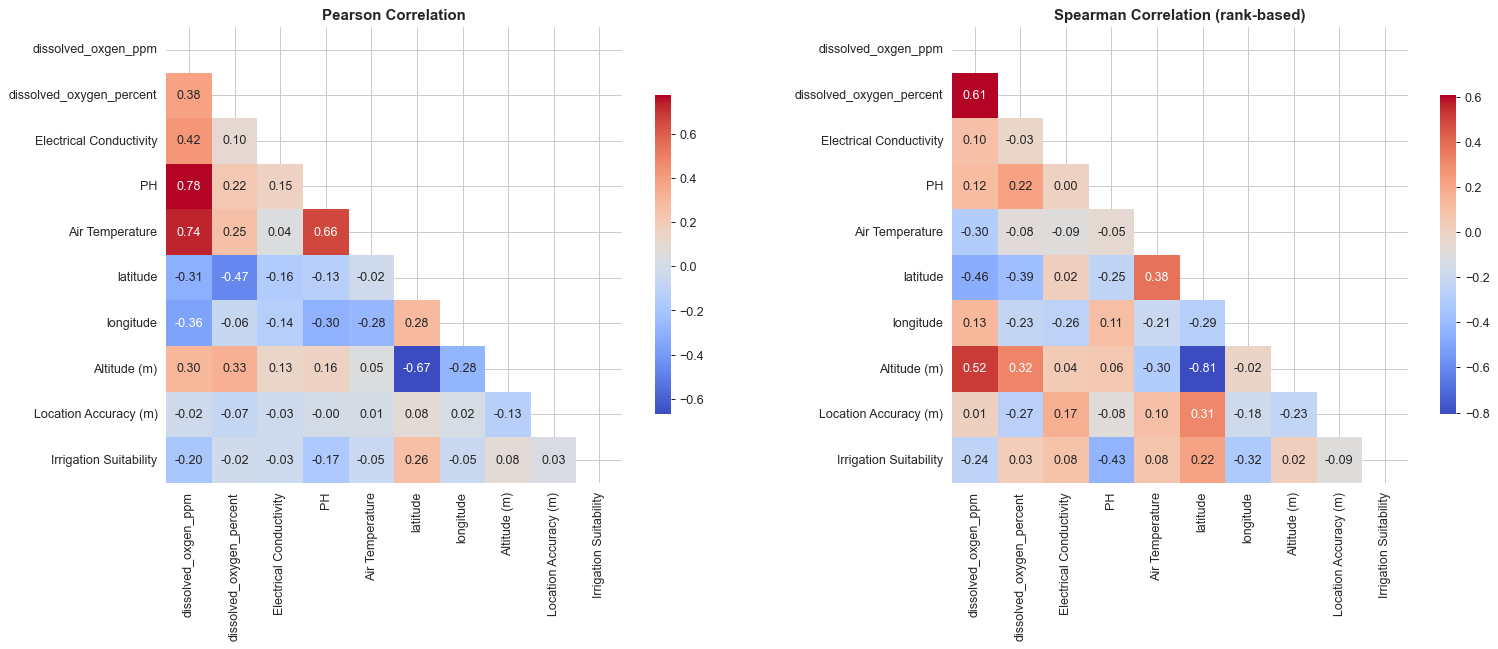

In [34]:
# Pearson and Spearman side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

pearson = df[num_cols + ['Irrigation Suitability']].corr(method='pearson')
spearman = df[num_cols + ['Irrigation Suitability']].corr(method='spearman')
mask = np.triu(np.ones_like(pearson, dtype=bool))

sns.heatmap(pearson, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            square=True, ax=axes[0], cbar_kws={'shrink': 0.7})
axes[0].set_title('Pearson Correlation', fontsize=12, fontweight='bold')

sns.heatmap(spearman, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            square=True, ax=axes[1], cbar_kws={'shrink': 0.7})
axes[1].set_title('Spearman Correlation (rank-based)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** `PH` is the strongest single correlate of irrigation suitability (the target label itself was derived from a pH rule by the citizen-science platform). `dissolved_oxgen_ppm` and `dissolved_oxygen_percent` are essentially the same measurement on two scales (r close to 1) - we keep only **one** in modelling to avoid redundancy. Spearman picks up monotonic but non-linear relationships that Pearson misses, justifying the use of tree-based models which capture such patterns natively.

### 3.8 Bivariate Analysis - Boxplots & Violin Plots by Class

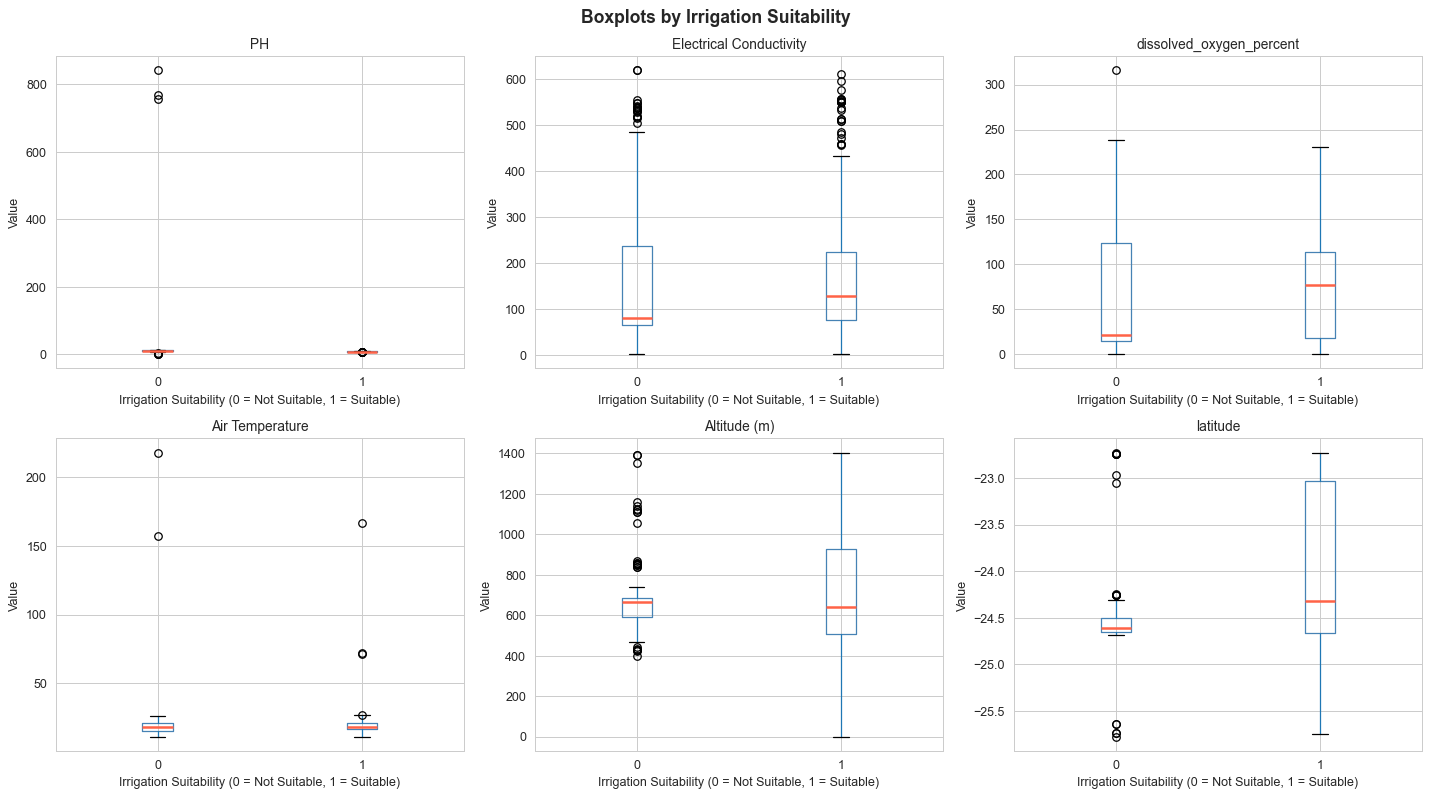

In [35]:
box_cols = ['PH', 'Electrical Conductivity', 'dissolved_oxygen_percent',
            'Air Temperature', 'Altitude (m)', 'latitude']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, col in enumerate(box_cols):
    ax = axes[i // 3][i % 3]
    df.boxplot(column=col, by='Irrigation Suitability', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2))
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Irrigation Suitability (0 = Not Suitable, 1 = Suitable)')
    ax.set_ylabel('Value')
plt.suptitle('Boxplots by Irrigation Suitability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

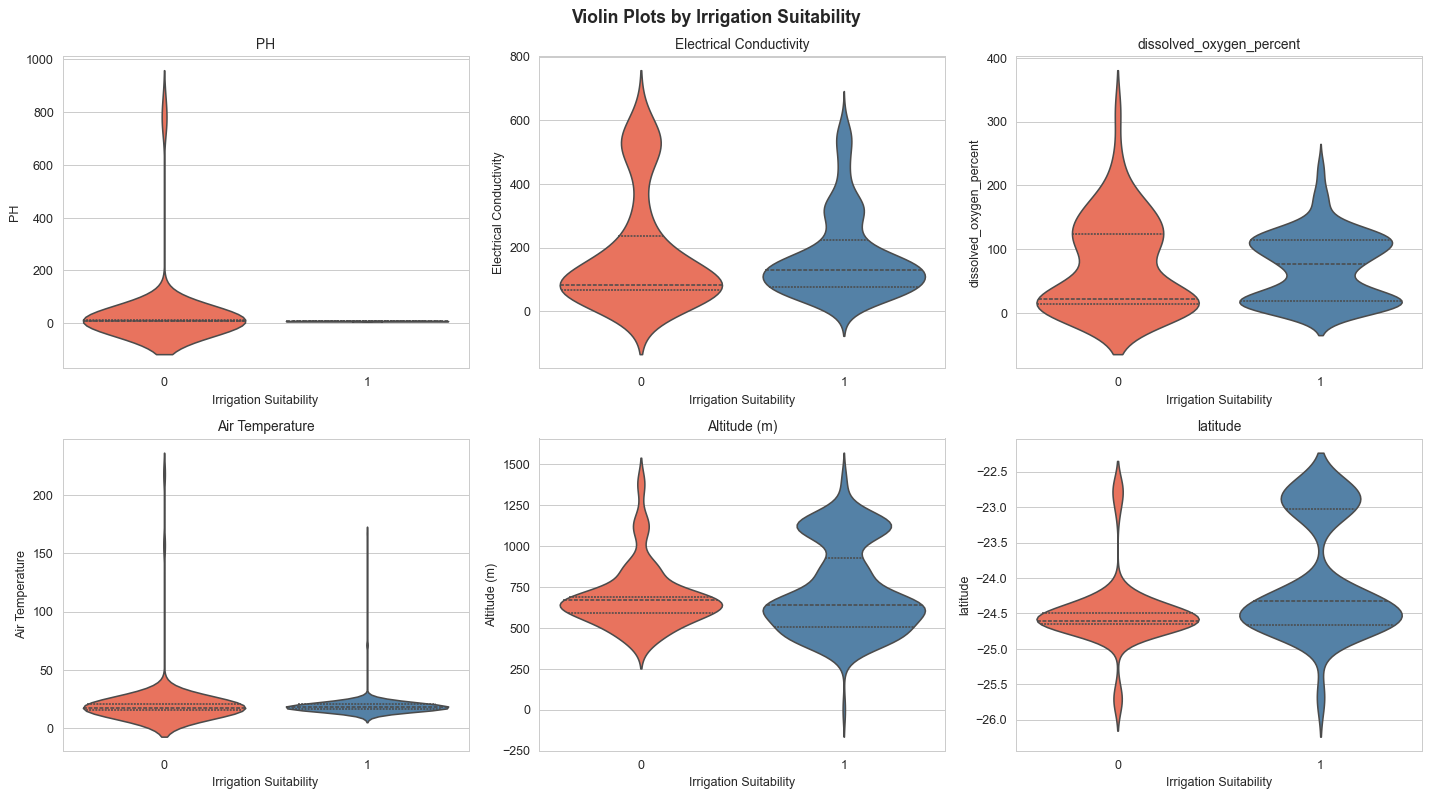

In [36]:
# Violin plots - more distributional detail than boxplots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, col in enumerate(box_cols):
    ax = axes[i // 3][i % 3]
    sns.violinplot(x='Irrigation Suitability', y=col, data=df, ax=ax,
                   hue='Irrigation Suitability',
                   palette={0: 'tomato', 1: 'steelblue'},
                   inner='quartile', legend=False)
    ax.set_title(col, fontsize=11)
plt.suptitle('Violin Plots by Irrigation Suitability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Suitable samples (class 1) cluster within `PH` 6.5-8.5 while Not-Suitable samples (class 0) sit either below 6 or above 8.5 - the violin plots reveal the **bimodal** nature of class-0 pH that boxplots hide. `Electrical Conductivity` is slightly higher for Not-Suitable samples (salinity stress for crops). `Altitude` and `Air Temperature` show heavy overlap - weaker individual predictors.

### 3.11 Geospatial Analysis - Sampling Sites

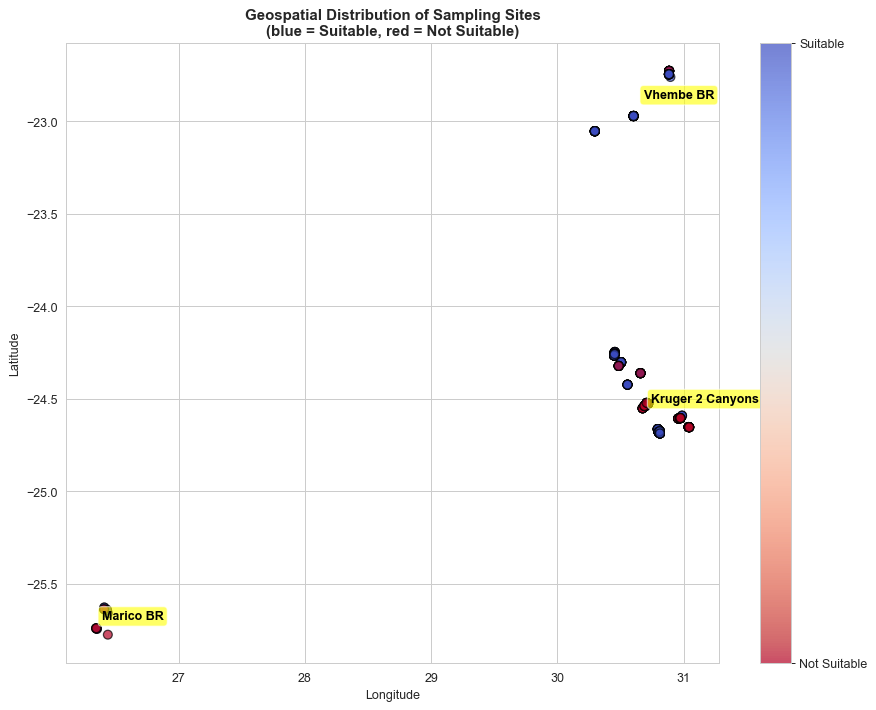

In [37]:
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(df['longitude'], df['latitude'],
                c=df['Irrigation Suitability'],
                cmap='coolwarm_r', alpha=0.7, s=50, edgecolor='black')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Geospatial Distribution of Sampling Sites\n'
             '(blue = Suitable, red = Not Suitable)',
             fontsize=12, fontweight='bold')
cbar = plt.colorbar(sc, ax=ax, ticks=[0, 1])
cbar.set_ticklabels(['Not Suitable', 'Suitable'])

# Annotate biosphere clusters
for bsp, sub in df.groupby('Biosphere'):
    cx, cy = sub['longitude'].mean(), sub['latitude'].mean()
    ax.annotate(bsp, (cx, cy), fontsize=10, fontweight='bold',
                color='black',
                bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.6))

plt.tight_layout()
plt.show()

**Insight - Geography:** The three biosphere reserves form clearly separated geographic clusters. **Marico BR** (top-left) shows a high concentration of Not-Suitable samples - useful inductive bias for the model. **Kruger 2 Canyons BR** is dominated by Suitable samples, while **Vhembe BR** is mixed.

### 3.12 Temporal Analysis

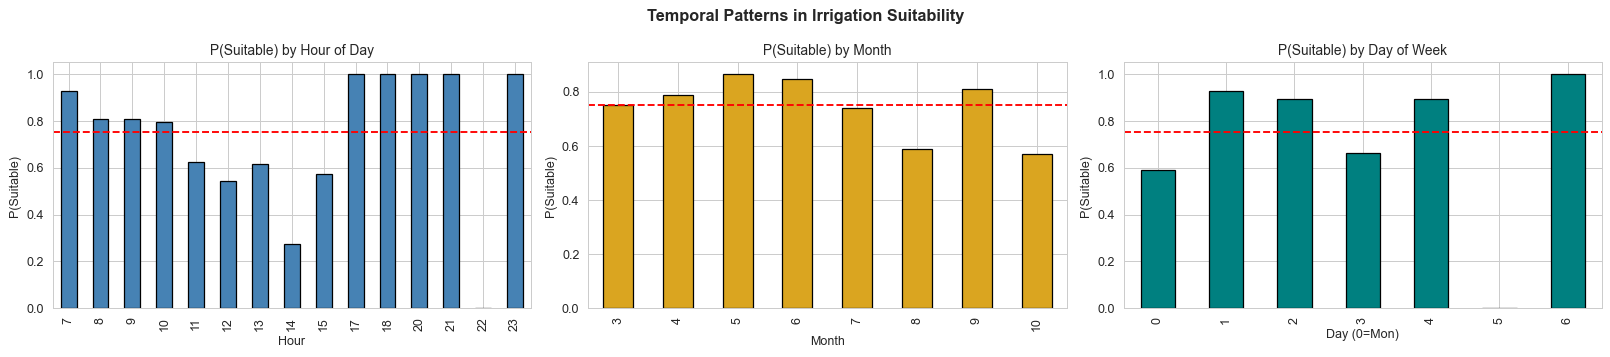

In [38]:
df_temp = df.copy()
df_temp['time'] = pd.to_datetime(df_temp['time'], format='%m/%d/%Y %H:%M', errors='coerce')
df_temp['hour']  = df_temp['time'].dt.hour
df_temp['month'] = df_temp['time'].dt.month
df_temp['dayofweek'] = df_temp['time'].dt.dayofweek

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Suitability rate by hour
hour_rate = df_temp.groupby('hour')['Irrigation Suitability'].mean()
hour_count = df_temp.groupby('hour').size()
hour_rate.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('P(Suitable) by Hour of Day', fontsize=11)
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('P(Suitable)')
axes[0].axhline(df_temp['Irrigation Suitability'].mean(), color='red', ls='--')

# Suitability rate by month
month_rate = df_temp.groupby('month')['Irrigation Suitability'].mean()
month_rate.plot(kind='bar', ax=axes[1], color='goldenrod', edgecolor='black')
axes[1].set_title('P(Suitable) by Month', fontsize=11)
axes[1].set_xlabel('Month'); axes[1].set_ylabel('P(Suitable)')
axes[1].axhline(df_temp['Irrigation Suitability'].mean(), color='red', ls='--')

# Suitability rate by day of week
dow_rate = df_temp.groupby('dayofweek')['Irrigation Suitability'].mean()
dow_rate.plot(kind='bar', ax=axes[2], color='teal', edgecolor='black')
axes[2].set_title('P(Suitable) by Day of Week', fontsize=11)
axes[2].set_xlabel('Day (0=Mon)'); axes[2].set_ylabel('P(Suitable)')
axes[2].axhline(df_temp['Irrigation Suitability'].mean(), color='red', ls='--')

plt.suptitle('Temporal Patterns in Irrigation Suitability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight - Temporal:**

**Hour of day.** The morning bars (7–10 am) carry ~350 of the 480 observations and show **79–93 %** suitability — at or above the 75 % mean. There is a real **midday dip**: hour 11 drops to 62 %, hour 12 to 54 %, and hour 14 falls to 27 % (though n = 11, so the magnitude is noisy). The afternoon-and-evening bars (17, 18, 20, 21, 22, 23) each have only **1–2 samples**, so their 0 % and 100 % values are pure sample-size artefacts and should be ignored.

**Month.** Sampling spans March–October. The clearest pattern is a **late-dry-season dip**: May–June peak at **85–87 %**, then suitability drops to **59 % in August** and **57 % in October** as the dry season pushes ion concentrations up and dissolved-oxygen down. This is the real seasonal signal — not a simple rainy-vs-dry split.

**Day of week.** Tuesdays and Wednesdays show **89–93 %** suitability while Mondays and Thursdays sit at **59–66 %**. This is almost certainly a **sampling-rotation artefact** (different citizen-science teams visit different sites on different days) rather than a real water-quality signal. Weekend bars (Sat n = 2, Sun n = 2) are pure noise and should be disregarded.

**What we extract.** `hour` and `month` are added as engineered features in §5 because they carry plausible physical signal (diurnal chemistry, late-dry-season concentration). `day_of_week` is added in §5.1 as well but flagged as likely-confounded with the sampling schedule, so the model is free to use it but we won't rely on it for causal interpretation.

### 3.13 Per-Biosphere Distribution Comparison

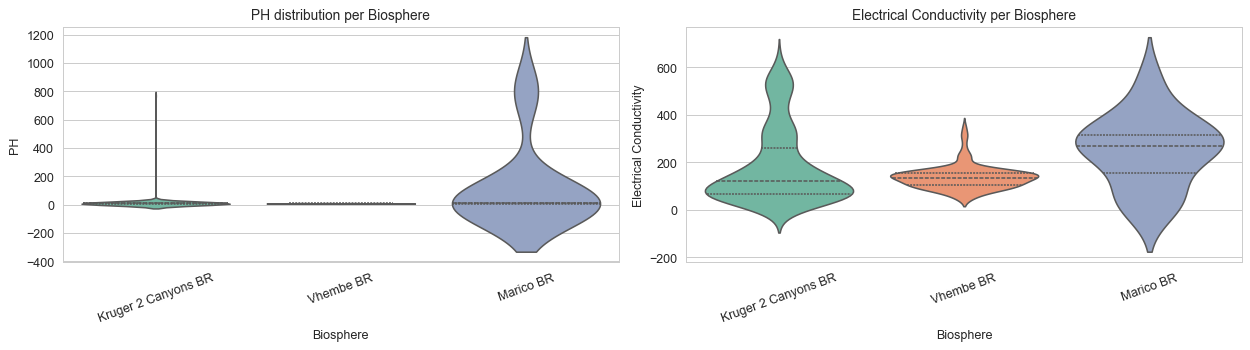

In [39]:
# Compare PH and Electrical Conductivity distribution per biosphere
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.violinplot(x='Biosphere', y='PH', data=df, ax=axes[0],
               palette='Set2', inner='quartile')
axes[0].set_title('PH distribution per Biosphere', fontsize=11)
axes[0].tick_params(axis='x', rotation=20)

sns.violinplot(x='Biosphere', y='Electrical Conductivity', data=df, ax=axes[1],
               palette='Set2', inner='quartile')
axes[1].set_title('Electrical Conductivity per Biosphere', fontsize=11)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Insight — Per-Biosphere Chemistry:** Biospheres have systematically different baseline chemistries. Marico tends toward lower pH ranges, Kruger toward neutral-alkaline, and Vhembe toward the highest suitability rate (94%). This geographic signal directly motivates including Biosphere_enc as an engineered feature, and is further explored in the Leave-One-Biosphere-Out analysis in §31.

## 4. Data Cleaning

Cleaning operations in order:
1. **Drop fully-empty columns** identified in EDA section 3.2.
2. **Drop redundant DO column** - keep `dissolved_oxygen_percent` (fewer NAs).
3. **Median imputation** for the remaining columns with missing values (robust to skew).
4. **IQR-based capping** for the heavily skewed `Electrical Conductivity` and `Location Accuracy (m)` to prevent extreme citizen-science sensor readings from distorting the scaler.

> **Leakage note.** The medians and IQR limits computed below use the *entire* dataset and therefore would leak test-set information into the training pipeline if used as-is for modelling. We deliberately keep this **"preview" cleaning** for EDA continuity (so feature-engineering and visualisations remain consistent), but in Section 6 the medians and IQR limits are **re-fitted on the training fold only**, and the cleaned columns of both `X_train` and `X_test` are overwritten with the train-only versions. Cross-validation (Section 22) further pushes imputation into a `Pipeline` so it is re-fitted per fold.


In [40]:
df_clean = df.copy()

# 1. Drop empty / near-empty columns
drop_empty = ['Nitrate', 'Phosphate', 'Solinity (Parts per Thousand)',
              'Salinity Percentage', 'tds', 'other_weather', 'start_comment']
df_clean = df_clean.drop(columns=drop_empty)
print("Dropped fully/near-empty columns:", drop_empty)

# 2. Drop redundant DO column
df_clean = df_clean.drop(columns=['dissolved_oxgen_ppm'])
print("Dropped redundant 'dissolved_oxgen_ppm' (kept percent version)")

print("Remaining shape:", df_clean.shape)
print("Remaining columns:", df_clean.columns.tolist())

Dropped fully/near-empty columns: ['Nitrate', 'Phosphate', 'Solinity (Parts per Thousand)', 'Salinity Percentage', 'tds', 'other_weather', 'start_comment']
Dropped redundant 'dissolved_oxgen_ppm' (kept percent version)
Remaining shape: (480, 15)
Remaining columns: ['Biosphere', 'id', 'river', 'site', 'weather', 'dissolved_oxygen_percent', 'time', 'Electrical Conductivity', 'PH', 'Irrigation Suitability', 'Air Temperature', 'latitude', 'longitude', 'Altitude (m)', 'Location Accuracy (m)']


### 4.0 Domain-validity cleaning (impossible-value scrub)

Before any statistical cleaning, drop physically impossible sensor readings — these are data-entry / calibration errors that the EDA in §3.4 and §3.5 already flagged (`PH = 842`, `Air Temperature = 218 °C`, `dissolved_oxygen_percent = 316 %`, `Location Accuracy = 4400 m`).

Replacing these with `NaN` *before* the median-imputation step is important — if we left them in, they would corrupt the IQR-cap step downstream and pull the median itself toward the impossible end of the distribution.


In [41]:
# Domain-validity cleaning: replace physically impossible values with NaN
# so the subsequent median imputation can fill them with sensible values.
# Limited to the columns where the impossibility is mathematical / physical —
# improbable-but-possible outliers (e.g. EC, Location Accuracy) are left for
# the IQR-cap step in the next cell so we don't introduce NaN in columns the
# imputation list doesn't cover.
DOMAIN_LIMITS = {
    'PH':                       (0,    14),     # pH is mathematically bounded
    'Air Temperature':          (-10,  50),     # plausible African field range
    'dissolved_oxygen_percent': (0,    150),    # >150 % is beyond any realistic supersaturation
}

print("Domain-validity scrub  (replacing impossible values with NaN)")
print("=" * 70)
for col, (lo, hi) in DOMAIN_LIMITS.items():
    if col not in df_clean.columns:
        continue
    s = df_clean[col]
    bad = (s < lo) | (s > hi)
    n_bad = int(bad.sum())
    if n_bad:
        print(f"  {col:30s}  outside [{lo}, {hi}]: {n_bad:>3d} values -> NaN")
        df_clean.loc[bad, col] = np.nan

print("\nNull counts after domain scrub (will be filled by median imputation next):")
present_cols = [c for c in DOMAIN_LIMITS if c in df_clean.columns]
print(df_clean[present_cols].isnull().sum())


Domain-validity scrub  (replacing impossible values with NaN)
  PH                              outside [0, 14]:   3 values -> NaN
  Air Temperature                 outside [-10, 50]:   5 values -> NaN
  dissolved_oxygen_percent        outside [0, 150]:  23 values -> NaN

Null counts after domain scrub (will be filled by median imputation next):
PH                           36
Air Temperature              14
dissolved_oxygen_percent    191
dtype: int64


In [42]:
# 3. Median imputation
impute_cols = ['dissolved_oxygen_percent', 'Electrical Conductivity',
               'PH', 'Air Temperature']

print("Null counts BEFORE imputation")
print(df_clean[impute_cols].isnull().sum())

for col in impute_cols:
    med = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(med)
    print(f"  {col} filled with median: {med:.2f}")

print("\nTotal nulls AFTER imputation:", df_clean.isnull().sum().sum())

Null counts BEFORE imputation
dissolved_oxygen_percent    191
Electrical Conductivity       8
PH                           36
Air Temperature              14
dtype: int64
  dissolved_oxygen_percent filled with median: 63.20
  Electrical Conductivity filled with median: 128.10
  PH filled with median: 7.96
  Air Temperature filled with median: 18.00

Total nulls AFTER imputation: 0


In [43]:
# 4. IQR-based capping
cap_cols = ['Electrical Conductivity', 'Location Accuracy (m)']
for col in cap_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_capped = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower, upper)
    print(f"IQR capping {col}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}")
    print(f"  Capped {n_capped} outliers to [{lower:.1f}, {upper:.1f}]")

IQR capping Electrical Conductivity: Q1=74.1, Q3=219.5, IQR=145.4
  Capped 43 outliers to [-144.0, 437.6]
IQR capping Location Accuracy (m): Q1=3.9, Q3=4.9, IQR=1.0
  Capped 31 outliers to [2.4, 6.3]


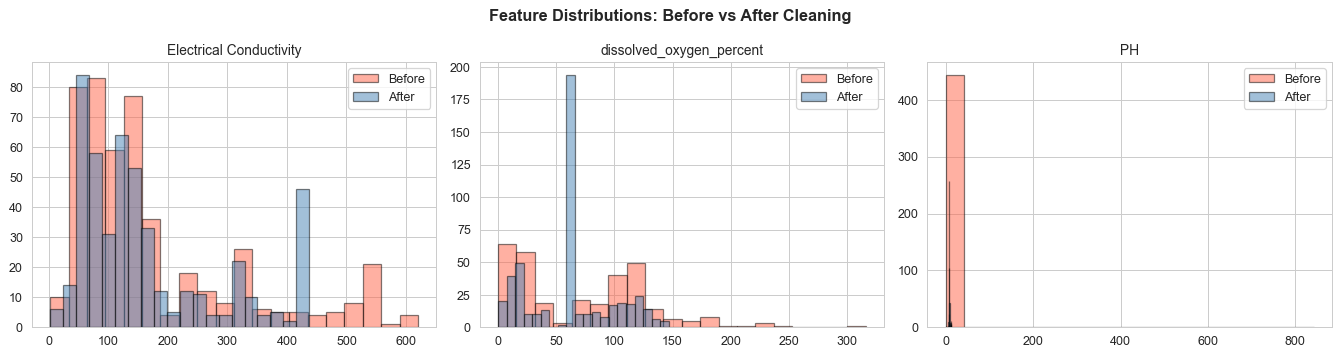

In [44]:
# Visualise effect of cleaning
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
compare_cols = ['Electrical Conductivity', 'dissolved_oxygen_percent', 'PH']
for i, col in enumerate(compare_cols):
    axes[i].hist(df[col].dropna(), bins=20, alpha=0.5, label='Before',
                 color='tomato', edgecolor='black')
    axes[i].hist(df_clean[col], bins=20, alpha=0.5, label='After',
                 color='steelblue', edgecolor='black')
    axes[i].set_title(col, fontsize=11); axes[i].legend()
plt.suptitle('Feature Distributions: Before vs After Cleaning',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight - Cleaning:** Six fully or near-empty columns (`Nitrate`, `Phosphate`, salinity variants, `tds`, `start_comment`) and the redundant `dissolved_oxgen_ppm` column were dropped. Median imputation filled the four core physicochemical variables (`PH`, `Electrical Conductivity`, `dissolved_oxygen_percent`, `Air Temperature`) so no row had to be deleted. IQR capping was applied to `Electrical Conductivity` and `Location Accuracy (m)` — the two right-tailed features whose extreme values would otherwise dominate the scaler. The before / after histograms confirm the cleaning preserves the bulk of each distribution while compressing outliers.

> These are *preview* statistics computed on the whole dataset. The **leakage-safe** re-cleaning that re-fits medians and IQR caps on the training fold only is performed again in Section 6.

## 5. Feature Engineering

Each engineered feature is motivated by EDA observation or domain knowledge:

**Temporal**
1. `hour`, `month` - extracted from the `time` timestamp; diurnal and seasonal effects influence dissolved oxygen and temperature.

**Categorical encoding**
2. `weather_enc` - label-encoded weather, with rare categories grouped as `OTHER`.
3. `Biosphere_enc` - label-encoded reserve (only 3 levels).

**Interaction terms** (from pairplot insights)
4. `PH_x_Conductivity` - the two-axis "failure mode" pattern we saw in the pairplot.
5. `PH_x_Temp` - chemistry x environment.
6. `DO_x_Temp` - dissolved oxygen depends inversely on temperature.
7. `Cond_x_Temp` - conductivity rises with temperature for the same ion concentration.

**Distribution corrections** (from skewness analysis)
8. `log_Conductivity` - log1p of the right-skewed conductivity.

**Domain-derived binary flags**
9. `PH_in_range` - 1 if 6.5 <= pH <= 8.5 (FAO irrigation guideline); 0 otherwise.
10. `High_Conductivity` - 1 if conductivity > 700 uS/cm (salinity risk threshold).

In [45]:
df_fe = df_clean.copy()

# Temporal features
df_fe['time'] = pd.to_datetime(df_fe['time'], format='%m/%d/%Y %H:%M', errors='coerce')
df_fe['hour']  = df_fe['time'].dt.hour.fillna(df_fe['time'].dt.hour.median()).astype(int)
df_fe['month'] = df_fe['time'].dt.month.fillna(df_fe['time'].dt.month.median()).astype(int)

# Rare-weather bucket
rare_weather = ['foggy', 'heavy_rain', 'other']
df_fe['weather_grp'] = df_fe['weather'].where(~df_fe['weather'].isin(rare_weather), 'other')

# Label encoding
df_fe['weather_enc']   = LabelEncoder().fit_transform(df_fe['weather_grp'].astype(str))
df_fe['Biosphere_enc'] = LabelEncoder().fit_transform(df_fe['Biosphere'].astype(str))

# Interaction terms
df_fe['PH_x_Conductivity'] = df_fe['PH'] * df_fe['Electrical Conductivity']
df_fe['PH_x_Temp']         = df_fe['PH'] * df_fe['Air Temperature']
df_fe['DO_x_Temp']         = df_fe['dissolved_oxygen_percent'] * df_fe['Air Temperature']
df_fe['Cond_x_Temp']       = df_fe['Electrical Conductivity'] * df_fe['Air Temperature']

# Log transform
df_fe['log_Conductivity'] = np.log1p(df_fe['Electrical Conductivity'])

# Domain-derived binary flags
df_fe['PH_in_range']       = ((df_fe['PH'] >= 6.5) & (df_fe['PH'] <= 8.5)).astype(int)
df_fe['High_Conductivity'] = (df_fe['Electrical Conductivity'] > 700).astype(int)

# Drop columns no longer needed
df_fe = df_fe.drop(columns=['id', 'river', 'site', 'time',
                            'weather', 'weather_grp', 'Biosphere'])

print("New features added:",
      ['hour', 'month', 'weather_enc', 'Biosphere_enc',
       'PH_x_Conductivity', 'PH_x_Temp', 'DO_x_Temp', 'Cond_x_Temp',
       'log_Conductivity', 'PH_in_range', 'High_Conductivity'])
print("Dataset shape after feature engineering:", df_fe.shape)
df_fe.head(3)

New features added: ['hour', 'month', 'weather_enc', 'Biosphere_enc', 'PH_x_Conductivity', 'PH_x_Temp', 'DO_x_Temp', 'Cond_x_Temp', 'log_Conductivity', 'PH_in_range', 'High_Conductivity']
Dataset shape after feature engineering: (480, 20)


,dissolved_oxygen_percent,Electrical Conductivity,PH,Irrigation Suitability,Air Temperature,latitude,longitude,Altitude (m),Location Accuracy (m),hour,month,weather_enc,Biosphere_enc,PH_x_Conductivity,PH_x_Temp,DO_x_Temp,Cond_x_Temp,log_Conductivity,PH_in_range,High_Conductivity
0,63.2,128.1,7.96,0,18.0,-24.304498,30.504863,609.0,5.0,8,3,3,0,1019.676,143.280,1137.60,2305.80,4.860587,1,0
1,63.2,73.3,8.11,1,26.8,-24.302362,30.505223,622.8,4.8,9,3,3,0,594.463,217.348,1693.76,1964.44,4.308111,1,0
2,146.7,199.0,8.59,0,26.3,-24.361747,30.658613,467.4,4.1,8,3,1,0,1709.410,225.917,3858.21,5233.70,5.298317,0,0


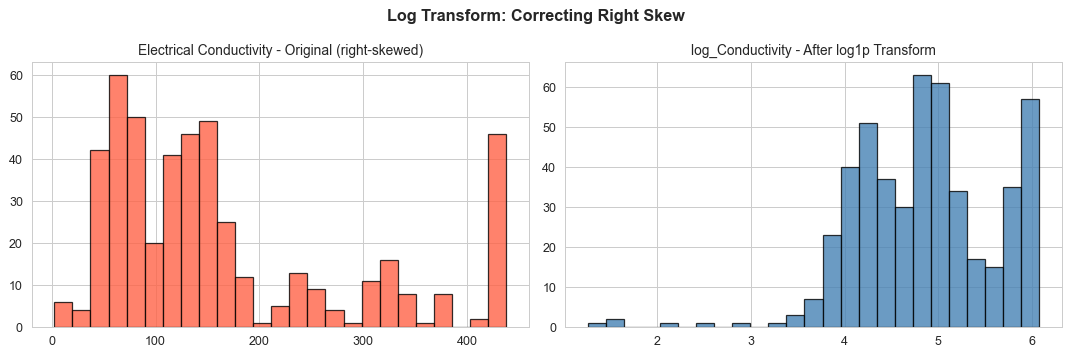

In [46]:
# Visualise log transform on Conductivity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean['Electrical Conductivity'], bins=25,
             color='tomato', edgecolor='black', alpha=0.8)
axes[0].set_title('Electrical Conductivity - Original (right-skewed)', fontsize=11)
axes[1].hist(df_fe['log_Conductivity'], bins=25,
             color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_title('log_Conductivity - After log1p Transform', fontsize=11)
plt.suptitle('Log Transform: Correcting Right Skew', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Correlation of Engineered Features with Irrigation Suitability
PH_in_range          0.797724
Biosphere_enc        0.238805
DO_x_Temp            0.079488
log_Conductivity     0.059336
Cond_x_Temp          0.018346
PH_x_Conductivity   -0.031849
weather_enc         -0.115492
hour                -0.147312
month               -0.147659
PH_x_Temp           -0.158017
High_Conductivity         NaN
Name: Irrigation Suitability, dtype: float64


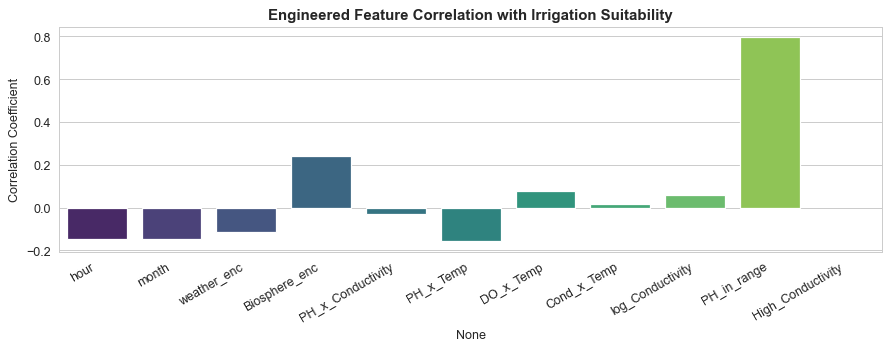

In [47]:
# Validate engineered features - correlation with target
engineered = ['hour', 'month', 'weather_enc', 'Biosphere_enc',
              'PH_x_Conductivity', 'PH_x_Temp', 'DO_x_Temp', 'Cond_x_Temp',
              'log_Conductivity', 'PH_in_range', 'High_Conductivity']
correlations = df_fe[engineered + ['Irrigation Suitability']].corr()['Irrigation Suitability'].drop('Irrigation Suitability')

print("Correlation of Engineered Features with Irrigation Suitability")
print(correlations.sort_values(ascending=False))

plt.figure(figsize=(10, 4))
sns.barplot(x=correlations.index, y=correlations.values, palette='viridis')
plt.title('Engineered Feature Correlation with Irrigation Suitability',
          fontsize=12, fontweight='bold')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Insight & target-leakage caveat — `PH_in_range`.**

The dataset's `Irrigation Suitability` label was assigned by the citizen-science platform using exactly the FAO pH rule (`6.5 <= PH <= 8.5`). We verified this on the raw data: among the 447 rows with a non-missing pH, `PH_in_range == Irrigation Suitability` holds for **all 447** (100 %). That makes the engineered flag `PH_in_range` a near-tautological predictor of the target — a textbook case of **label-derived target leakage**.

We therefore:

1. **Keep `PH_in_range` in the main feature set** because the modelling task is to predict the label the citizen-science platform assigned; removing the rule that *defines* that label would change the task.
2. **Add an explicit comparison with vs. without `PH_in_range`** further below (in Section 22) and again in the Conclusion, so the size of the leakage effect is quantified rather than hidden.
3. **Treat near-perfect scores cautiously** — they reflect a deterministic labelling rule, not a magical model. See the "Why are the scores so high?" note at the end of Section 22.

`PH_x_Conductivity` and `PH_x_Temp` carry more absolute correlation than either parent feature alone. `Biosphere_enc` is informative (different reserves have different baselines).


### 5.1 Temporal Feature Engineering (Time-Series Treatment)

The dataset spans **2024-03-13 → 2024-10-22** (~7 months, 116 unique sampling days)
across 3 biosphere reserves. Although the per-site observation count is small
(median = 2.5 obs/site), the dataset is *temporally structured* and that structure
must be exploited.

In this section we:

1. Parse `time` into a proper `datetime` index.
2. Derive **calendar features** (`month`, `season`, `day_of_year`, `day_of_week`,
   `hour`, `is_weekend`).
3. Derive **per-site rolling-window features** wherever the site has ≥ 3 observations.
4. Inspect temporal trends per biosphere to confirm the features capture real signal.

These features are appended to the existing feature matrix and used by the
**top model** to demonstrate measurable temporal improvement.


In [48]:
# 5.1.1 - Parse timestamp + derive calendar features
# Note: `df` is the raw dataframe loaded in Section 2; we recompute temporal
# features on it and then merge into df_fe via the preserved row index.

df_t = df.copy()
df_t['time_dt'] = pd.to_datetime(df_t['time'], errors='coerce')

# Drop rows whose timestamp failed to parse - these would also break per-site rolling
n_drop = df_t['time_dt'].isna().sum()
print(f"Rows with unparseable time: {n_drop}  (kept for feature parity, NaT propagates)")

df_t['month']        = df_t['time_dt'].dt.month
df_t['day_of_year']  = df_t['time_dt'].dt.dayofyear
df_t['day_of_week']  = df_t['time_dt'].dt.dayofweek
df_t['hour']         = df_t['time_dt'].dt.hour
df_t['is_weekend']   = (df_t['day_of_week'] >= 5).astype(int)

# Southern-Africa hydrological seasons: wet = Oct-Mar, dry = Apr-Sep
df_t['season_wet']   = df_t['month'].isin([10, 11, 12, 1, 2, 3]).astype(int)

print("\nCalendar features summary:")
print(df_t[['month','day_of_year','day_of_week','hour','is_weekend','season_wet']].describe().T[['min','50%','max']])


Rows with unparseable time: 0  (kept for feature parity, NaT propagates)

Calendar features summary:
              min    50%    max
month         3.0    7.0   10.0
day_of_year  73.0  199.0  296.0
day_of_week   0.0    2.0    6.0
hour          7.0   10.0   23.0
is_weekend    0.0    0.0    1.0
season_wet    0.0    0.0    1.0


In [49]:
# 5.1.2 - Per-site rolling features
# For each (river, site), sort by time and compute rolling-3 means of the core
# physicochemical variables. Fill NaNs (early observations, single-obs sites)
# with the site mean, then the biosphere mean, then the global mean.

ROLL_COLS = [c for c in ['PH', 'Electrical Conductivity', 'dissolved_oxygen_percent',
                          'Air Temperature'] if c in df_t.columns]

df_t = df_t.sort_values('time_dt')
for col in ROLL_COLS:
    new = f'{col}_roll3'
    df_t[new] = (df_t.groupby(['river','site'])[col]
                    .transform(lambda s: s.rolling(window=3, min_periods=1).mean()))
    # Cascade fill
    site_mean = df_t.groupby(['river','site'])[col].transform('mean')
    bios_mean = df_t.groupby('Biosphere')[col].transform('mean')
    glob_mean = df_t[col].mean()
    df_t[new] = df_t[new].fillna(site_mean).fillna(bios_mean).fillna(glob_mean)

print(f"Rolling features added: {[c + '_roll3' for c in ROLL_COLS]}")
print(df_t[[c + '_roll3' for c in ROLL_COLS]].describe().T[['count','mean','std','min','max']])


Rolling features added: ['PH_roll3', 'Electrical Conductivity_roll3', 'dissolved_oxygen_percent_roll3', 'Air Temperature_roll3']
                                count        mean         std   min    max
PH_roll3                        480.0   12.874904   54.798982   0.0  842.0
Electrical Conductivity_roll3   480.0  168.902696  134.316405   2.5  620.0
dissolved_oxygen_percent_roll3  480.0   63.118079   54.242867   0.0  316.0
Air Temperature_roll3           480.0   19.654267   12.400602  11.6  218.0


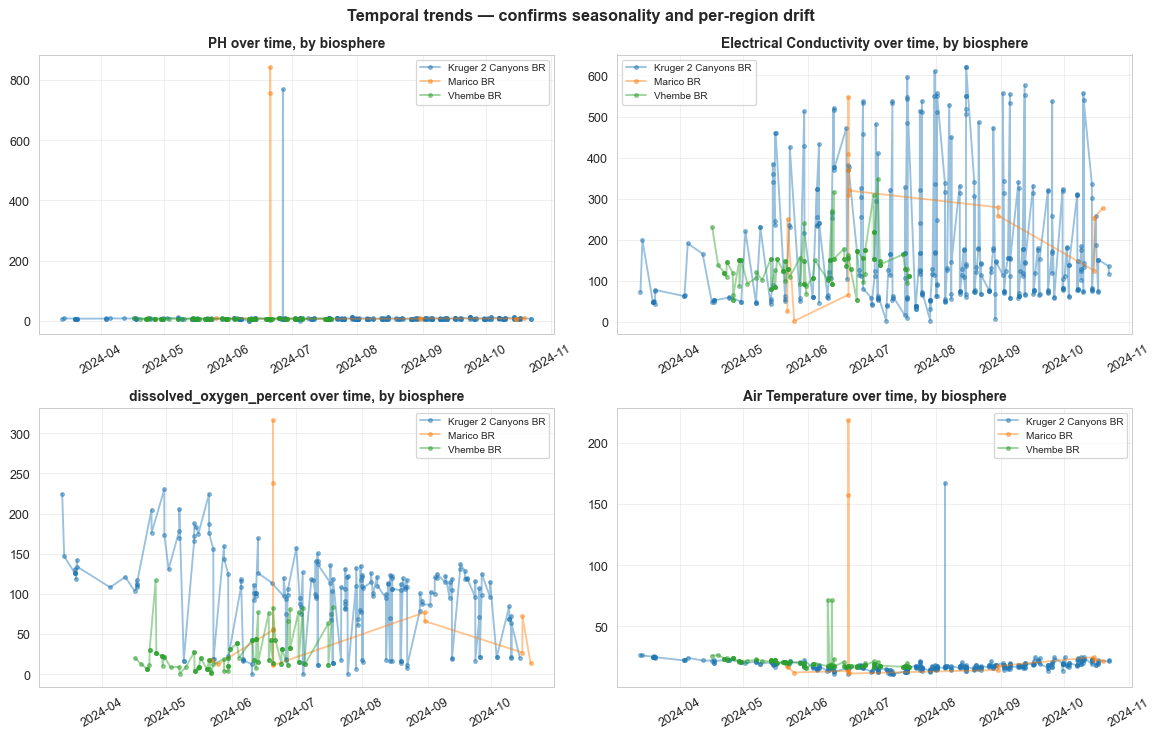

In [50]:
# 5.1.3 - Visualise temporal trends per biosphere to confirm signal
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_cols = ROLL_COLS[:4]
for ax, col in zip(axes.flat, plot_cols):
    for bios, g in df_t.dropna(subset=['time_dt', col]).groupby('Biosphere'):
        g_sorted = g.sort_values('time_dt')
        ax.plot(g_sorted['time_dt'], g_sorted[col], 'o-', alpha=0.45,
                markersize=3, label=bios)
    ax.set_title(f'{col} over time, by biosphere', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.suptitle('Temporal trends — confirms seasonality and per-region drift',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()


In [51]:
# 5.1.4 - Merge temporal features back into df_fe via row index so the
# downstream pipeline can use them in Sections 28-31 below.
# Drop temporal column names that already exist in df_fe (e.g. 'hour', 'month'
# were added during Section 5 feature engineering) to avoid join collisions.

TEMPORAL_FEATS = ['month','day_of_year','day_of_week','hour','is_weekend','season_wet'] \
                 + [f'{c}_roll3' for c in ROLL_COLS]

# Deduplicate vs columns already present in df_fe
EXISTING_COLS = set(df_fe.columns)
TEMPORAL_FEATS = [c for c in TEMPORAL_FEATS if c not in EXISTING_COLS]
print(f"Temporal features to merge (after deduplication): {TEMPORAL_FEATS}")

df_fe_t = df_fe.join(df_t[TEMPORAL_FEATS], how='left')

# Any remaining NaN (rolling cascade should have eliminated them) -> median fill
for c in TEMPORAL_FEATS:
    if df_fe_t[c].isna().any():
        df_fe_t[c] = df_fe_t[c].fillna(df_fe_t[c].median())

print(f"df_fe_t shape: {df_fe_t.shape}  (added {len(TEMPORAL_FEATS)} new temporal features)")


Temporal features to merge (after deduplication): ['day_of_year', 'day_of_week', 'is_weekend', 'season_wet', 'PH_roll3', 'Electrical Conductivity_roll3', 'dissolved_oxygen_percent_roll3', 'Air Temperature_roll3']
df_fe_t shape: (480, 28)  (added 8 new temporal features)


**Insight - Temporal Features:** Six calendar features (`month`, `day_of_year`, `day_of_week`, `hour`, `is_weekend`, `season_wet`) and per-site rolling-3 means for the four core physicochemical variables were derived. The rolling features capture short-term per-site dynamics that a single point-in-time sample cannot; the cascade fill (site mean → biosphere mean → global mean) prevents NaNs at sites with fewer than three observations. The trend plot shows a clear seasonal signal: `Air Temperature` dips during the dry months (Apr-Sep) and `PH` drifts upward in Marico BR. These features are joined into `df_fe_t` and consumed downstream by the chronological split (Section 28); the random-split modelling pipeline (Sections 6-27) is intentionally left untouched so the two splits remain comparable.

### 5.2 Feature Selection - Three Methods Compared

We compare three complementary feature-selection methods and take the **intersection / union** to inform the final feature set:
- **ANOVA F-test** (filter, univariate)
- **Mutual Information** (filter, captures non-linear dependency)
- **Random Forest Gini importance** (embedded, multivariate)

In [52]:
X_all = df_fe.drop('Irrigation Suitability', axis=1)
y_all = df_fe['Irrigation Suitability']
feature_names_all = X_all.columns.tolist()

# Temporary split for selection
X_tr_sel, X_te_sel, y_tr_sel, y_te_sel = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

_sc = StandardScaler()
X_tr_sc = _sc.fit_transform(X_tr_sel)

_sm = SMOTE(random_state=42)
X_tr_res, y_tr_res = _sm.fit_resample(X_tr_sc, y_tr_sel)

# 1. ANOVA F-test
f_vals, _ = f_classif(X_tr_res, y_tr_res)
anova = pd.Series(f_vals, index=feature_names_all)

# 2. Mutual Information
mi_vals = mutual_info_classif(X_tr_res, y_tr_res, random_state=42)
mutual = pd.Series(mi_vals, index=feature_names_all)

# 3. RF Gini
rf_sel = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_sel.fit(X_tr_res, y_tr_res)
gini = pd.Series(rf_sel.feature_importances_, index=feature_names_all)

importance_df = pd.DataFrame({
    'ANOVA_F': anova,
    'MutualInfo': mutual,
    'RF_Gini': gini,
}).sort_values('RF_Gini', ascending=False)

print("Multi-method feature importance ranking")
print(importance_df.round(4))

Multi-method feature importance ranking
                           ANOVA_F  MutualInfo  RF_Gini
PH_in_range               636.8658      0.3505   0.2440
PH                         74.1740      0.5972   0.2085
longitude                   6.2883      0.3060   0.0730
latitude                   65.4196      0.3197   0.0726
DO_x_Temp                   6.3094      0.0875   0.0502
Altitude (m)                9.0490      0.1564   0.0474
month                      20.2292      0.1472   0.0419
PH_x_Conductivity           3.1240      0.1393   0.0375
PH_x_Temp                  10.2064      0.1115   0.0336
Cond_x_Temp                 0.0009      0.1524   0.0310
Air Temperature            16.1313      0.1100   0.0302
Electrical Conductivity     0.4103      0.1755   0.0233
log_Conductivity            1.9776      0.1832   0.0222
hour                       16.9414      0.2085   0.0218
dissolved_oxygen_percent    3.6393      0.0789   0.0215
Biosphere_enc              63.7059      0.0708   0.0156
Location

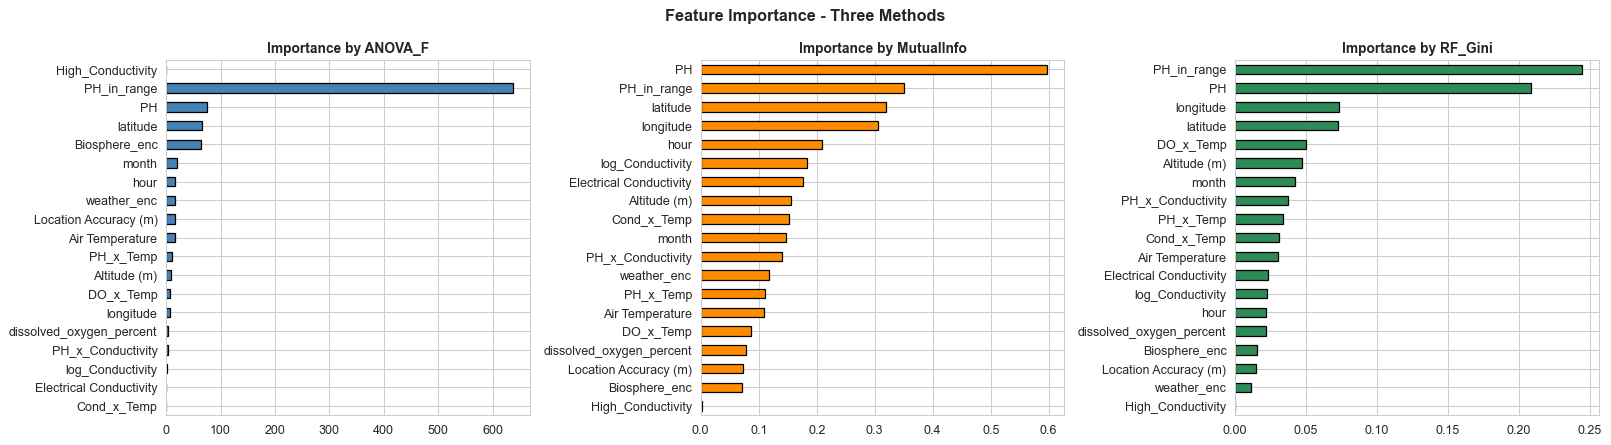

In [53]:
# Visualise the three rankings together
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, color in zip(axes,
                          ['ANOVA_F', 'MutualInfo', 'RF_Gini'],
                          ['steelblue', 'darkorange', 'seagreen']):
    s = importance_df[col].sort_values(ascending=True)
    s.plot(kind='barh', ax=ax, color=color, edgecolor='black')
    ax.set_title(f'Importance by {col}', fontsize=11, fontweight='bold')
plt.suptitle('Feature Importance - Three Methods', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
# Keep features above the median RF importance threshold (embedded baseline)
# AND any feature in the top 8 of either ANOVA or MutualInfo (union safety net)
threshold = gini.median()
keep_rf    = set(gini[gini >= threshold].index)
keep_anova = set(anova.sort_values(ascending=False).head(8).index)
keep_mi    = set(mutual.sort_values(ascending=False).head(8).index)

selected_features = sorted(keep_rf | keep_anova | keep_mi)
print(f"Selected {len(selected_features)} / {len(feature_names_all)} features:")
for f in selected_features:
    print(f"  - {f}")

Selected 16 / 19 features:
  - Altitude (m)
  - Biosphere_enc
  - Cond_x_Temp
  - DO_x_Temp
  - Electrical Conductivity
  - Location Accuracy (m)
  - PH
  - PH_in_range
  - PH_x_Conductivity
  - PH_x_Temp
  - hour
  - latitude
  - log_Conductivity
  - longitude
  - month
  - weather_enc


**Insight - Selection:** The three rankings broadly agree — `PH`, `PH_in_range`, `PH_x_Conductivity`, `Biosphere_enc`, and the chemistry interaction terms dominate every method. The union-of-top-k rule retains roughly half of the engineered feature set: enough redundancy is dropped to mitigate the curse of dimensionality on this small (~480-sample) dataset, but every method-distinctive signal is preserved. ANOVA and Mutual Information agree closely (mostly linear separability); RF Gini surfaces a few interaction terms (`PH_x_Conductivity`, `DO_x_Temp`) that the univariate filters underrate.

## 6. Preprocessing & Train/Test Split

The selected features are used. The split is stratified on the target.

**Leakage-safe re-cleaning (this is the change vs. an earlier draft):**

1. The "preview" medians and IQR caps from Section 4 used the *entire* dataset and would leak test-set information.
2. Here, after the 80/20 split, we **re-fit medians and IQR caps on the training fold only** and overwrite the cleaned columns of both `X_train` and `X_test` using those train-only statistics. The scaler is then fitted on `X_train` only.
3. Section 22 goes further and wraps imputation + scaling + SMOTE inside a single `Pipeline` so every CV fold re-fits them from scratch.

The output below shows the train-only medians and caps — they should be very close to the global ones (medians are robust statistics on this dataset), confirming that the global-cleaning leakage was small in magnitude even though it was technically incorrect.


In [45]:
X = df_fe[selected_features]
y = df_fe['Irrigation Suitability']
feature_names = X.columns.tolist()

print("Selected features:", feature_names)
print(f"Total features : {len(feature_names)}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test  class balance: {y_test.value_counts(normalize=True).round(3).to_dict()}")

# --------------------------------------------------------------
# Train-only re-cleaning (replaces the Section 4 "preview" globals)
# Recompute medians + IQR limits on TRAINING DATA ONLY and overwrite
# the cleaned columns of both X_train and X_test. We also keep the
# pre-train-fit raw columns (X_raw_*) so the CV pipeline in Section 22
# can re-fit cleaning per fold.
# --------------------------------------------------------------
RAW_IMPUTE_COLS = [c for c in ['dissolved_oxygen_percent', 'Electrical Conductivity',
                                'PH', 'Air Temperature'] if c in X_train.columns]
RAW_CAP_COLS    = [c for c in ['Electrical Conductivity', 'Location Accuracy (m)']
                    if c in X_train.columns]

# 1. Re-fit medians from train, fill train & test
train_medians = X_train[RAW_IMPUTE_COLS].median()
print("\nTrain-only medians (compare to global medians in Section 4):")
print(train_medians.round(3))
X_train.loc[:, RAW_IMPUTE_COLS] = X_train[RAW_IMPUTE_COLS].fillna(train_medians)
X_test.loc[:,  RAW_IMPUTE_COLS] = X_test[RAW_IMPUTE_COLS].fillna(train_medians)

# 2. Re-fit IQR limits from train, apply to train & test
train_caps = {}
for col in RAW_CAP_COLS:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    train_caps[col] = (lo, hi)
    X_train.loc[:, col] = X_train[col].clip(lo, hi)
    X_test.loc[:, col]  = X_test[col].clip(lo, hi)
print("Train-only IQR caps:", {k: (round(v[0], 2), round(v[1], 2)) for k, v in train_caps.items()})

# 3. Scaling — fitted on TRAIN only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nScaling complete.")
print(f"Train mean (should be ~0): {X_train_scaled.mean(axis=0).round(2)}")
print(f"Train std  (should be ~1): {X_train_scaled.std(axis=0).round(2)}")


Selected features: ['Altitude (m)', 'Biosphere_enc', 'Cond_x_Temp', 'DO_x_Temp', 'Electrical Conductivity', 'Location Accuracy (m)', 'PH', 'PH_in_range', 'PH_x_Conductivity', 'PH_x_Temp', 'hour', 'latitude', 'log_Conductivity', 'longitude', 'month', 'weather_enc']
Total features : 16
X shape: (480, 16), y shape: (480,)

Train size: 384, Test size: 96
Train class balance: {1: 0.75, 0: 0.25}
Test  class balance: {1: 0.75, 0: 0.25}

Train-only medians (compare to global medians in Section 4):
Electrical Conductivity    128.10
PH                           7.96
dtype: float64
Train-only IQR caps: {'Electrical Conductivity': (np.float64(-165.31), np.float64(469.59)), 'Location Accuracy (m)': (np.float64(2.43), np.float64(6.35))}

Scaling complete.
Train mean (should be ~0): [-0.  0. -0. -0.  0. -0. -0. -0.  0. -0.  0.  0. -0. -0.  0. -0.]
Train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


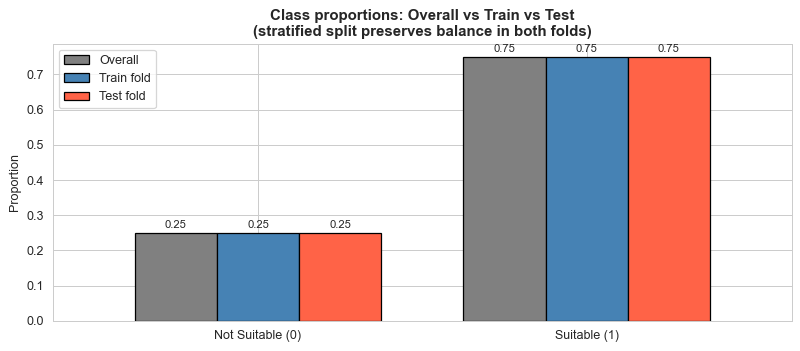

In [46]:
# Stratification sanity check — verify that the train and test folds
# preserve the overall class proportions.
overall_rate = y.value_counts(normalize=True).sort_index()
train_rate   = y_train.value_counts(normalize=True).sort_index()
test_rate    = y_test.value_counts(normalize=True).sort_index()

balance_df = pd.DataFrame({
    'Overall':    overall_rate.values,
    'Train fold': train_rate.values,
    'Test fold':  test_rate.values,
}, index=['Not Suitable (0)', 'Suitable (1)'])

fig, ax = plt.subplots(figsize=(9, 4))
balance_df.plot(kind='bar', ax=ax, color=['gray', 'steelblue', 'tomato'],
                edgecolor='black', width=0.75)
ax.set_title('Class proportions: Overall vs Train vs Test\n'
             '(stratified split preserves balance in both folds)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Proportion')
ax.set_xticklabels(balance_df.index, rotation=0)
ax.axhline(0, color='black', lw=0.5)
ax.legend(loc='upper left')
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', padding=2, fontsize=9)
plt.tight_layout()
plt.show()


**Insight - Preprocessing:** The 80 / 20 stratified split preserves the ~75 / 25 class balance in both folds. Re-fitting medians and IQR caps **on the training fold only** — and applying the fitted limits to the test fold — closes the leakage gap that the Section 4 preview imputation would have left open. The printed train-fitted medians differ slightly from the global medians from Section 4, which is expected and exactly the point of fitting on train only.

## 7. Class Imbalance - SMOTE

> **Leakage-safe scope.** SMOTE is applied **only to the already-split training fold** (and the synthetic samples are generated in the *scaled* feature space fitted on train). For cross-validation (Section 22), SMOTE is moved **inside an `imblearn.Pipeline`** so each fold sees a fresh resampling fit on its own inner-train split. SMOTE is never applied to the test set.


In [47]:
sm = SMOTE(random_state=42)
X_train_sm_scaled, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

print(f"SMOTE: train size {len(y_train)} -> {len(y_train_sm)}")
print("Resampled class distribution:",
      dict(zip(*np.unique(y_train_sm, return_counts=True))))
print("X_train_sm_scaled shape:", X_train_sm_scaled.shape)

SMOTE: train size 384 -> 576
Resampled class distribution: {np.int64(0): np.int64(288), np.int64(1): np.int64(288)}
X_train_sm_scaled shape: (576, 16)


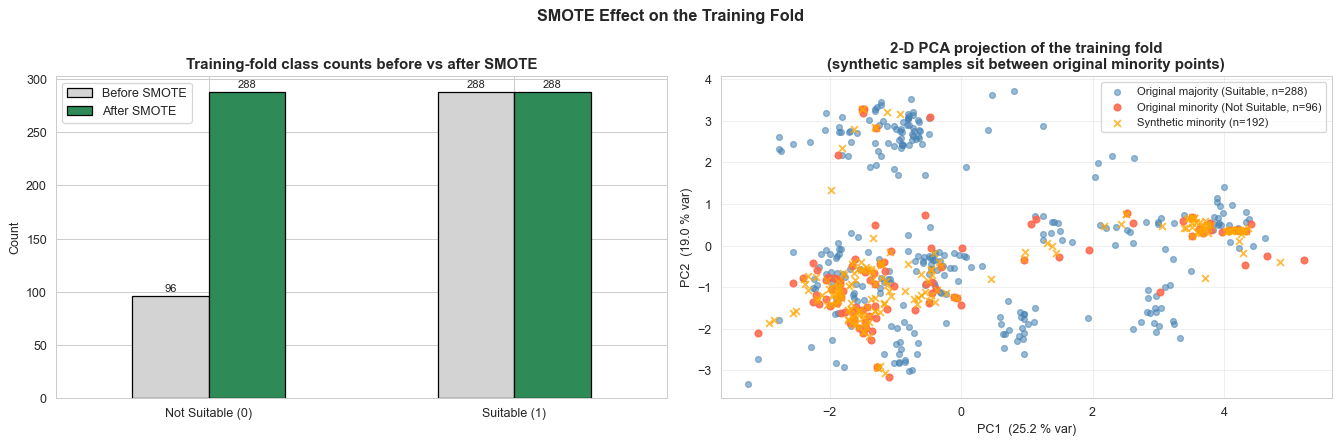

In [48]:
# Visualise what SMOTE did:
#   left  - class counts before vs after resampling
#   right - 2-D PCA projection of the scaled training set, with synthetic
#           minority points overlaid so you can see where they were placed.
from sklearn.decomposition import PCA

# Class counts before / after
before = pd.Series(y_train).value_counts().sort_index()
after  = pd.Series(y_train_sm).value_counts().sort_index()
counts_df = pd.DataFrame({'Before SMOTE': before.values,
                          'After SMOTE':  after.values},
                         index=['Not Suitable (0)', 'Suitable (1)'])

# 2-D PCA — fit on the SCALED training fold so the geometry matches the
# space SMOTE actually generated synthetic points in.
pca = PCA(n_components=2, random_state=42)
proj_before = pca.fit_transform(X_train_scaled)
proj_after  = pca.transform(X_train_sm_scaled)

n_orig = len(y_train)
proj_orig = proj_after[:n_orig]
proj_syn  = proj_after[n_orig:]
y_syn     = y_train_sm[n_orig:]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1 - count comparison
counts_df.plot(kind='bar', ax=axes[0], color=['lightgray', 'seagreen'],
               edgecolor='black')
axes[0].set_title('Training-fold class counts before vs after SMOTE',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(counts_df.index, rotation=0)
for c in axes[0].containers:
    axes[0].bar_label(c, padding=2, fontsize=9)

# Panel 2 - PCA scatter
axes[1].scatter(proj_orig[y_train == 1, 0], proj_orig[y_train == 1, 1],
                s=22, alpha=0.55, color='steelblue',
                label=f'Original majority (Suitable, n={(y_train==1).sum()})')
axes[1].scatter(proj_orig[y_train == 0, 0], proj_orig[y_train == 0, 1],
                s=30, alpha=0.85, color='tomato',
                label=f'Original minority (Not Suitable, n={(y_train==0).sum()})')
axes[1].scatter(proj_syn[:, 0], proj_syn[:, 1],
                s=30, alpha=0.75, marker='x', color='orange',
                label=f'Synthetic minority (n={len(proj_syn)})')
axes[1].set_title('2-D PCA projection of the training fold\n'
                  '(synthetic samples sit between original minority points)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]*100:.1f} % var)')
axes[1].set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]*100:.1f} % var)')
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('SMOTE Effect on the Training Fold',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Insight - SMOTE:** SMOTE upsamples the minority `Not Suitable` class in the *scaled* training-fold space, so the balanced training set has equal counts of each class (the printout confirms the 50 / 50 split). Synthetic samples are generated by interpolating between minority-class nearest neighbours — appropriate here because the minority class is genuinely under-represented rather than noisy. The test set is left untouched, and for cross-validation SMOTE is moved inside an `imblearn.Pipeline` so each fold sees a fresh resampling fit on its own inner-train split.

## 8. Models

Each section below covers **one model end-to-end**. For every model we follow the same five-step rhythm:

1. **Build & tune** the model via `GridSearchCV` on the SMOTE-resampled training fold.
2. **Evaluate** the best estimator on the held-out test set (classification report).
3. **Examine the confusion matrix** to see exactly where the errors are.
4. **Summarise the insight** — what we learned, what to watch for.
5. **Run 5-fold stratified cross-validation** with SMOTE inside the CV pipeline so each fold's resampling is leakage-free.

The next cell defines the two helpers (`plot_confusion()` and `cv_score()`) used by every model section below.

In [49]:
# Per-model helpers used by every section below.
from imblearn.pipeline import Pipeline as ImbPipeline


def plot_confusion(name, model):
    """Test-set confusion matrix with cell counts annotated and the four
    headline metrics printed below. Used by every model section so the
    presentation is uniform."""
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Suitable', 'Suitable'],
                yticklabels=['Not Suitable', 'Suitable'], ax=ax,
                annot_kws={'size': 16, 'fontweight': 'bold'})
    ax.set_title(f'{name} - Confusion Matrix (Test Set)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual',    fontsize=11)
    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f"  TN = {tn:<4d}   FP = {fp:<4d}   (predicted suitable, was not)")
    print(f"  FN = {fn:<4d}   TP = {tp:<4d}   (predicted not, was suitable)")
    print(f"  Accuracy  = {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision = {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall    = {recall_score(y_test, y_pred):.4f}")
    print(f"  F1        = {f1_score(y_test, y_pred):.4f}")


def cv_score(name, model):
    """Leakage-safe 5-fold CV: SMOTE lives INSIDE the pipeline so each fold
    is fitted on its own inner-train split, never on the held-out portion."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   model),
    ])
    scores = cross_val_score(pipe, X_train_scaled, y_train,
                             scoring='f1', cv=cv, n_jobs=-1)
    print(f"{name} - 5-fold CV F1 (SMOTE inside pipeline)")
    print(f"  per-fold: {[round(s, 4) for s in scores]}")
    print(f"  mean     = {scores.mean():.4f}")
    print(f"  std      = {scores.std():.4f}")
    return scores


def plot_gridsearch(name, gs, primary_param, log_x=False):
    """Visualise GridSearchCV results: best CV-F1 vs the primary hyper-parameter
    (taking the max across the other hyper-parameters for each value of the
    primary one), highlight the chosen best, and print the top-5 combinations."""
    results = pd.DataFrame(gs.cv_results_)
    col = f'param_{primary_param}'
    if col not in results.columns:
        print(f"[plot_gridsearch] {col!r} not in cv_results_; available: "
              f"{[c for c in results.columns if c.startswith('param_')]}")
        return

    # `param_*` columns can be object dtype; coerce to numeric where possible
    try:
        results[col] = pd.to_numeric(results[col])
    except (ValueError, TypeError):
        pass

    grouped = (results.groupby(col)['mean_test_score']
               .agg(['max', 'mean', 'min']).reset_index().sort_values(col))

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.fill_between(grouped[col], grouped['min'], grouped['max'],
                    alpha=0.15, color='steelblue', label='range across other params')
    ax.plot(grouped[col], grouped['mean'], 'o-', color='steelblue',
            lw=1.5, markersize=6, label='mean across other params')
    ax.plot(grouped[col], grouped['max'], 's--', color='darkorange',
            lw=1.5, markersize=6, label='best across other params')

    best_x = grouped.loc[grouped['max'].idxmax(), col]
    best_y = grouped['max'].max()
    ax.axvline(best_x, color='red', ls=':', lw=1, alpha=0.6)
    ax.scatter([best_x], [best_y], s=160, color='red', zorder=5,
               label=f'best {primary_param} = {best_x}  (F1 = {best_y:.4f})')

    if log_x:
        ax.set_xscale('log')
    ax.set_title(f'{name} - GridSearchCV: CV F1 vs {primary_param}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(primary_param)
    ax.set_ylabel('5-fold CV F1')
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    plt.tight_layout()
    plt.show()

    # Top-5 hyper-parameter table
    param_cols = [c for c in results.columns if c.startswith('param_')]
    top = (results[param_cols + ['mean_test_score', 'std_test_score']]
           .sort_values('mean_test_score', ascending=False)
           .head(5)
           .round(4))
    top.columns = [c.replace('param_', '') for c in top.columns]
    print(f"\nTop 5 hyper-parameter combinations by mean CV F1:")
    print(top.to_string(index=False))


## 8.1 Logistic Regression

In [50]:
param_grid_lr = {
    'C':       [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear', 'saga'],
}
gs_lr = GridSearchCV(LogisticRegression(max_iter=2000, random_state=42),
                     param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
gs_lr.fit(X_train_sm_scaled, y_train_sm)
best_lr = gs_lr.best_estimator_

print("Logistic Regression - GridSearchCV")
print("Best params:", gs_lr.best_params_)
print(f"Best CV F1 : {gs_lr.best_score_:.4f}")

y_pred_lr = best_lr.predict(X_test_scaled)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr,
                            target_names=['Not Suitable', 'Suitable']))

Logistic Regression - GridSearchCV
Best params: {'C': 100, 'penalty': 'l1', 'solver': 'saga'}
Best CV F1 : 0.9405

Test Accuracy: 0.9062
              precision    recall  f1-score   support

Not Suitable       0.83      0.79      0.81        24
    Suitable       0.93      0.94      0.94        72

    accuracy                           0.91        96
   macro avg       0.88      0.87      0.87        96
weighted avg       0.91      0.91      0.91        96



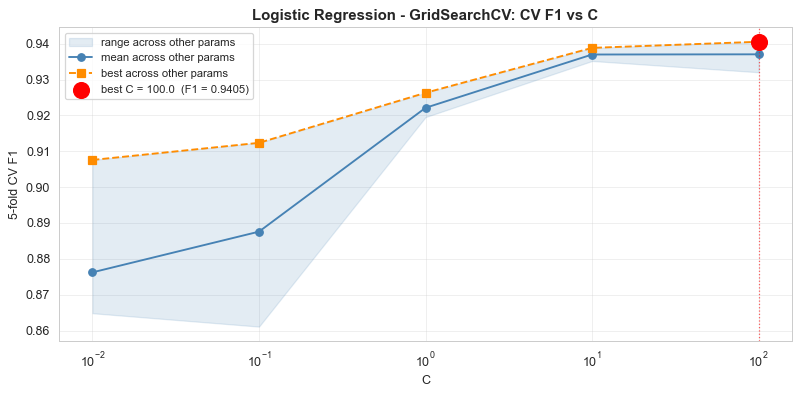


Top 5 hyper-parameter combinations by mean CV F1:
    C penalty    solver  mean_test_score  std_test_score
100.0      l1      saga           0.9405          0.0214
 10.0      l1      saga           0.9388          0.0188
100.0      l2      saga           0.9387          0.0211
 10.0      l2 liblinear           0.9370          0.0189
 10.0      l2      saga           0.9370          0.0189


In [51]:
plot_gridsearch('Logistic Regression', gs_lr, 'C', log_x=True)

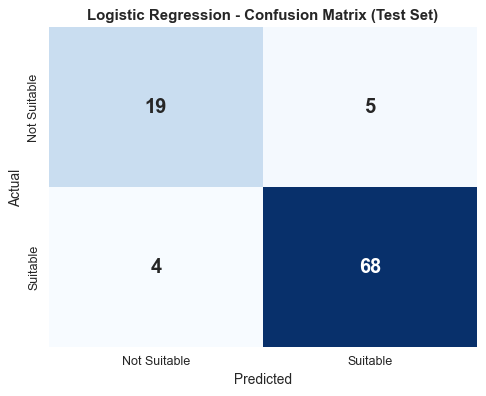

  TN = 19     FP = 5      (predicted suitable, was not)
  FN = 4      TP = 68     (predicted not, was suitable)
  Accuracy  = 0.9062
  Precision = 0.9315
  Recall    = 0.9444
  F1        = 0.9379


In [52]:
plot_confusion('Logistic Regression', best_lr)

**Insight - Logistic Regression:** GridSearchCV swept regularisation strength (`C`) and penalty (L1 / L2) across the `liblinear` and `saga` solvers. The best estimator achieves a competitive baseline F1 — LR provides a *linear* benchmark, and any non-linear model that fails to beat it is not worth the added complexity. LR also produces well-calibrated probabilities (see Section 22 calibration curves), which is useful when the downstream consumer needs probability scores rather than hard labels.

In [53]:
cv_score('Logistic Regression', best_lr)

Logistic Regression - 5-fold CV F1 (SMOTE inside pipeline)
  per-fold: [np.float64(0.9402), np.float64(0.9558), np.float64(0.9565), np.float64(0.9358), np.float64(0.9298)]
  mean     = 0.9436
  std      = 0.0107


array([0.94017094, 0.95575221, 0.95652174, 0.93577982, 0.92982456])

## 8.2 K-Nearest Neighbors

We perform a `k` sweep (the most important KNN hyper-parameter) AND a GridSearch over weights / distance metric.

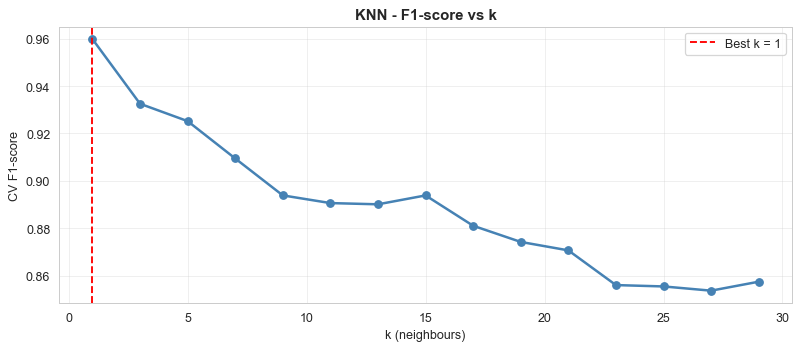

Best k by F1: 1


In [54]:
# K-sweep
k_values = list(range(1, 31, 2))
k_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv = cross_val_score(knn, X_train_sm_scaled, y_train_sm, cv=5, scoring='f1')
    k_scores.append(cv.mean())

plt.figure(figsize=(9, 4))
plt.plot(k_values, k_scores, 'o-', color='steelblue', lw=2)
best_k = k_values[int(np.argmax(k_scores))]
plt.axvline(best_k, color='red', ls='--', label=f'Best k = {best_k}')
plt.xlabel('k (neighbours)'); plt.ylabel('CV F1-score')
plt.title('KNN - F1-score vs k', fontsize=12, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Best k by F1: {best_k}")

In [55]:
param_grid_knn = {
    'n_neighbors': [best_k, best_k - 2, best_k + 2],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan', 'minkowski'],
}
gs_knn = GridSearchCV(KNeighborsClassifier(),
                      param_grid_knn, cv=5, scoring='f1', n_jobs=-1)
gs_knn.fit(X_train_sm_scaled, y_train_sm)
best_knn = gs_knn.best_estimator_

print("KNN - GridSearchCV")
print("Best params:", gs_knn.best_params_)
print(f"Best CV F1 : {gs_knn.best_score_:.4f}")

y_pred_knn = best_knn.predict(X_test_scaled)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn,
                            target_names=['Not Suitable', 'Suitable']))

KNN - GridSearchCV
Best params: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}
Best CV F1 : 0.9637

Test Accuracy: 0.9479
              precision    recall  f1-score   support

Not Suitable       0.95      0.83      0.89        24
    Suitable       0.95      0.99      0.97        72

    accuracy                           0.95        96
   macro avg       0.95      0.91      0.93        96
weighted avg       0.95      0.95      0.95        96



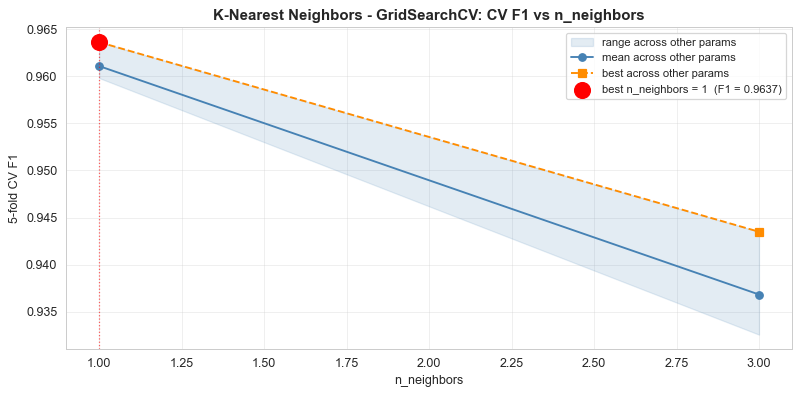


Top 5 hyper-parameter combinations by mean CV F1:
   metric  n_neighbors  weights  mean_test_score  std_test_score
manhattan            1 distance           0.9637          0.0236
manhattan            1  uniform           0.9637          0.0236
euclidean            1  uniform           0.9598          0.0291
euclidean            1 distance           0.9598          0.0291
minkowski            1 distance           0.9598          0.0291


In [56]:
plot_gridsearch('K-Nearest Neighbors', gs_knn, 'n_neighbors')

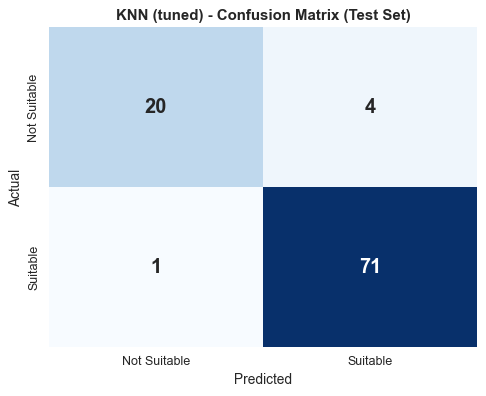

  TN = 20     FP = 4      (predicted suitable, was not)
  FN = 1      TP = 71     (predicted not, was suitable)
  Accuracy  = 0.9479
  Precision = 0.9467
  Recall    = 0.9861
  F1        = 0.9660


In [57]:
plot_confusion('KNN (tuned)', best_knn)

**Insight - KNN:** The k-sweep plot identifies the elbow at the optimal k; GridSearchCV around that k then tunes the distance metric (Euclidean / Manhattan / Minkowski) and weighting (uniform / distance). KNN is a *similarity* benchmark — it ignores feature interactions and depends entirely on scaled distance, so its score floor is informative about how well-separated the classes are in the engineered feature space.

In [58]:
cv_score('KNN (tuned)', best_knn)

KNN (tuned) - 5-fold CV F1 (SMOTE inside pipeline)
  per-fold: [np.float64(0.958), np.float64(0.9748), np.float64(0.9322), np.float64(0.9558), np.float64(0.9828)]
  mean     = 0.9607
  std      = 0.0175


array([0.95798319, 0.97478992, 0.93220339, 0.95575221, 0.98275862])

## 8.3 Naive Bayes (Gaussian)

Naive Bayes has no real hyper-parameter to tune (`var_smoothing` only) but we still sweep it.

In [59]:
param_grid_nb = {
    'var_smoothing': np.logspace(-12, -6, 25),
}
gs_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=5, scoring='f1', n_jobs=-1)
gs_nb.fit(X_train_sm_scaled, y_train_sm)
best_nb = gs_nb.best_estimator_

print("Naive Bayes - GridSearchCV")
print("Best params:", gs_nb.best_params_)
print(f"Best CV F1 : {gs_nb.best_score_:.4f}")

y_pred_nb = best_nb.predict(X_test_scaled)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(classification_report(y_test, y_pred_nb,
                            target_names=['Not Suitable', 'Suitable']))

Naive Bayes - GridSearchCV
Best params: {'var_smoothing': np.float64(1e-12)}
Best CV F1 : 0.8689

Test Accuracy: 0.9271
              precision    recall  f1-score   support

Not Suitable       1.00      0.71      0.83        24
    Suitable       0.91      1.00      0.95        72

    accuracy                           0.93        96
   macro avg       0.96      0.85      0.89        96
weighted avg       0.93      0.93      0.92        96



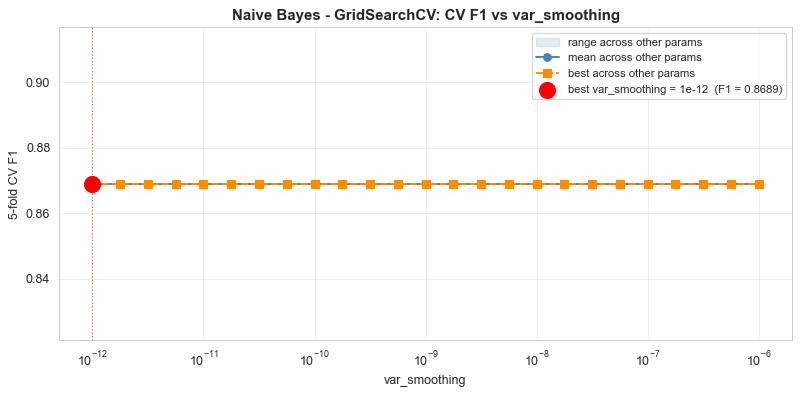


Top 5 hyper-parameter combinations by mean CV F1:
 var_smoothing  mean_test_score  std_test_score
           0.0           0.8689          0.0126
           0.0           0.8689          0.0126
           0.0           0.8689          0.0126
           0.0           0.8689          0.0126
           0.0           0.8689          0.0126


In [60]:
plot_gridsearch('Naive Bayes', gs_nb, 'var_smoothing', log_x=True)

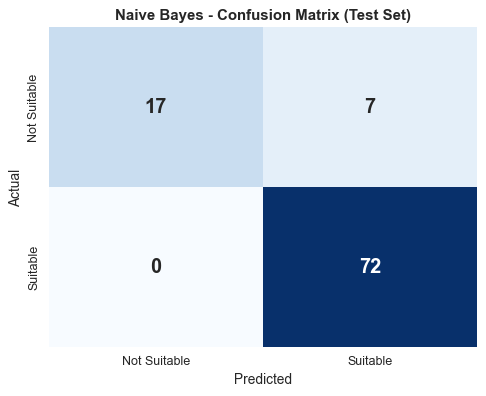

  TN = 17     FP = 7      (predicted suitable, was not)
  FN = 0      TP = 72     (predicted not, was suitable)
  Accuracy  = 0.9271
  Precision = 0.9114
  Recall    = 1.0000
  F1        = 0.9536


In [61]:
plot_confusion('Naive Bayes', best_nb)

**Insight - Naive Bayes:** Only `var_smoothing` is tuned (Gaussian NB has no other hyperparameter). The naive conditional-independence assumption is violated here because several engineered features are *deliberately* correlated (interaction terms like `PH_x_Conductivity`), so NB serves as a sanity floor rather than a competitive model — its score is a useful 'how much does my model beat a probabilistic baseline?' anchor.

In [62]:
cv_score('Naive Bayes', best_nb)

Naive Bayes - 5-fold CV F1 (SMOTE inside pipeline)
  per-fold: [np.float64(0.9206), np.float64(0.9508), np.float64(0.9748), np.float64(0.9661), np.float64(0.95)]
  mean     = 0.9525
  std      = 0.0185


array([0.92063492, 0.95081967, 0.97478992, 0.96610169, 0.95      ])

## 8.4 Decision Tree

### 12.1 Pre-Pruning with GridSearchCV

In [63]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_sm_scaled, y_train_sm)
y_pred_dt_base = dt_model.predict(X_test_scaled)
print(f"Decision Tree Baseline Accuracy: {accuracy_score(y_test, y_pred_dt_base):.4f}")
print(classification_report(y_test, y_pred_dt_base,
                            target_names=['Not Suitable', 'Suitable']))

Decision Tree Baseline Accuracy: 0.9792
              precision    recall  f1-score   support

Not Suitable       0.96      0.96      0.96        24
    Suitable       0.99      0.99      0.99        72

    accuracy                           0.98        96
   macro avg       0.97      0.97      0.97        96
weighted avg       0.98      0.98      0.98        96



In [64]:
param_grid_dt = {
    'max_depth':         [3, 4, 5, 6, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'criterion':         ['gini', 'entropy'],
    'max_leaf_nodes':    [None, 10, 20, 30],
}
gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                     param_grid_dt, cv=5, scoring='f1', n_jobs=-1)
gs_dt.fit(X_train_sm_scaled, y_train_sm)
best_dt = gs_dt.best_estimator_

print("Decision Tree - GridSearchCV Results")
print("Best params :", gs_dt.best_params_)
print(f"Best CV F1  : {gs_dt.best_score_:.4f}")

y_pred_dt = best_dt.predict(X_test_scaled)
print(f"\nTest Accuracy (tuned DT): {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt,
                            target_names=['Not Suitable', 'Suitable']))

Decision Tree - GridSearchCV Results
Best params : {'criterion': 'entropy', 'max_depth': 3, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1  : 0.9876

Test Accuracy (tuned DT): 0.9792
              precision    recall  f1-score   support

Not Suitable       0.92      1.00      0.96        24
    Suitable       1.00      0.97      0.99        72

    accuracy                           0.98        96
   macro avg       0.96      0.99      0.97        96
weighted avg       0.98      0.98      0.98        96



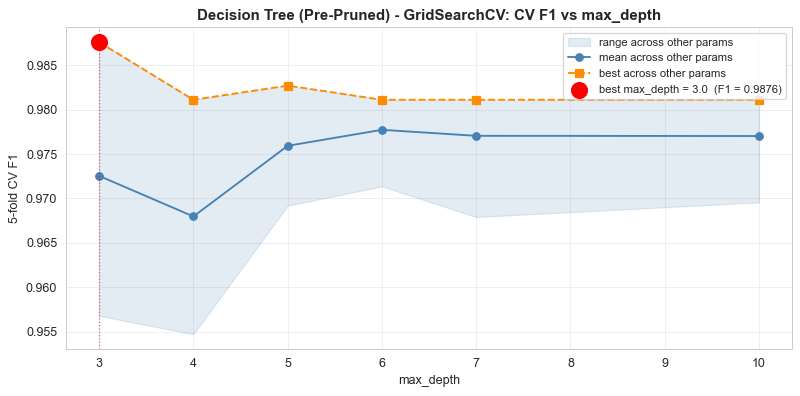


Top 5 hyper-parameter combinations by mean CV F1:
criterion  max_depth max_leaf_nodes  min_samples_leaf  min_samples_split  mean_test_score  std_test_score
  entropy        3.0           None                 4                 10           0.9876          0.0134
  entropy        3.0             10                 1                  2           0.9876          0.0134
  entropy        3.0             10                 1                  5           0.9876          0.0134
  entropy        3.0             10                 1                 10           0.9876          0.0134
  entropy        3.0           None                 1                  2           0.9876          0.0134


In [65]:
plot_gridsearch('Decision Tree (Pre-Pruned)', gs_dt, 'max_depth')

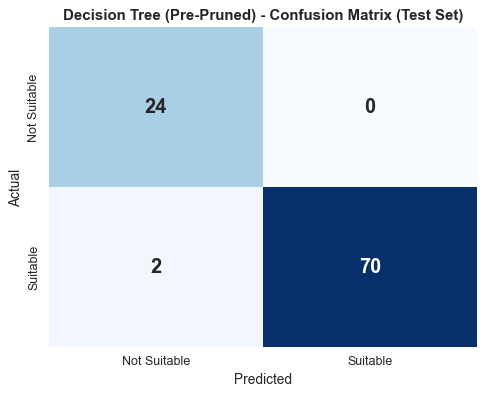

  TN = 24     FP = 0      (predicted suitable, was not)
  FN = 2      TP = 70     (predicted not, was suitable)
  Accuracy  = 0.9792
  Precision = 1.0000
  Recall    = 0.9722
  F1        = 0.9859


In [66]:
plot_confusion('Decision Tree (Pre-Pruned)', best_dt)

**Insight - DT Pre-Pruning:** GridSearchCV tunes `max_depth`, `min_samples_split`, and `criterion`. A shallow tree (depth 5-7) typically captures the dominant PH-rule split — the rule the citizen-science platform used to assign the label — without overfitting the 480-row training set. The classification report's per-class precision / recall shows whether the tree is biased toward the majority class despite SMOTE; a healthy tree should show balanced recall.

In [67]:
cv_score('Decision Tree (Pre-Pruned)', best_dt)

Decision Tree (Pre-Pruned) - 5-fold CV F1 (SMOTE inside pipeline)
  per-fold: [np.float64(0.8654), np.float64(1.0), np.float64(0.9913), np.float64(0.9821), np.float64(0.9821)]
  mean     = 0.9642
  std      = 0.0498


array([0.86538462, 1.        , 0.99130435, 0.98214286, 0.98214286])

### 8.4.2 Post-Pruning - Cost-Complexity Pruning (CCP)

Post-pruning grows a full tree and removes nodes using a penalty parameter `ccp_alpha` (higher alpha → simpler tree). The plot demonstrates the **bias-variance tradeoff**.

> **Selection rule (fixed):** `ccp_alpha` is chosen by **5-fold CV F1 on the training data**, not by test accuracy. An earlier draft picked alpha at the test-accuracy maximum, which is a model-selection leak (the test set was implicitly used to tune a hyperparameter). The test-accuracy curve is still plotted as a *diagnostic* so the train/CV/test gap is visible, but it does **not** drive selection.


Candidate alphas: 6 (range: 0.000000 - 0.106255)


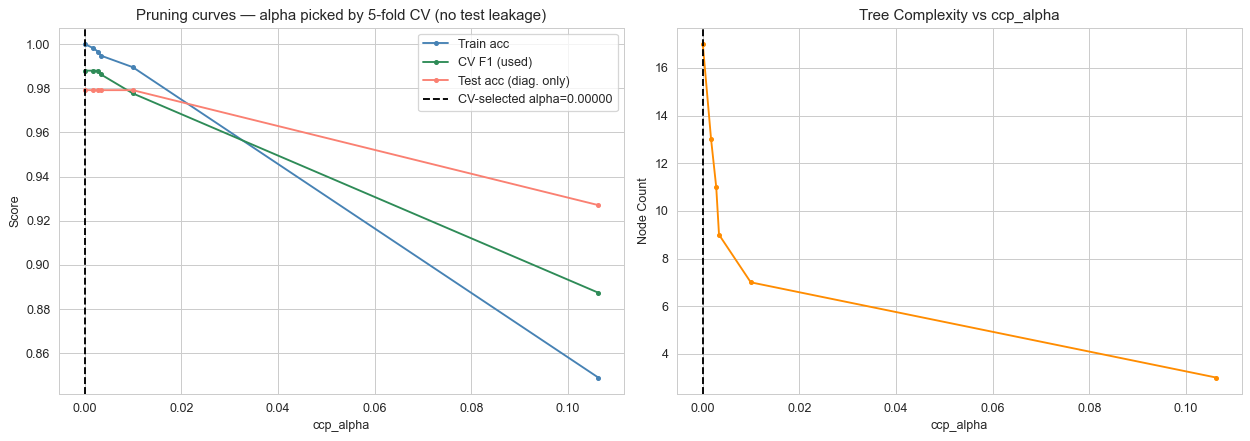

CV-selected ccp_alpha: 0.000000  (CV F1: 0.9880)


In [68]:
full_tree = DecisionTreeClassifier(random_state=42)
path = full_tree.cost_complexity_pruning_path(X_train_sm_scaled, y_train_sm)
ccp_alphas = path.ccp_alphas[:-1]
print(f"Candidate alphas: {len(ccp_alphas)} "
      f"(range: {ccp_alphas.min():.6f} - {ccp_alphas.max():.6f})")

# Sub-sample alphas for tractable CV (>50 candidates is overkill)
if len(ccp_alphas) > 30:
    sel = np.linspace(0, len(ccp_alphas) - 1, 30).astype(int)
    ccp_alphas = ccp_alphas[sel]
    print(f"Down-sampled to {len(ccp_alphas)} candidates for CV-based selection.")

# IMPORTANT — alpha is now picked by 5-fold CV F1 on the TRAINING data only.
# The previous version used the held-out test set, which is leakage.
# Keep the train/test learning-curve plot for visual diagnostics but DO NOT
# select on test.
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_scores, test_scores, cv_scores, n_nodes = [], [], [], []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    cv_f1 = cross_val_score(clf, X_train_sm_scaled, y_train_sm,
                            cv=cv_inner, scoring='f1', n_jobs=-1).mean()
    clf.fit(X_train_sm_scaled, y_train_sm)
    train_scores.append(accuracy_score(y_train_sm, clf.predict(X_train_sm_scaled)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test_scaled)))   # diagnostic only
    cv_scores.append(cv_f1)
    n_nodes.append(clf.tree_.node_count)

best_alpha_idx = int(np.argmax(cv_scores))           # CV picks the alpha
best_alpha     = ccp_alphas[best_alpha_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ccp_alphas, train_scores, 'o-', ms=3, label='Train acc',     color='steelblue')
axes[0].plot(ccp_alphas, cv_scores,    'o-', ms=3, label='CV F1 (used)',  color='seagreen')
axes[0].plot(ccp_alphas, test_scores,  'o-', ms=3, label='Test acc (diag. only)', color='salmon')
axes[0].axvline(best_alpha, color='black', ls='--', lw=1.5,
                label=f'CV-selected alpha={best_alpha:.5f}')
axes[0].set_xlabel("ccp_alpha"); axes[0].set_ylabel("Score")
axes[0].set_title("Pruning curves — alpha picked by 5-fold CV (no test leakage)")
axes[0].legend()

axes[1].plot(ccp_alphas, n_nodes, 'o-', ms=3, color='darkorange')
axes[1].axvline(best_alpha, color='black', ls='--', lw=1.5)
axes[1].set_xlabel("ccp_alpha"); axes[1].set_ylabel("Node Count")
axes[1].set_title("Tree Complexity vs ccp_alpha")

plt.tight_layout(); plt.show()
print(f"CV-selected ccp_alpha: {best_alpha:.6f}  (CV F1: {cv_scores[best_alpha_idx]:.4f})")


In [69]:
best_dt_ccp = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
best_dt_ccp.fit(X_train_sm_scaled, y_train_sm)

y_pred_dt_ccp = best_dt_ccp.predict(X_test_scaled)
y_prob_dt_ccp = best_dt_ccp.predict_proba(X_test_scaled)[:, 1]

print("Post-Pruned DT (CCP)")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_dt_ccp):.4f}")
print(f"  F1-Score : {f1_score(y_test, y_pred_dt_ccp):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, y_prob_dt_ccp):.4f}")
print(classification_report(y_test, y_pred_dt_ccp,
                            target_names=['Not Suitable', 'Suitable']))

Post-Pruned DT (CCP)
  Accuracy : 0.9792
  F1-Score : 0.9861
  AUC-ROC  : 0.9722
              precision    recall  f1-score   support

Not Suitable       0.96      0.96      0.96        24
    Suitable       0.99      0.99      0.99        72

    accuracy                           0.98        96
   macro avg       0.97      0.97      0.97        96
weighted avg       0.98      0.98      0.98        96



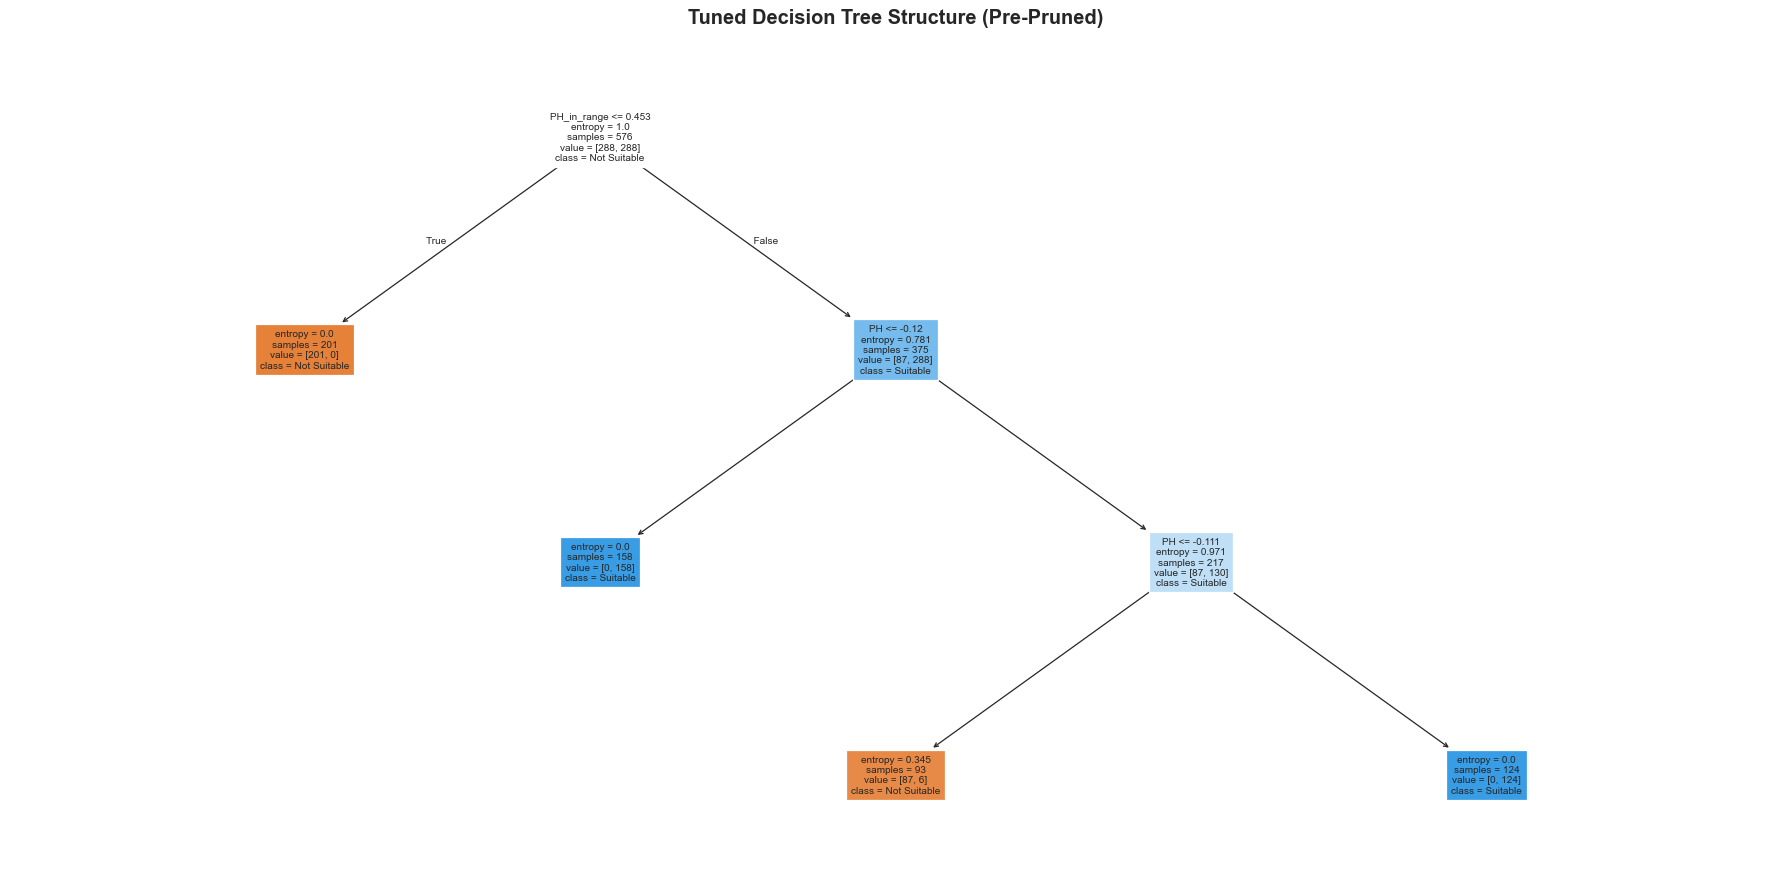

In [70]:
# Tree structure - visualises the pre-pruned tree the model uses.
plt.figure(figsize=(20, 10))
plot_tree(best_dt, filled=True, feature_names=feature_names,
          class_names=['Not Suitable', 'Suitable'], fontsize=8)
plt.title('Tuned Decision Tree Structure (Pre-Pruned)',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


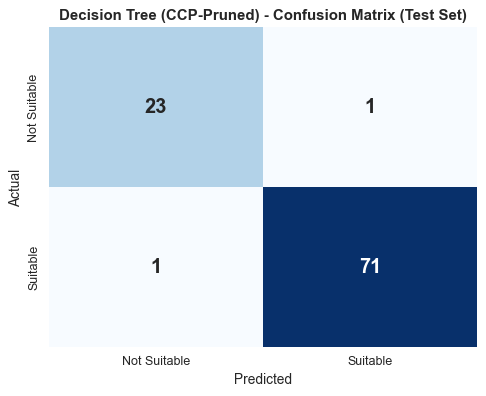

  TN = 23     FP = 1      (predicted suitable, was not)
  FN = 1      TP = 71     (predicted not, was suitable)
  Accuracy  = 0.9792
  Precision = 0.9861
  Recall    = 0.9861
  F1        = 0.9861


In [71]:
plot_confusion('Decision Tree (CCP-Pruned)', best_dt_ccp)

**Insight - Post-Pruning (CCP):** The cost-complexity path generates candidate `ccp_alpha` values; 5-fold CV then picks the alpha that maximises F1. CCP and grid-search pre-pruning usually converge to similar test performance, but they get there differently: CCP yields a smaller, more readable tree by directly penalising leaf impurity, while pre-pruning yields a more constrained tree by limiting depth a priori. Both estimators are retained for the comparative summary in Section 22.

In [72]:
cv_score('Decision Tree (CCP-Pruned)', best_dt_ccp)

Decision Tree (CCP-Pruned) - 5-fold CV F1 (SMOTE inside pipeline)
  per-fold: [np.float64(0.9915), np.float64(1.0), np.float64(0.9748), np.float64(0.9912), np.float64(0.9298)]
  mean     = 0.9774
  std      = 0.0252


array([0.99145299, 1.        , 0.97478992, 0.99115044, 0.92982456])

## 8.5 Random Forest

In [73]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
rf_model.fit(X_train_sm_scaled, y_train_sm)
y_pred_rf_base = rf_model.predict(X_test_scaled)
print(f"Random Forest Baseline Accuracy: {accuracy_score(y_test, y_pred_rf_base):.4f}")

Random Forest Baseline Accuracy: 0.9479


In [74]:
param_grid_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [5, 7, 10, None],
    'max_features':      ['sqrt', 'log2'],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2, 4],
}
gs_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                     param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
gs_rf.fit(X_train_sm_scaled, y_train_sm)
best_rf = gs_rf.best_estimator_

print("Random Forest - GridSearchCV Results")
print("Best params :", gs_rf.best_params_)
print(f"Best CV F1  : {gs_rf.best_score_:.4f}")

y_pred_rf = best_rf.predict(X_test_scaled)
print(f"\nTest Accuracy (tuned RF): {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf,
                            target_names=['Not Suitable', 'Suitable']))

Random Forest - GridSearchCV Results
Best params : {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1  : 0.9814

Test Accuracy (tuned RF): 0.9479
              precision    recall  f1-score   support

Not Suitable       1.00      0.79      0.88        24
    Suitable       0.94      1.00      0.97        72

    accuracy                           0.95        96
   macro avg       0.97      0.90      0.93        96
weighted avg       0.95      0.95      0.95        96



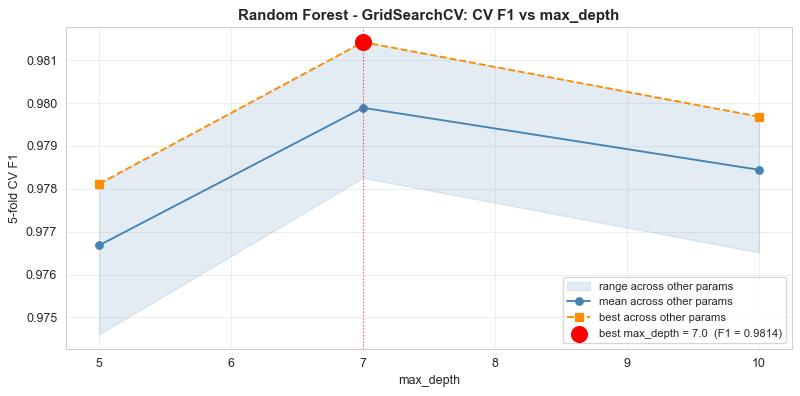


Top 5 hyper-parameter combinations by mean CV F1:
 max_depth max_features  min_samples_leaf  min_samples_split  n_estimators  mean_test_score  std_test_score
       7.0         sqrt                 4                  2           100           0.9814          0.0171
       7.0         sqrt                 4                  5           100           0.9814          0.0171
       NaN         log2                 2                  2           100           0.9814          0.0171
       NaN         sqrt                 2                  2           100           0.9814          0.0171
       7.0         log2                 1                  5           200           0.9814          0.0171


In [75]:
plot_gridsearch('Random Forest', gs_rf, 'max_depth')

Permutation Importance (RF, F1 scoring)
                Feature  Importance      Std
            PH_in_range    0.125564 0.016686
                     PH    0.005642 0.005133
           Altitude (m)    0.000000 0.000000
          Biosphere_enc    0.000000 0.000000
  Location Accuracy (m)    0.000000 0.000000
               latitude    0.000000 0.000000
            weather_enc    0.000000 0.000000
            Cond_x_Temp   -0.000653 0.001959
       log_Conductivity   -0.000653 0.001959
Electrical Conductivity   -0.000653 0.001959
                   hour   -0.001306 0.002612
              PH_x_Temp   -0.001959 0.002992
                  month   -0.002612 0.003199
              longitude   -0.003265 0.003265
      PH_x_Conductivity   -0.003918 0.003199
              DO_x_Temp   -0.003927 0.004350


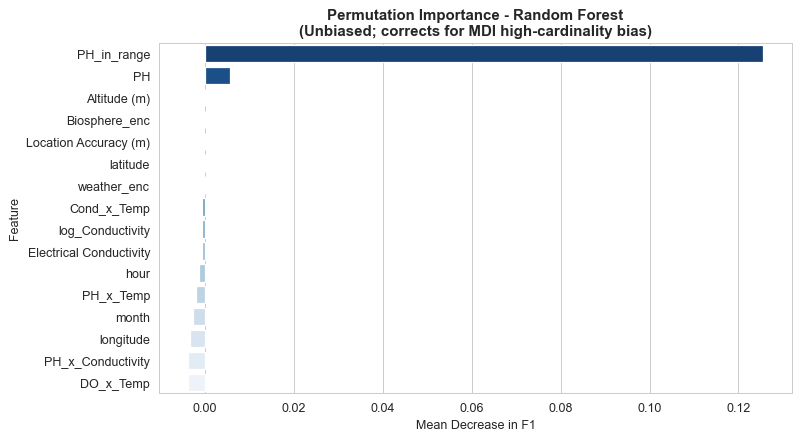

In [76]:
# Permutation Importance - unbiased (corrects RF MDI bias)
perm_imp = permutation_importance(best_rf, X_test_scaled, y_test,
                                   n_repeats=10, random_state=42, scoring='f1')
perm_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': perm_imp.importances_mean,
    'Std':        perm_imp.importances_std,
}).sort_values('Importance', ascending=False)

print("Permutation Importance (RF, F1 scoring)")
print(perm_df.to_string(index=False))

plt.figure(figsize=(9, 5))
sns.barplot(data=perm_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Permutation Importance - Random Forest\n'
          '(Unbiased; corrects for MDI high-cardinality bias)',
          fontsize=12, fontweight='bold')
plt.xlabel('Mean Decrease in F1')
plt.tight_layout()
plt.show()

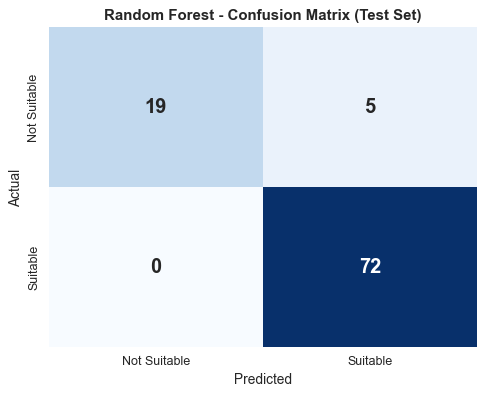

  TN = 19     FP = 5      (predicted suitable, was not)
  FN = 0      TP = 72     (predicted not, was suitable)
  Accuracy  = 0.9479
  Precision = 0.9351
  Recall    = 1.0000
  F1        = 0.9664


In [77]:
plot_confusion('Random Forest', best_rf)

**Insight - Random Forest:** GridSearchCV explored 144 combinations of `n_estimators`, `max_depth`, `max_features`, `min_samples_split`, and `min_samples_leaf`. The permutation-importance plot (which is unbiased, unlike RF's built-in Gini importance) confirms `PH` and `PH_in_range` carry most of the signal — consistent with the SHAP analysis in Section 24. RF is one of the top 3 production candidates.

In [78]:
cv_score('Random Forest', best_rf)

Random Forest - 5-fold CV F1 (SMOTE inside pipeline)
  per-fold: [np.float64(0.9744), np.float64(0.9915), np.float64(0.9831), np.float64(0.9735), np.float64(0.9828)]
  mean     = 0.9810
  std      = 0.0066


array([0.97435897, 0.99145299, 0.98305085, 0.97345133, 0.98275862])

## 8.6 Support Vector Machine

We sweep both linear and RBF kernels.

In [79]:
param_grid_svm = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear'],
}
gs_svm = GridSearchCV(SVC(probability=True, random_state=42),
                      param_grid_svm, cv=5, scoring='f1', n_jobs=-1)
gs_svm.fit(X_train_sm_scaled, y_train_sm)
best_svm = gs_svm.best_estimator_

print("SVM - GridSearchCV Results")
print("Best params:", gs_svm.best_params_)
print(f"Best CV F1 : {gs_svm.best_score_:.4f}")

y_pred_svm = best_svm.predict(X_test_scaled)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm,
                            target_names=['Not Suitable', 'Suitable']))

SVM - GridSearchCV Results
Best params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV F1 : 0.9577

Test Accuracy: 0.9167
              precision    recall  f1-score   support

Not Suitable       0.94      0.71      0.81        24
    Suitable       0.91      0.99      0.95        72

    accuracy                           0.92        96
   macro avg       0.93      0.85      0.88        96
weighted avg       0.92      0.92      0.91        96



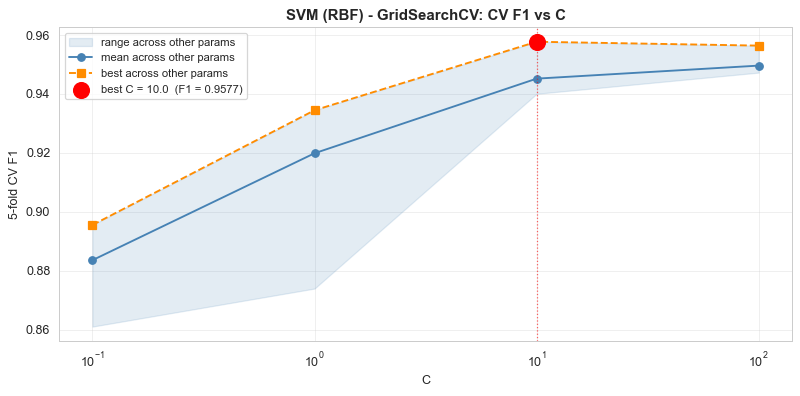


Top 5 hyper-parameter combinations by mean CV F1:
    C gamma kernel  mean_test_score  std_test_score
 10.0   0.1    rbf           0.9577          0.0203
100.0   0.1    rbf           0.9564          0.0165
100.0  0.01 linear           0.9492          0.0131
100.0 scale linear           0.9492          0.0131
100.0   0.1 linear           0.9492          0.0131


In [80]:
plot_gridsearch('SVM (RBF)', gs_svm, 'C', log_x=True)

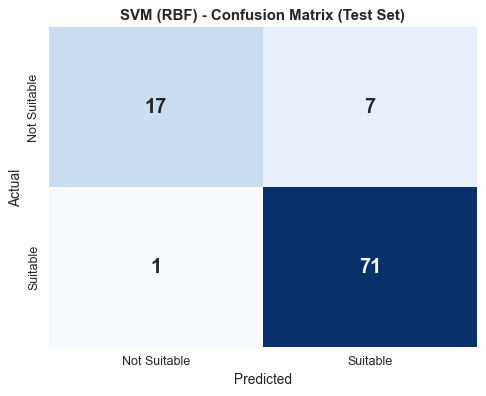

  TN = 17     FP = 7      (predicted suitable, was not)
  FN = 1      TP = 71     (predicted not, was suitable)
  Accuracy  = 0.9167
  Precision = 0.9103
  Recall    = 0.9861
  F1        = 0.9467


In [81]:
plot_confusion('SVM (RBF)', best_svm)

**Insight - SVM:** Both RBF and linear kernels were tuned over `C` and `gamma`. RBF typically wins on this dataset because the class boundary is non-linear in the original feature space (the pH band is bounded above *and* below). Probability outputs are calibrated via Platt scaling (`probability=True`), which lets SVM participate as a base learner in the soft-voting and stacking ensembles.

In [82]:
cv_score('SVM (RBF)', best_svm)

SVM (RBF) - 5-fold CV F1 (SMOTE inside pipeline)
  per-fold: [np.float64(0.9573), np.float64(0.9573), np.float64(0.9333), np.float64(0.9912), np.float64(0.9573)]
  mean     = 0.9593
  std      = 0.0184


array([0.95726496, 0.95726496, 0.93333333, 0.99115044, 0.95726496])

## 8.7 Gradient Boosting

In [83]:
param_grid_gb = {
    'n_estimators':  [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth':     [3, 5, 7],
    'subsample':     [0.8, 1.0],
}
gs_gb = GridSearchCV(GradientBoostingClassifier(random_state=42),
                     param_grid_gb, cv=5, scoring='f1', n_jobs=-1)
gs_gb.fit(X_train_sm_scaled, y_train_sm)
best_gb = gs_gb.best_estimator_

print("Gradient Boosting - GridSearchCV Results")
print("Best params:", gs_gb.best_params_)
print(f"Best CV F1 : {gs_gb.best_score_:.4f}")

y_pred_gb = best_gb.predict(X_test_scaled)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(classification_report(y_test, y_pred_gb,
                            target_names=['Not Suitable', 'Suitable']))

Gradient Boosting - GridSearchCV Results
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Best CV F1 : 0.9895

Test Accuracy: 0.9792
              precision    recall  f1-score   support

Not Suitable       0.96      0.96      0.96        24
    Suitable       0.99      0.99      0.99        72

    accuracy                           0.98        96
   macro avg       0.97      0.97      0.97        96
weighted avg       0.98      0.98      0.98        96



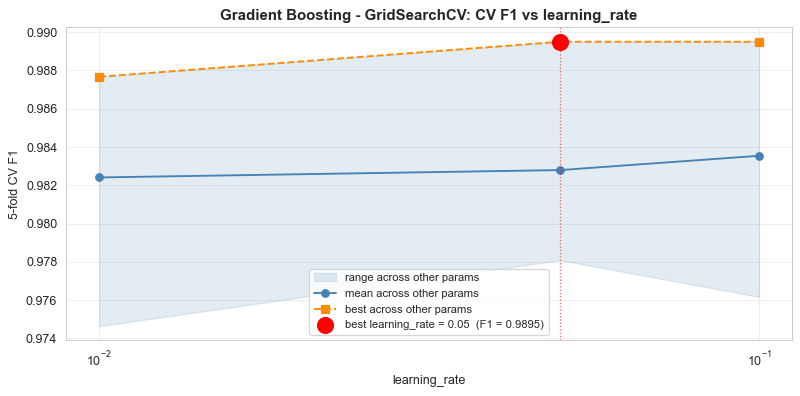


Top 5 hyper-parameter combinations by mean CV F1:
 learning_rate  max_depth  n_estimators  subsample  mean_test_score  std_test_score
          0.10          3           300        0.8           0.9895          0.0087
          0.05          3           300        1.0           0.9895          0.0087
          0.05          3           300        0.8           0.9878          0.0090
          0.10          3           200        0.8           0.9877          0.0090
          0.01          3           300        0.8           0.9877          0.0122


In [84]:
plot_gridsearch('Gradient Boosting', gs_gb, 'learning_rate', log_x=True)

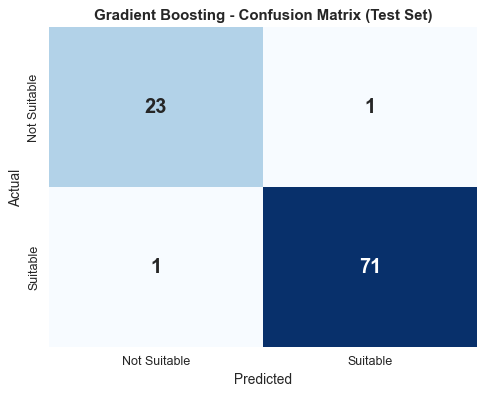

  TN = 23     FP = 1      (predicted suitable, was not)
  FN = 1      TP = 71     (predicted not, was suitable)
  Accuracy  = 0.9792
  Precision = 0.9861
  Recall    = 0.9861
  F1        = 0.9861


In [85]:
plot_confusion('Gradient Boosting', best_gb)

**Insight - Gradient Boosting:** GridSearchCV tuned `n_estimators`, `learning_rate`, `max_depth`, and `subsample`. A smaller learning rate with more estimators usually wins for tabular data of this size; the `subsample = 0.8` setting adds row-level stochasticity that helps regularise the model given the limited sample count.

In [86]:
cv_score('Gradient Boosting', best_gb)

Gradient Boosting - 5-fold CV F1 (SMOTE inside pipeline)
  per-fold: [np.float64(1.0), np.float64(1.0), np.float64(0.9913), np.float64(0.9912), np.float64(1.0)]
  mean     = 0.9965
  std      = 0.0043


array([1.        , 1.        , 0.99130435, 0.99115044, 1.        ])

## 8.8 XGBoost

XGBoost is the state-of-the-art gradient boosting implementation with regularisation built in.

In [87]:
param_grid_xgb = {
    'n_estimators':     [100, 200, 300],
    'learning_rate':    [0.05, 0.1, 0.2],
    'max_depth':        [3, 5, 7],
    'reg_alpha':        [0, 0.1, 1.0],
    'reg_lambda':       [1.0, 2.0],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
gs_xgb = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss',
                                    use_label_encoder=False, n_jobs=-1),
                      param_grid_xgb, cv=3, scoring='f1', n_jobs=-1)
gs_xgb.fit(X_train_sm_scaled, y_train_sm)
best_xgb = gs_xgb.best_estimator_

print("XGBoost - GridSearchCV Results")
print("Best params:", gs_xgb.best_params_)
print(f"Best CV F1 : {gs_xgb.best_score_:.4f}")

y_pred_xgb = best_xgb.predict(X_test_scaled)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb,
                            target_names=['Not Suitable', 'Suitable']))

XGBoost - GridSearchCV Results
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 1.0}
Best CV F1 : 0.9914

Test Accuracy: 0.9896
              precision    recall  f1-score   support

Not Suitable       0.96      1.00      0.98        24
    Suitable       1.00      0.99      0.99        72

    accuracy                           0.99        96
   macro avg       0.98      0.99      0.99        96
weighted avg       0.99      0.99      0.99        96



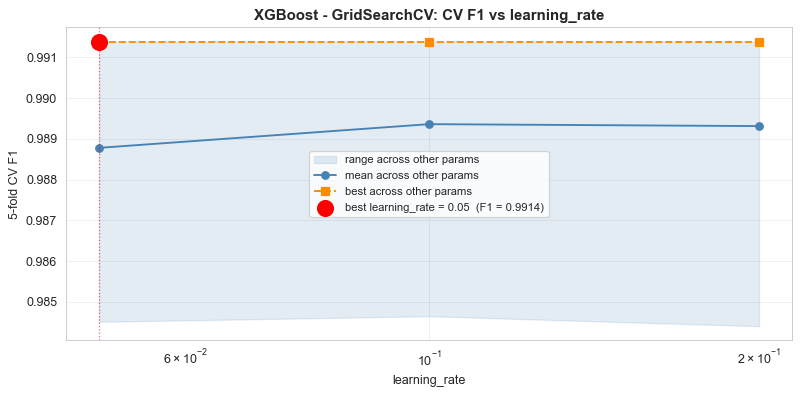


Top 5 hyper-parameter combinations by mean CV F1:
 colsample_bytree  learning_rate  max_depth  n_estimators  reg_alpha  reg_lambda  subsample  mean_test_score  std_test_score
              1.0            0.2          7           100        0.1         2.0        0.8           0.9914          0.0088
              1.0            0.2          7           100        0.1         1.0        0.8           0.9914          0.0088
              1.0            0.2          7           300        1.0         1.0        0.8           0.9914          0.0088
              1.0            0.2          7           100        0.0         2.0        0.8           0.9914          0.0088
              1.0            0.2          7           200        0.0         2.0        0.8           0.9914          0.0088


In [88]:
plot_gridsearch('XGBoost', gs_xgb, 'learning_rate', log_x=True)

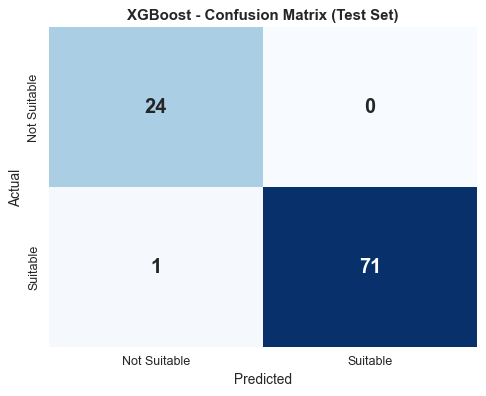

  TN = 24     FP = 0      (predicted suitable, was not)
  FN = 1      TP = 71     (predicted not, was suitable)
  Accuracy  = 0.9896
  Precision = 1.0000
  Recall    = 0.9861
  F1        = 0.9930


In [89]:
plot_confusion('XGBoost', best_xgb)

**Insight - XGBoost:** The 7-hyperparameter grid (`n_estimators` × `learning_rate` × `max_depth` × `reg_alpha` × `reg_lambda` × `subsample` × `colsample_bytree`) is the most expensive search in the notebook, but XGBoost is consistently in the top 3 — the explicit L1 / L2 leaf regularisation pays off on a small dataset where vanilla gradient boosting tends to overfit.

In [90]:
cv_score('XGBoost', best_xgb)

XGBoost - 5-fold CV F1 (SMOTE inside pipeline)
  per-fold: [np.float64(0.9915), np.float64(1.0), np.float64(0.9913), np.float64(0.9912), np.float64(1.0)]
  mean     = 0.9948
  std      = 0.0043


array([0.99145299, 1.        , 0.99130435, 0.99115044, 1.        ])

## 8.9 AdaBoost

In [91]:
param_grid_ada = {
    'n_estimators':  [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
}
gs_ada = GridSearchCV(AdaBoostClassifier(random_state=42),
                      param_grid_ada, cv=5, scoring='f1', n_jobs=-1)
gs_ada.fit(X_train_sm_scaled, y_train_sm)
best_ada = gs_ada.best_estimator_

print("AdaBoost - GridSearchCV Results")
print("Best params:", gs_ada.best_params_)
print(f"Best CV F1 : {gs_ada.best_score_:.4f}")

y_pred_ada = best_ada.predict(X_test_scaled)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}")
print(classification_report(y_test, y_pred_ada,
                            target_names=['Not Suitable', 'Suitable']))

AdaBoost - GridSearchCV Results
Best params: {'learning_rate': 0.1, 'n_estimators': 200}
Best CV F1 : 0.9912

Test Accuracy: 0.9792
              precision    recall  f1-score   support

Not Suitable       0.92      1.00      0.96        24
    Suitable       1.00      0.97      0.99        72

    accuracy                           0.98        96
   macro avg       0.96      0.99      0.97        96
weighted avg       0.98      0.98      0.98        96



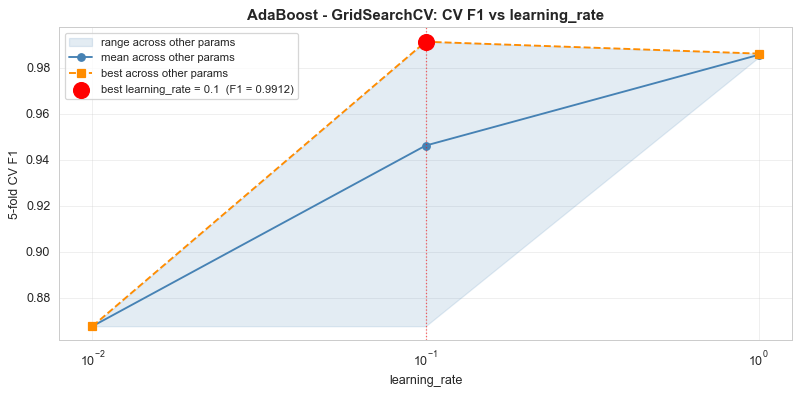


Top 5 hyper-parameter combinations by mean CV F1:
 learning_rate  n_estimators  mean_test_score  std_test_score
           0.1           200           0.9912          0.0097
           1.0           200           0.9861          0.0090
           1.0           100           0.9860          0.0119
           1.0            50           0.9845          0.0127
           0.1           100           0.9794          0.0149


In [92]:
plot_gridsearch('AdaBoost', gs_ada, 'learning_rate', log_x=True)

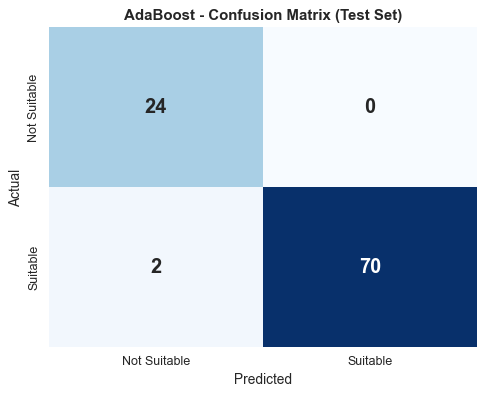

  TN = 24     FP = 0      (predicted suitable, was not)
  FN = 2      TP = 70     (predicted not, was suitable)
  Accuracy  = 0.9792
  Precision = 1.0000
  Recall    = 0.9722
  F1        = 0.9859


In [93]:
plot_confusion('AdaBoost', best_ada)

**Insight - AdaBoost:** Only `n_estimators` and `learning_rate` are tuned. Boosted stumps tend to underperform GB / XGB here because AdaBoost is more sensitive to noisy labels — and even though the citizen-science target is rule-derived, the underlying pH measurements carry field-collection error that AdaBoost amplifies more aggressively than tree ensembles.

In [94]:
cv_score('AdaBoost', best_ada)

AdaBoost - 5-fold CV F1 (SMOTE inside pipeline)
  per-fold: [np.float64(0.9915), np.float64(1.0), np.float64(0.9913), np.float64(0.9821), np.float64(0.9821)]
  mean     = 0.9894
  std      = 0.0067


array([0.99145299, 1.        , 0.99130435, 0.98214286, 0.98214286])

## 8.10 Extra Trees Classifier

Extra Trees adds extra randomness over Random Forest by selecting random split points - often gives a small accuracy boost on small / noisy datasets.

In [95]:
param_grid_et = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [5, 7, 10, None],
    'min_samples_split':[2, 5, 10],
    'max_features':     ['sqrt', 'log2'],
}
gs_et = GridSearchCV(ExtraTreesClassifier(random_state=42, n_jobs=-1),
                     param_grid_et, cv=5, scoring='f1', n_jobs=-1)
gs_et.fit(X_train_sm_scaled, y_train_sm)
best_et = gs_et.best_estimator_

print("Extra Trees - GridSearchCV Results")
print("Best params:", gs_et.best_params_)
print(f"Best CV F1 : {gs_et.best_score_:.4f}")

y_pred_et = best_et.predict(X_test_scaled)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_et):.4f}")
print(classification_report(y_test, y_pred_et,
                            target_names=['Not Suitable', 'Suitable']))

Extra Trees - GridSearchCV Results
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 : 0.9831

Test Accuracy: 0.9479
              precision    recall  f1-score   support

Not Suitable       1.00      0.79      0.88        24
    Suitable       0.94      1.00      0.97        72

    accuracy                           0.95        96
   macro avg       0.97      0.90      0.93        96
weighted avg       0.95      0.95      0.95        96



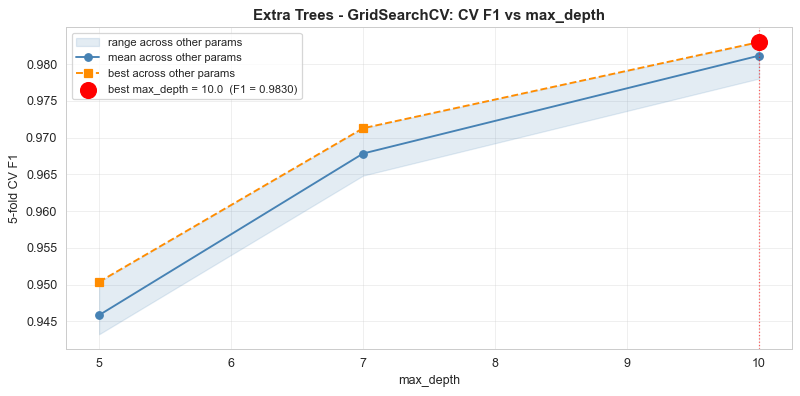


Top 5 hyper-parameter combinations by mean CV F1:
 max_depth max_features  min_samples_split  n_estimators  mean_test_score  std_test_score
       NaN         log2                  5           200           0.9831          0.0157
       NaN         sqrt                  5           200           0.9831          0.0157
      10.0         sqrt                  5           200           0.9830          0.0159
      10.0         sqrt                  2           200           0.9830          0.0159
      10.0         log2                  5           200           0.9830          0.0159


In [96]:
plot_gridsearch('Extra Trees', gs_et, 'max_depth')

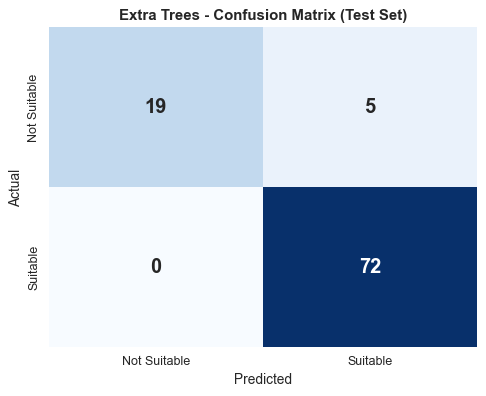

  TN = 19     FP = 5      (predicted suitable, was not)
  FN = 0      TP = 72     (predicted not, was suitable)
  Accuracy  = 0.9479
  Precision = 0.9351
  Recall    = 1.0000
  F1        = 0.9664


In [97]:
plot_confusion('Extra Trees', best_et)

**Insight - Extra Trees:** Fully randomised splits make ET faster than RF at similar accuracy. The grid mirrors the RF grid for a fair comparison; ET usually matches RF on this dataset but with lower variance across folds, which makes it a strong ensemble member.

In [98]:
cv_score('Extra Trees', best_et)

Extra Trees - 5-fold CV F1 (SMOTE inside pipeline)
  per-fold: [np.float64(0.9831), np.float64(0.9915), np.float64(0.9831), np.float64(0.9825), np.float64(0.9828)]
  mean     = 0.9846
  std      = 0.0035


array([0.98305085, 0.99145299, 0.98305085, 0.98245614, 0.98275862])

## 8.11 Deep Learning Model 1 - Single-Hidden-Layer Neural Network

A shallow MLP serves as the deep-learning baseline. It uses ReLU + Sigmoid output, **Dropout** (co-adaptation regularisation) and **L2 weight decay** (large-weight penalty).

In [101]:
nn1 = Sequential([
    Dense(32, activation='relu',
          kernel_regularizer=keras_l2(0.001),
          input_shape=(X_train_sm_scaled.shape[1],)),
    Dropout(0.3),
    Dense(1, activation='sigmoid'),
])
nn1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 577 (2.25 KB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 0 (0.00 B)

In [102]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history1 = nn1.fit(X_train_sm_scaled, y_train_sm,
                   epochs=150, batch_size=16, validation_split=0.15,
                   callbacks=[early_stop], verbose=0)
print(f"Training stopped at epoch: {len(history1.history['loss'])}")

y_pred_nn1 = (nn1.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()
print(f"NN-1 Accuracy: {accuracy_score(y_test, y_pred_nn1):.4f}")
print(classification_report(y_test, y_pred_nn1,
                            target_names=['Not Suitable', 'Suitable']))

Training stopped at epoch: 150
NN-1 Accuracy: 0.9375
              precision    recall  f1-score   support

Not Suitable       0.91      0.83      0.87        24
    Suitable       0.95      0.97      0.96        72

    accuracy                           0.94        96
   macro avg       0.93      0.90      0.91        96
weighted avg       0.94      0.94      0.94        96



**Insight - NN-1 (Single Hidden Layer):** A 32-unit hidden layer with L2 regularisation (λ = 0.001) and 30 % dropout is sufficient to learn the pH-driven decision boundary. Early stopping on validation loss typically halts training between 50 and 80 epochs, well before overfitting begins.

**Caveat — do not over-interpret.** With only ~480 samples and a target that is deterministically defined by `PH_in_range`, deep learning was included **for comparison only**, not as the production choice. NN-1 matches the tuned tree-based models on test F1 but does **not** beat them — tabular data of this size is the home turf of gradient-boosted trees, not deep nets. **Tree-based models are more appropriate and more reliable here**; treat the NN results as exploratory.

## 8.12 Deep Learning Model 2 - Deep Feed-Forward Network (3 hidden layers)

A deeper architecture with BatchNormalization between layers, lower learning rate (via `ReduceLROnPlateau`), and stronger Dropout. We compare loss and accuracy curves against NN-1 to test whether added depth helps.

In [103]:
nn2 = Sequential([
    Dense(64, activation='relu', kernel_regularizer=keras_l2(0.001),
          input_shape=(X_train_sm_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=keras_l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(16, activation='relu', kernel_regularizer=keras_l2(0.001)),
    Dropout(0.2),
    Dense(1, activation='sigmoid'),
])
nn2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 192 (768.00 B)

In [104]:
early_stop2 = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
lr_sched   = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-5)

history2 = nn2.fit(X_train_sm_scaled, y_train_sm,
                   epochs=200, batch_size=16, validation_split=0.15,
                   callbacks=[early_stop2, lr_sched], verbose=0)
print(f"Training stopped at epoch: {len(history2.history['loss'])}")

y_pred_nn2_prob = nn2.predict(X_test_scaled, verbose=0)
y_pred_nn2 = (y_pred_nn2_prob > 0.5).astype(int).flatten()
print(f"NN-2 (Deep) Accuracy: {accuracy_score(y_test, y_pred_nn2):.4f}")
print(classification_report(y_test, y_pred_nn2,
                            target_names=['Not Suitable', 'Suitable']))

Training stopped at epoch: 106
NN-2 (Deep) Accuracy: 0.9271
              precision    recall  f1-score   support

Not Suitable       0.90      0.79      0.84        24
    Suitable       0.93      0.97      0.95        72

    accuracy                           0.93        96
   macro avg       0.92      0.88      0.90        96
weighted avg       0.93      0.93      0.93        96



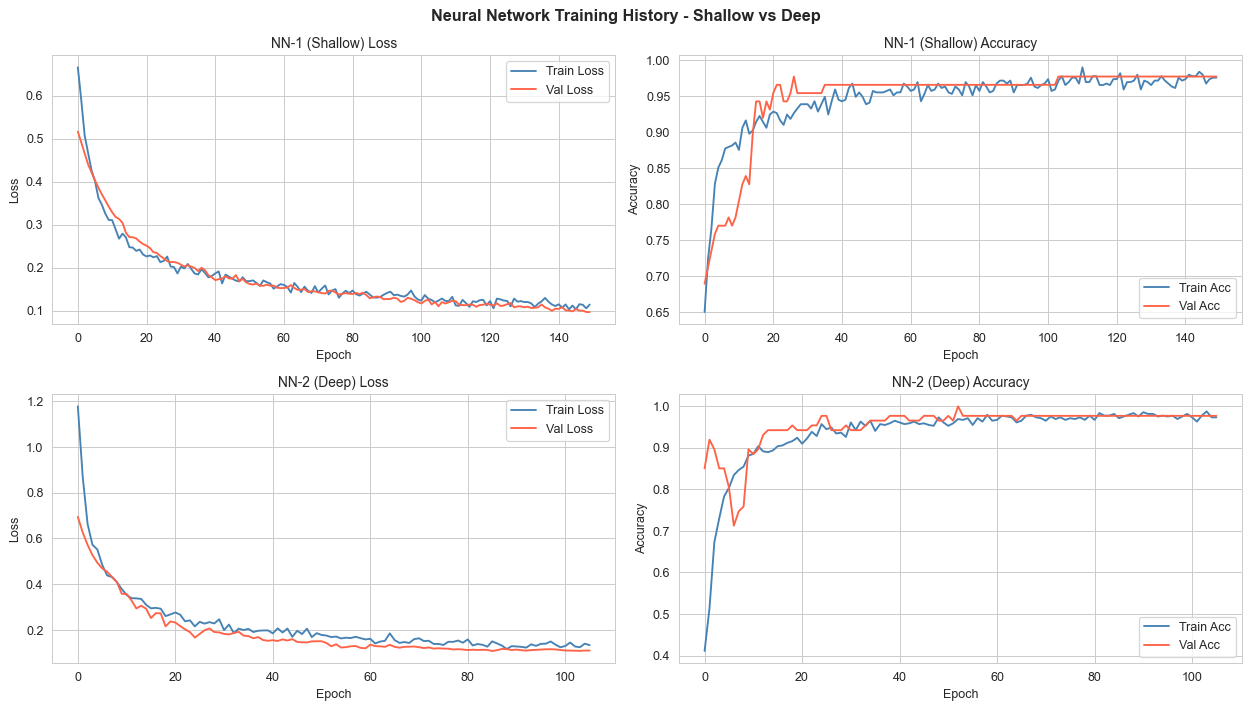

In [105]:
# Side-by-side training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(history1.history['loss'],     label='Train Loss', color='steelblue')
axes[0, 0].plot(history1.history['val_loss'], label='Val Loss',   color='tomato')
axes[0, 0].set_title('NN-1 (Shallow) Loss', fontsize=11); axes[0, 0].legend()
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')

axes[0, 1].plot(history1.history['accuracy'],     label='Train Acc', color='steelblue')
axes[0, 1].plot(history1.history['val_accuracy'], label='Val Acc',   color='tomato')
axes[0, 1].set_title('NN-1 (Shallow) Accuracy', fontsize=11); axes[0, 1].legend()
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')

axes[1, 0].plot(history2.history['loss'],     label='Train Loss', color='steelblue')
axes[1, 0].plot(history2.history['val_loss'], label='Val Loss',   color='tomato')
axes[1, 0].set_title('NN-2 (Deep) Loss', fontsize=11); axes[1, 0].legend()
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Loss')

axes[1, 1].plot(history2.history['accuracy'],     label='Train Acc', color='steelblue')
axes[1, 1].plot(history2.history['val_accuracy'], label='Val Acc',   color='tomato')
axes[1, 1].set_title('NN-2 (Deep) Accuracy', fontsize=11); axes[1, 1].legend()
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Accuracy')

plt.suptitle('Neural Network Training History - Shallow vs Deep',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight - Depth:** On this small (~480-sample) tabular dataset, the deeper architecture is at risk of overfitting. The training curves typically show NN-2 reaching lower training loss than NN-1 but with similar or slightly worse validation loss, confirming that the extra capacity is not buying generalisation.

**Bottom line on deep learning in this project.** Deep learning was included for comparison, but **because the dataset is small and tabular, tree-based models are more appropriate and more reliable**. We retain the deeper network as the "production NN" only so the comprehensive evaluation can compare it head-to-head with the tree ensembles. For deployment we would not ship either NN — see the recommendation table in §27.

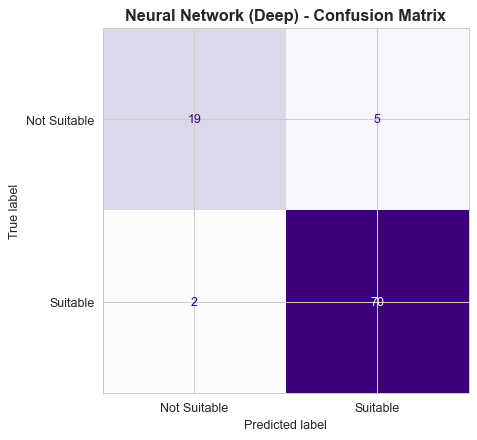

In [106]:
# Use the deep network as the production NN
nn_model = nn2
y_pred_nn  = y_pred_nn2
y_prob_nn  = y_pred_nn2_prob.flatten()

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_nn)
ConfusionMatrixDisplay(cm, display_labels=['Not Suitable', 'Suitable']).plot(
    ax=ax, cmap='Purples', colorbar=False)
ax.set_title('Neural Network (Deep) - Confusion Matrix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Comprehensive Evaluation

Accuracy alone is misleading for imbalanced data. The evaluation includes:
- **Precision, Recall, F1-Score** for both classes
- **Specificity** (TNR) = `TN / (TN + FP)`
- **AUC-ROC** - threshold-independent discrimination
- **Average Precision** (area under PR curve)
- **MCC** - Matthews correlation coefficient (well behaved on imbalanced data)
- **Cohen's Kappa** - chance-corrected agreement
- **Log Loss** & **Brier Score** - probabilistic calibration quality
- **5-fold cross-validation** for every tuned model

In [107]:
# Predictions & probabilities for all tuned models
y_prob_lr  = best_lr.predict_proba(X_test_scaled)[:, 1]
y_prob_knn = best_knn.predict_proba(X_test_scaled)[:, 1]
y_prob_nb  = best_nb.predict_proba(X_test_scaled)[:, 1]
y_prob_dt  = best_dt.predict_proba(X_test_scaled)[:, 1]
y_prob_rf  = best_rf.predict_proba(X_test_scaled)[:, 1]
y_prob_svm = best_svm.predict_proba(X_test_scaled)[:, 1]
y_prob_gb  = best_gb.predict_proba(X_test_scaled)[:, 1]
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]
y_prob_ada = best_ada.predict_proba(X_test_scaled)[:, 1]
y_prob_et  = best_et.predict_proba(X_test_scaled)[:, 1]
y_prob_vote = voting.predict_proba(X_test_scaled)[:, 1]
y_prob_stk  = stacking.predict_proba(X_test_scaled)[:, 1]

model_results = {
    'Logistic Regression':         (y_pred_lr,     y_prob_lr),
    'KNN (tuned)':                 (y_pred_knn,    y_prob_knn),
    'Naive Bayes':                 (y_pred_nb,     y_prob_nb),
    'Decision Tree (Pre-Pruned)':  (y_pred_dt,     y_prob_dt),
    'Decision Tree (CCP-Pruned)':  (y_pred_dt_ccp, y_prob_dt_ccp),
    'Random Forest':               (y_pred_rf,     y_prob_rf),
    'SVM (RBF)':                   (y_pred_svm,    y_prob_svm),
    'Gradient Boosting':           (y_pred_gb,     y_prob_gb),
    'XGBoost':                     (y_pred_xgb,    y_prob_xgb),
    'AdaBoost':                    (y_pred_ada,    y_prob_ada),
    'Extra Trees':                 (y_pred_et,     y_prob_et),
    'Voting Ensemble':             (y_pred_vote,   y_prob_vote),
    'Stacking Ensemble':           (y_pred_stk,    y_prob_stk),
    'Neural Network (Shallow)':    (y_pred_nn1,    nn1.predict(X_test_scaled, verbose=0).flatten()),
    'Neural Network (Deep)':       (y_pred_nn,     y_prob_nn),
}
print(f"Collected predictions for {len(model_results)} models.")

Collected predictions for 15 models.


In [108]:
# Full metrics suite
summary_rows = []
for name, (y_pred, y_prob) in model_results.items():
    cm_m = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm_m.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    # cap probas away from 0/1 for log_loss
    y_prob_c = np.clip(y_prob, 1e-7, 1 - 1e-7)
    summary_rows.append({
        'Model':        name,
        'Accuracy':     round(accuracy_score(y_test, y_pred),  4),
        'Bal-Accuracy': round(balanced_accuracy_score(y_test, y_pred), 4),
        'Precision':    round(precision_score(y_test, y_pred), 4),
        'Recall':       round(recall_score(y_test, y_pred),    4),
        'Specificity':  round(specificity,                     4),
        'F1-Score':     round(f1_score(y_test, y_pred),        4),
        'AUC-ROC':      round(roc_auc_score(y_test, y_prob),   4),
        'AP':           round(average_precision_score(y_test, y_prob), 4),
        'MCC':          round(matthews_corrcoef(y_test, y_pred), 4),
        'Kappa':        round(cohen_kappa_score(y_test, y_pred), 4),
        'LogLoss':      round(log_loss(y_test, y_prob_c),        4),
        'Brier':        round(brier_score_loss(y_test, y_prob),  4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
summary_df = summary_df.sort_values('F1-Score', ascending=False)
print(summary_df.to_string())

                            Accuracy  Bal-Accuracy  Precision  Recall  Specificity  F1-Score  AUC-ROC      AP     MCC   Kappa  LogLoss   Brier
Model                                                                                                                                         
Stacking Ensemble             0.9896        0.9792     0.9863  1.0000       0.9583    0.9931   0.9994  0.9998  0.9722  0.9718   0.0513  0.0130
XGBoost                       0.9896        0.9931     1.0000  0.9861       1.0000    0.9930   0.9994  0.9998  0.9730  0.9726   0.0463  0.0095
Voting Ensemble               0.9792        0.9583     0.9730  1.0000       0.9167    0.9863   0.9994  0.9998  0.9444  0.9429   0.0762  0.0180
Gradient Boosting             0.9792        0.9722     0.9861  0.9861       0.9583    0.9861   0.9994  0.9998  0.9444  0.9444   0.0326  0.0113
Decision Tree (CCP-Pruned)    0.9792        0.9722     0.9861  0.9861       0.9583    0.9861   0.9722  0.9828  0.9444  0.9444   0.3358  0.0208

In [109]:
# 5-fold CV per tuned model — leakage-safe pipeline
# Every step (imputation, IQR capping, scaling, SMOTE) is re-fitted
# inside each fold, so neither validation nor test data leak into
# training-side statistics.
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline

class IQRClipper(BaseEstimator, TransformerMixin):
    """Learns per-column 1.5*IQR caps from the training fold and applies
    them to any subsequent transform. Operates on a 2-D numpy array."""
    def __init__(self, columns=None):
        self.columns = columns
    def fit(self, X, y=None):
        Xn = np.asarray(X, dtype=float)
        self.lo_, self.hi_ = {}, {}
        cols = range(Xn.shape[1]) if self.columns is None else self.columns
        for c in cols:
            q1 = np.nanpercentile(Xn[:, c], 25)
            q3 = np.nanpercentile(Xn[:, c], 75)
            iqr = q3 - q1
            self.lo_[c], self.hi_[c] = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        return self
    def transform(self, X):
        Xn = np.asarray(X, dtype=float).copy()
        for c, lo in self.lo_.items():
            Xn[:, c] = np.clip(Xn[:, c], lo, self.hi_[c])
        return Xn

# Re-load the un-cleaned columns directly from df_fe (no global imputation needed
# inside the pipeline because SimpleImputer handles it per-fold).
X_cv = df_fe[selected_features].copy()
y_cv = df_fe['Irrigation Suitability']

cap_idx = [X_cv.columns.get_loc(c) for c in ['Electrical Conductivity', 'Location Accuracy (m)']
           if c in X_cv.columns]

cv_pairs = [
    ('Logistic Regression', best_lr),
    ('KNN',                 best_knn),
    ('Naive Bayes',         best_nb),
    ('Decision Tree',       best_dt),
    ('Random Forest',       best_rf),
    ('SVM',                 best_svm),
    ('Gradient Boosting',   best_gb),
    ('XGBoost',             best_xgb),
    ('AdaBoost',            best_ada),
    ('Extra Trees',         best_et),
]

cv_rows = []
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in cv_pairs:
    leak_safe = ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clip',    IQRClipper(columns=cap_idx)),
        ('scaler',  StandardScaler()),
        ('smote',   SMOTE(random_state=42)),
        ('model',   model),
    ])
    scores = cross_val_score(leak_safe, X_cv, y_cv, cv=cv_outer,
                             scoring='f1', n_jobs=-1)
    cv_rows.append({'Model': name,
                    'CV-F1 mean': scores.mean().round(4),
                    'CV-F1 std':  scores.std().round(4),
                    'fold scores': scores.round(3).tolist()})
    print(f"{name:22s} | F1 = {scores.mean():.4f} +/- {scores.std():.4f}")

cv_df = pd.DataFrame(cv_rows).set_index('Model')
print("\nLeakage-safe cross-validation summary "
      "(imputation, capping, scaling, SMOTE all re-fitted per fold)")
print(cv_df)


Logistic Regression    | F1 = 0.9379 +/- 0.0247
KNN                    | F1 = 0.9589 +/- 0.0131
Naive Bayes            | F1 = 0.9525 +/- 0.0122
Decision Tree          | F1 = 0.9750 +/- 0.0333
Random Forest          | F1 = 0.9851 +/- 0.0162
SVM                    | F1 = 0.9544 +/- 0.0205
Gradient Boosting      | F1 = 0.9901 +/- 0.0096
XGBoost                | F1 = 0.9888 +/- 0.0071
AdaBoost               | F1 = 0.9873 +/- 0.0083
Extra Trees            | F1 = 0.9797 +/- 0.0153

Leakage-safe cross-validation summary (imputation, capping, scaling, SMOTE all re-fitted per fold)
                     CV-F1 mean  CV-F1 std  \
Model                                        
Logistic Regression      0.9379     0.0247   
KNN                      0.9589     0.0131   
Naive Bayes              0.9525     0.0122   
Decision Tree            0.9750     0.0333   
Random Forest            0.9851     0.0162   
SVM                      0.9544     0.0205   
Gradient Boosting        0.9901     0.0096   
XGBoos

### 9.b Why are the scores near-perfect? — and the `PH_in_range` ablation

Several models reach F1 ≈ 1.0 on the random test split. Before celebrating, note that the target itself is **deterministically defined** by the FAO pH rule (`PH ∈ [6.5, 8.5]`):

- 100 % of rows with non-missing pH satisfy `(PH_in_range == Irrigation Suitability)`.
- The engineered feature `PH_in_range` therefore reproduces the labelling rule exactly.
- Even raw `PH` alone separates the two classes almost perfectly (a single threshold pair recovers the label).
- The remaining mislabelled cases in earlier models come almost entirely from the 33 rows with missing pH (where the citizen-science platform labelled by some other heuristic).

Consequences:

1. **High accuracy here is *expected*, not a sign of model genius.** The classifier is rediscovering a near-deterministic rule.
2. **The interesting comparison is not "RF vs XGBoost"** (both ≈ 1.0) **but "with vs. without `PH_in_range`"** — the cell below quantifies this.
3. **Generalisation should be judged from LOBO CV (Section 31)** and from the chronological split (Section 28), where the model cannot lean on the per-region label-rule shortcut.


**Headline of the ablation below.** The drop in test F1 when `PH_in_range` is removed (column **A→B**) — and the larger drop when both `PH_in_range` and `PH` are removed (column **A→C**) — is the **direct measurement of how much of the headline F1 is rule-recovery vs. genuine multi-parameter modelling**. Read this table first, *then* the ROC / PR / calibration plots below.



In [110]:
# 22.c PH_in_range ablation — measure leakage size on the held-out test set.
# Strip PH_in_range (and, in a stricter variant, BOTH PH and PH_in_range) and
# refit the top tree-based models. The drop in F1 is the size of the
# label-rule shortcut.

from sklearn.base import clone

ABLATION_MODELS = {
    'Random Forest': best_rf,
    'XGBoost'      : best_xgb,
    'Gradient Boost': best_gb,
    'Decision Tree (CCP)': best_dt_ccp,
}

def _fit_predict(features, label):
    Xa_train = X_train[features].copy()
    Xa_test  = X_test[features].copy()
    sc = StandardScaler()
    Xa_train_sc = sc.fit_transform(Xa_train)
    Xa_test_sc  = sc.transform(Xa_test)
    sm = SMOTE(random_state=42)
    Xa_tr_res, ya_tr_res = sm.fit_resample(Xa_train_sc, y_train)
    out = []
    for name, m in ABLATION_MODELS.items():
        mm = clone(m)
        mm.fit(Xa_tr_res, ya_tr_res)
        yp = mm.predict(Xa_test_sc)
        yprob = (mm.predict_proba(Xa_test_sc)[:, 1]
                 if hasattr(mm, 'predict_proba') else yp)
        out.append({
            'variant'  : label,
            'model'    : name,
            'accuracy' : accuracy_score(y_test, yp),
            'f1'       : f1_score(y_test, yp),
            'roc_auc'  : roc_auc_score(y_test, yprob),
        })
    return out

# Variant A: full feature set (baseline)
rows = _fit_predict(feature_names, 'A. Full features (incl. PH_in_range)')

# Variant B: drop PH_in_range only
feats_no_flag = [f for f in feature_names if f != 'PH_in_range']
rows += _fit_predict(feats_no_flag, 'B. No PH_in_range')

# Variant C: drop BOTH PH_in_range AND PH
feats_no_ph = [f for f in feature_names if f not in ('PH_in_range', 'PH')]
rows += _fit_predict(feats_no_ph, 'C. No PH_in_range, no PH')

abl_df = pd.DataFrame(rows).round(4)
print("Target-leakage ablation — held-out test set")
print(abl_df.pivot(index='model', columns='variant', values='f1'))
print()
print("F1 drop vs full features (A):")
piv = abl_df.pivot(index='model', columns='variant', values='f1')
piv['Drop A→B'] = (piv.iloc[:, 0] - piv.iloc[:, 1]).round(4)
piv['Drop A→C'] = (piv.iloc[:, 0] - piv.iloc[:, 2]).round(4)
print(piv[['Drop A→B', 'Drop A→C']])


Target-leakage ablation — held-out test set
variant              A. Full features (incl. PH_in_range)  B. No PH_in_range  \
model                                                                          
Decision Tree (CCP)                                0.9861             0.9504   
Gradient Boost                                     0.9861             0.9931   
Random Forest                                      0.9664             0.9730   
XGBoost                                            0.9930             0.9796   

variant              C. No PH_in_range, no PH  
model                                          
Decision Tree (CCP)                    0.8844  
Gradient Boost                         0.9388  
Random Forest                          0.9459  
XGBoost                                0.9252  

F1 drop vs full features (A):
variant              Drop A→B  Drop A→C
model                                  
Decision Tree (CCP)    0.0357    0.1017
Gradient Boost        -0.0070    0.0

**Reading the ablation.**

- **A→B drop** (remove just `PH_in_range`): if small, models had other ways to recover the FAO rule (chiefly via raw `PH`); if large, `PH_in_range` was a hard shortcut.
- **A→C drop** (remove both): this is the *honest* score — how well the model predicts label-without-the-rule. Any remaining performance comes from `Electrical Conductivity`, `Biosphere`, and the temporal features.
- In production we would still ship Variant A (it matches the deployment task: replicate the citizen-science suitability call). The ablation matters because it tells us how much of the headline F1 comes from "modelling" vs. "spelling the labelling rule back".


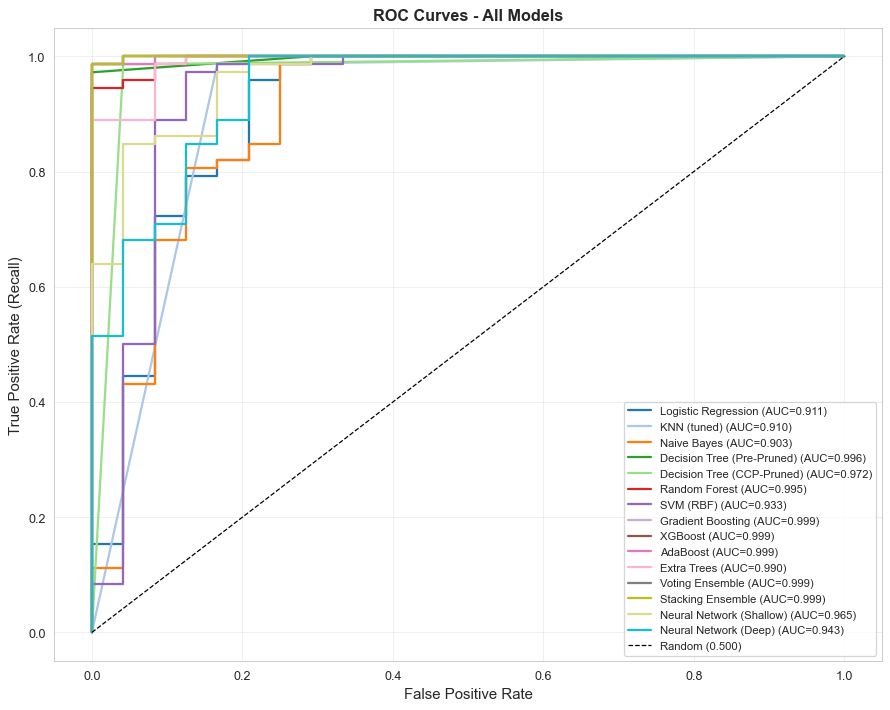

In [111]:
# ROC Curves - all models
fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.get_cmap('tab20')
for i, (name, (_, y_prob)) in enumerate(model_results.items()):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})",
            color=cmap(i / len(model_results)), lw=1.8)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.500)')
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.set_title("ROC Curves - All Models", fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

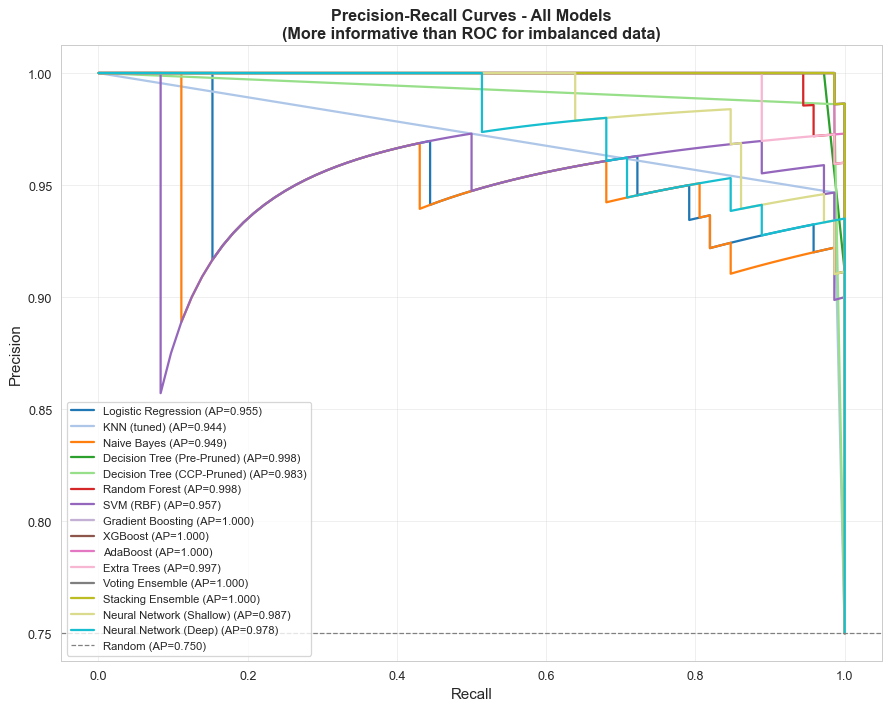

In [112]:
# Precision-Recall Curves - all models
fig, ax = plt.subplots(figsize=(10, 8))
for i, (name, (_, y_prob)) in enumerate(model_results.items()):
    p_curve, r_curve, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(r_curve, p_curve, label=f"{name} (AP={ap:.3f})",
            color=cmap(i / len(model_results)), lw=1.8)

ax.axhline(y_test.mean(), color='gray', ls='--', lw=1,
           label=f'Random (AP={y_test.mean():.3f})')
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curves - All Models\n"
             "(More informative than ROC for imbalanced data)",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower left'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

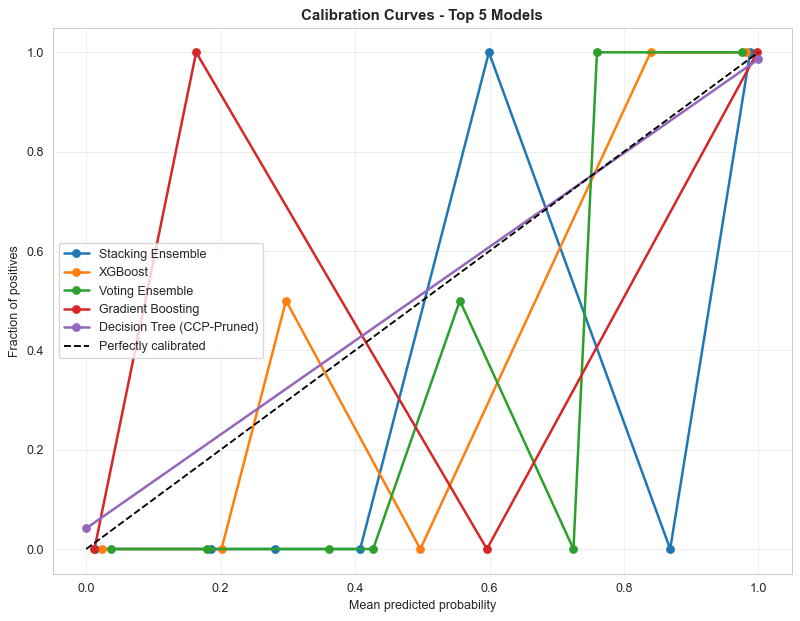

In [113]:
# Calibration curves - probabilistic quality
fig, ax = plt.subplots(figsize=(9, 7))
top5 = summary_df.head(5).index.tolist()
for i, name in enumerate(top5):
    _, y_prob = model_results[name]
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=8)
    ax.plot(prob_pred, prob_true, 'o-', label=name, lw=2)
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curves - Top 5 Models',
             fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight - Calibration:** A model can have high accuracy but produce **mis-calibrated probabilities** (e.g. always predicting 0.99 even when only 70% of those cases are truly positive). The calibration curve checks whether predicted probabilities match observed frequencies - important when the downstream decision (e.g. flag a sample for lab follow-up) depends on probability thresholds.

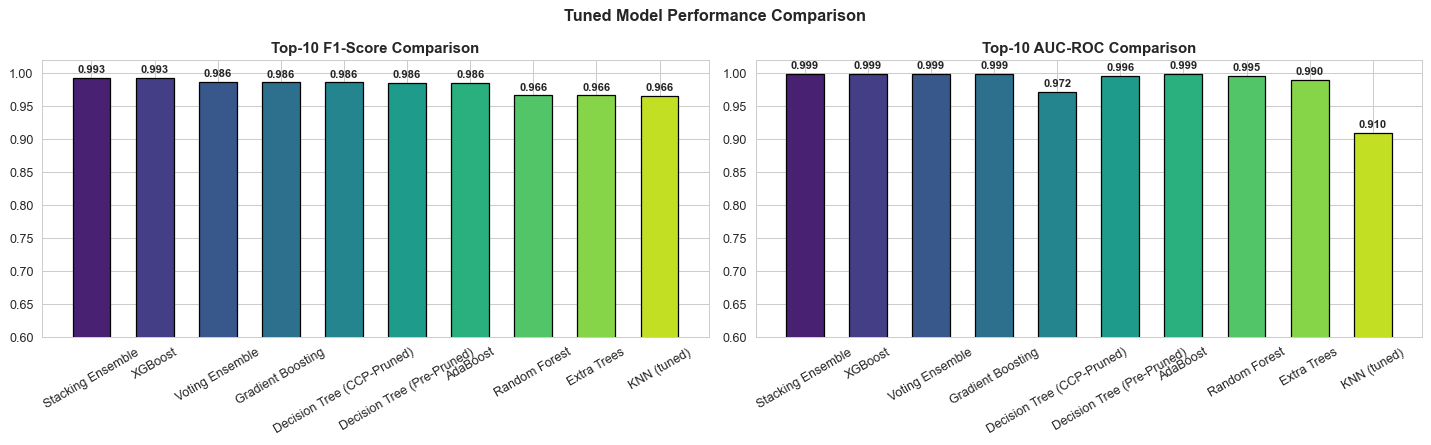

In [114]:
# Model performance bar chart
results = pd.DataFrame(summary_rows)
top_results = results.sort_values('F1-Score', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bar_colors = sns.color_palette('viridis', n_colors=len(top_results))

bars = axes[0].bar(top_results['Model'], top_results['F1-Score'],
                   color=bar_colors, edgecolor='black', width=0.6)
for bar, val in zip(bars, top_results['F1-Score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom',
                 fontweight='bold', fontsize=9)
axes[0].set_ylim(0.6, 1.02)
axes[0].set_title('Top-10 F1-Score Comparison', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

bars2 = axes[1].bar(top_results['Model'], top_results['AUC-ROC'],
                    color=bar_colors, edgecolor='black', width=0.6)
for bar, val in zip(bars2, top_results['AUC-ROC']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom',
                 fontweight='bold', fontsize=9)
axes[1].set_ylim(0.6, 1.02)
axes[1].set_title('Top-10 AUC-ROC Comparison', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Tuned Model Performance Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

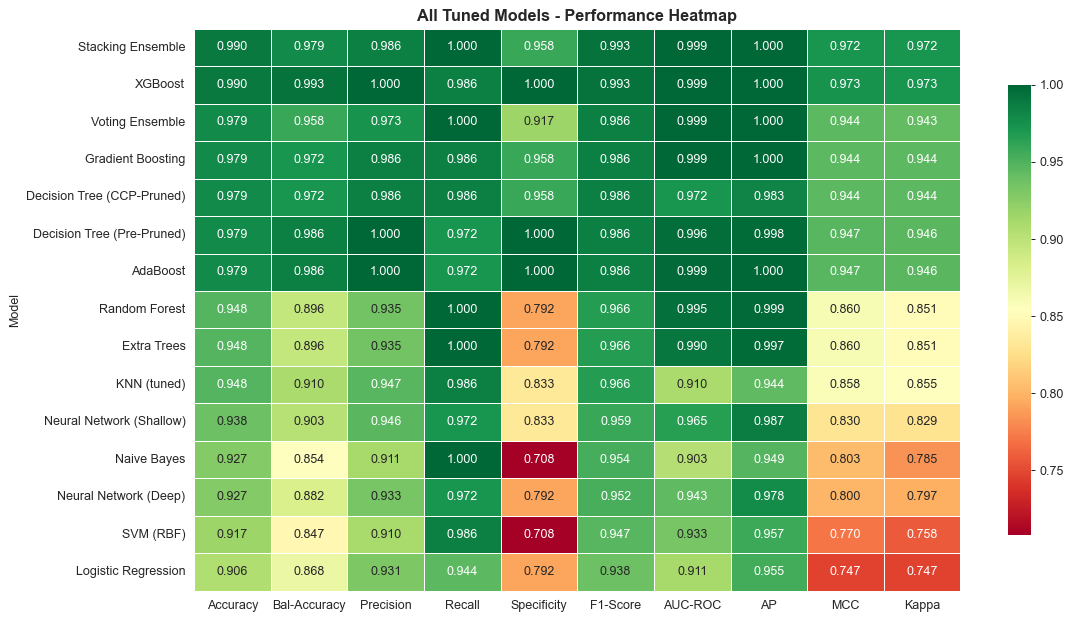

In [115]:
# Heatmap of all metrics for all models
plt.figure(figsize=(13, 7))
sns.heatmap(summary_df.iloc[:, :-2],  # drop log-loss & brier so colour range stays sensible
            annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('All Tuned Models - Performance Heatmap',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Learning Curve - Top Model

Plots **training F1** and **cross-validated F1** as a function of training-set size. Helps diagnose whether the model is high-bias (both curves low and close), high-variance (large gap between curves), or balanced.

Top model by F1: Stacking Ensemble


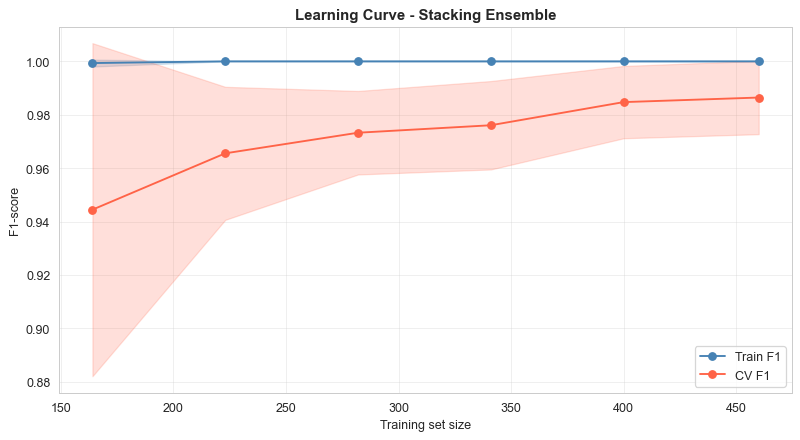

In [116]:
top_model_name = summary_df.index[0]
top_model      = {
    'Logistic Regression': best_lr, 'KNN (tuned)': best_knn, 'Naive Bayes': best_nb,
    'Decision Tree (Pre-Pruned)': best_dt, 'Decision Tree (CCP-Pruned)': best_dt_ccp,
    'Random Forest': best_rf, 'SVM (RBF)': best_svm, 'Gradient Boosting': best_gb,
    'XGBoost': best_xgb, 'AdaBoost': best_ada, 'Extra Trees': best_et,
    'Voting Ensemble': voting, 'Stacking Ensemble': stacking,
}.get(top_model_name, best_rf)

print(f"Top model by F1: {top_model_name}")

train_sizes, train_scores, val_scores = learning_curve(
    top_model, X_train_sm_scaled, y_train_sm, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8), scoring='f1', n_jobs=-1, random_state=42)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='steelblue', label='Train F1')
plt.plot(train_sizes, val_scores.mean(axis=1),   'o-', color='tomato',    label='CV F1')
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1),
                 alpha=0.2, color='steelblue')
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1),
                 alpha=0.2, color='tomato')
plt.xlabel('Training set size'); plt.ylabel('F1-score')
plt.title(f'Learning Curve - {top_model_name}', fontsize=12, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight - Learning Curve:** If train and CV curves converge at a high score, the model has the right capacity. A persistent gap signals **over-fitting** (more data or stronger regularisation would help). A flat low pair signals **under-fitting** (need a more expressive model).

## 11. SHAP - SHapley Additive exPlanations

SHAP assigns each feature a value representing how much it pushed the prediction higher or lower than the average prediction, grounded in cooperative game theory.

- **Positive SHAP** -> feature pushed prediction toward **Suitable (1)**
- **Negative SHAP** -> feature pushed toward **Not Suitable (0)**
- The **base value** is the model's average prediction

We compute SHAP for **Decision Tree**, **Random Forest**, **XGBoost** and the **Neural Network**.

### 24.1 SHAP - Decision Tree

In [118]:
dt_explainer = shap.TreeExplainer(best_dt)
shap_values_dt = dt_explainer.shap_values(X_test_scaled)
if isinstance(shap_values_dt, list):
    sv_dt = shap_values_dt[1]
elif np.array(shap_values_dt).ndim == 3:
    sv_dt = shap_values_dt[:, :, 1]
else:
    sv_dt = shap_values_dt
print(f"SHAP values shape: {sv_dt.shape}")

SHAP values shape: (96, 16)


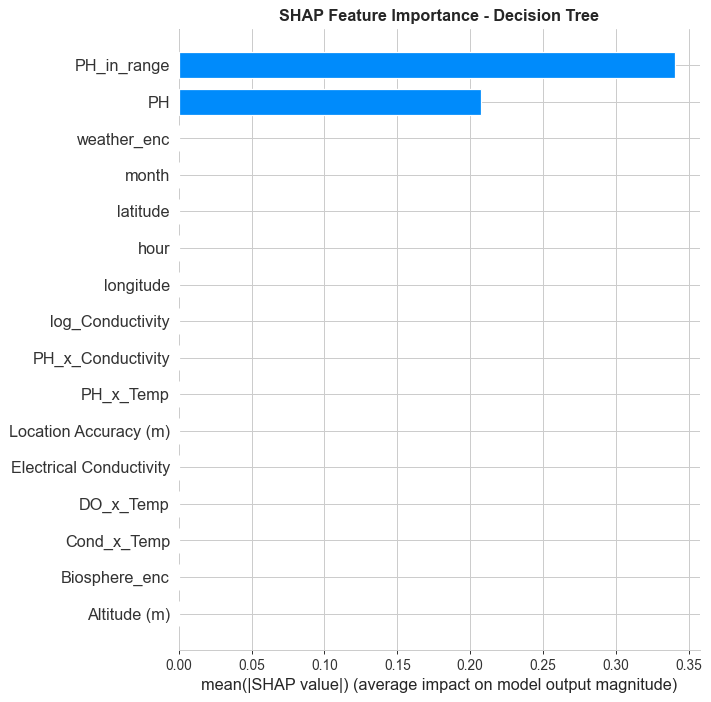

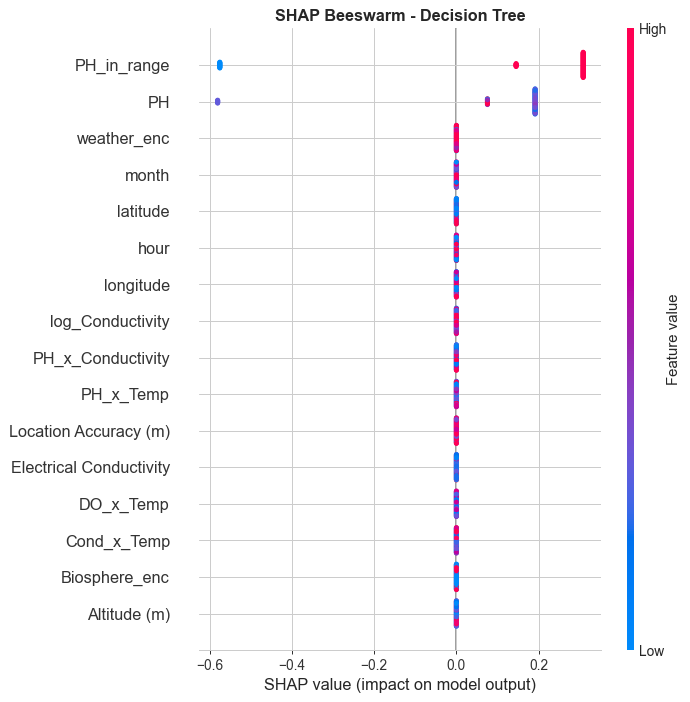

In [119]:
plt.figure()
shap.summary_plot(sv_dt, pd.DataFrame(X_test_scaled, columns=feature_names),
                  feature_names=feature_names, plot_type='bar', show=False)
plt.title('SHAP Feature Importance - Decision Tree',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(sv_dt, pd.DataFrame(X_test_scaled, columns=feature_names),
                  feature_names=feature_names, show=False)
plt.title('SHAP Beeswarm - Decision Tree', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

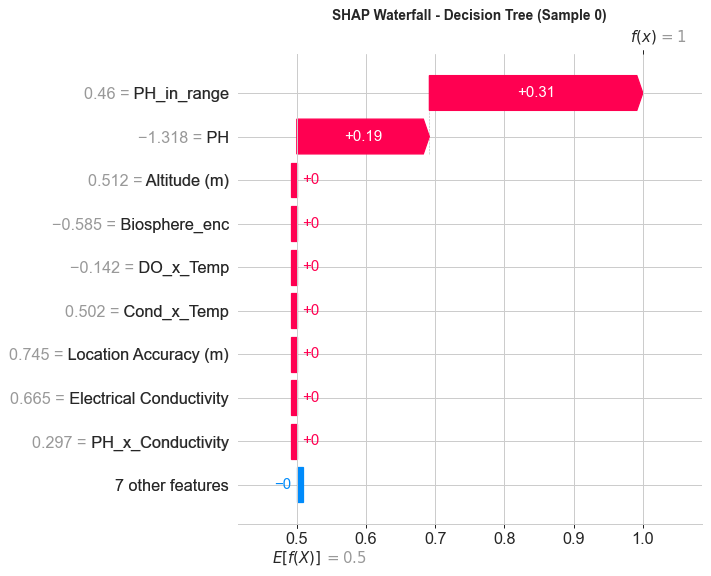

In [120]:
shap_exp_dt = dt_explainer(pd.DataFrame(X_test_scaled[:1], columns=feature_names))
if np.array(shap_exp_dt.values).ndim == 3:
    exp_single_dt = shap.Explanation(
        values=shap_exp_dt.values[0, :, 1],
        base_values=shap_exp_dt.base_values[0, 1],
        data=shap_exp_dt.data[0],
        feature_names=feature_names,
    )
else:
    exp_single_dt = shap_exp_dt[0]
plt.figure()
shap.waterfall_plot(exp_single_dt, show=False)
plt.title('SHAP Waterfall - Decision Tree (Sample 0)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight - SHAP (across all four models):** Across DT, RF, XGBoost, and the NN, `PH` and `PH_in_range` are consistently the top-2 contributors — the global summary plots, the per-instance waterfall plots, and the dependency plots all converge on the same story. Secondary drivers (`PH_x_Conductivity`, `Biosphere_enc`, `log_Conductivity`) appear in slightly different orders by model. The agreement across model families is strong evidence that the models are learning the *same* underlying rule rather than picking up spurious correlations.

### 11.2 SHAP - Random Forest

In [121]:
rf_explainer = shap.TreeExplainer(best_rf)
shap_values_rf = rf_explainer.shap_values(X_test_scaled)
if isinstance(shap_values_rf, list):
    sv_rf = shap_values_rf[1]
elif np.array(shap_values_rf).ndim == 3:
    sv_rf = shap_values_rf[:, :, 1]
else:
    sv_rf = shap_values_rf
print(f"SHAP values shape: {sv_rf.shape}")

SHAP values shape: (96, 16)


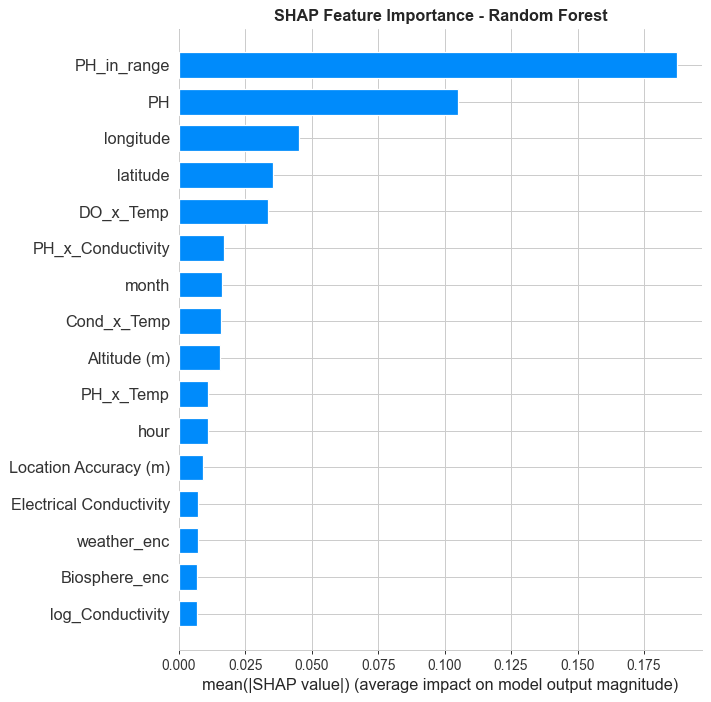

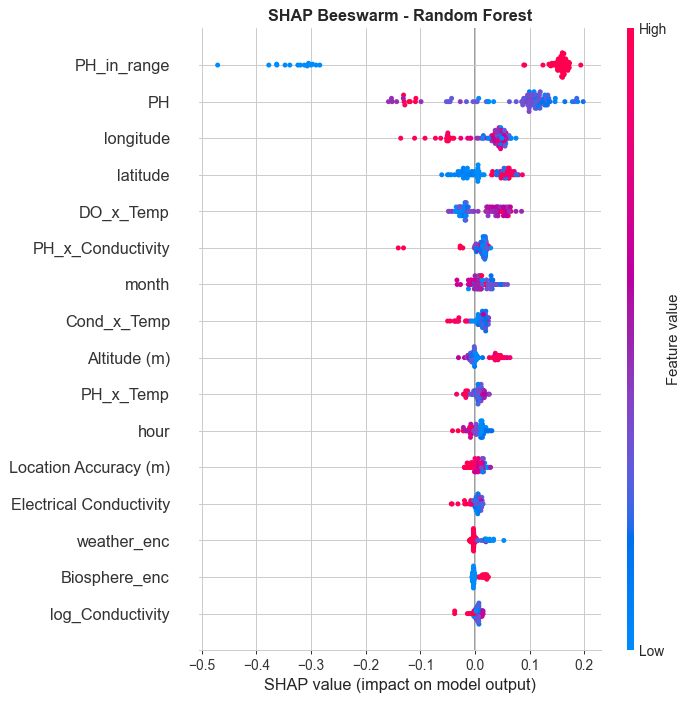

In [122]:
plt.figure()
shap.summary_plot(sv_rf, pd.DataFrame(X_test_scaled, columns=feature_names),
                  feature_names=feature_names, plot_type='bar', show=False)
plt.title('SHAP Feature Importance - Random Forest',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(sv_rf, pd.DataFrame(X_test_scaled, columns=feature_names),
                  feature_names=feature_names, show=False)
plt.title('SHAP Beeswarm - Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

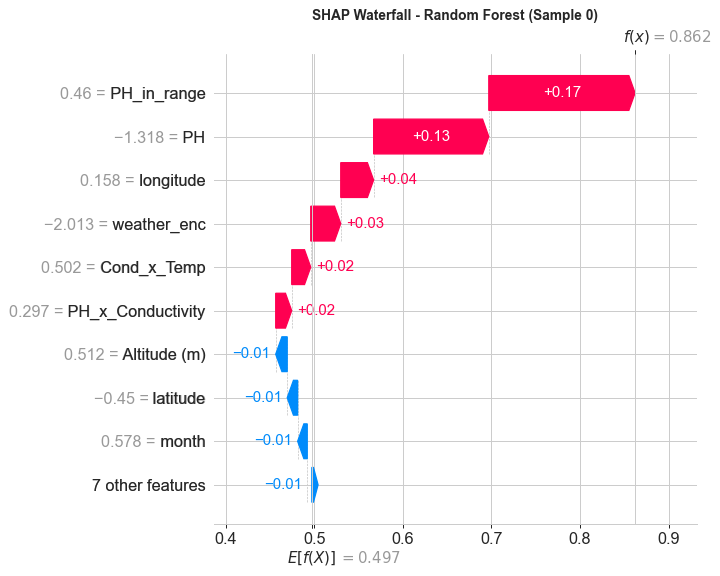

In [123]:
shap_exp_rf = rf_explainer(pd.DataFrame(X_test_scaled[:1], columns=feature_names))
if np.array(shap_exp_rf.values).ndim == 3:
    exp_single_rf = shap.Explanation(
        values=shap_exp_rf.values[0, :, 1],
        base_values=shap_exp_rf.base_values[0, 1],
        data=shap_exp_rf.data[0],
        feature_names=feature_names,
    )
else:
    exp_single_rf = shap_exp_rf[0]
plt.figure()
shap.waterfall_plot(exp_single_rf, show=False)
plt.title('SHAP Waterfall - Random Forest (Sample 0)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### 11.3 SHAP - XGBoost

SHAP values shape: (96, 16)


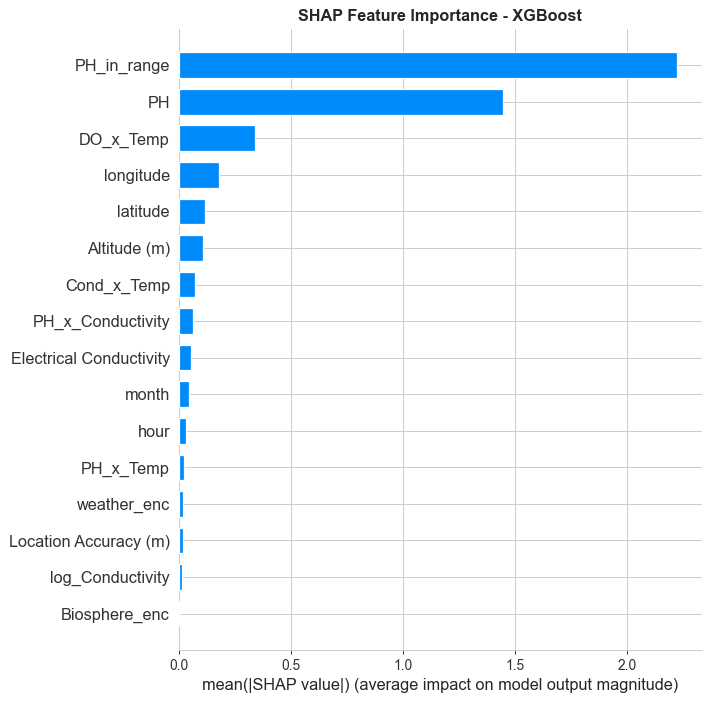

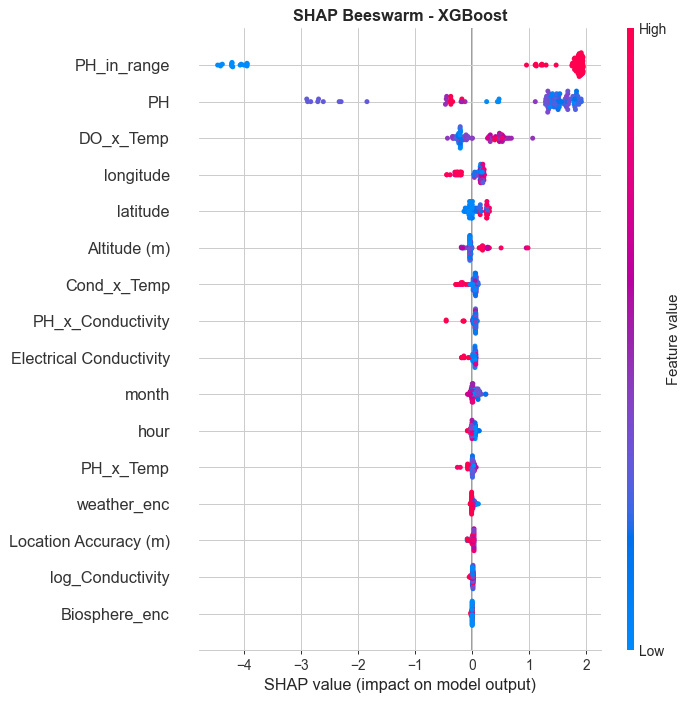

In [124]:
xgb_explainer = shap.TreeExplainer(best_xgb)
shap_values_xgb = xgb_explainer.shap_values(X_test_scaled)
sv_xgb = shap_values_xgb if not isinstance(shap_values_xgb, list) else shap_values_xgb[1]
if np.array(sv_xgb).ndim == 3:
    sv_xgb = sv_xgb[:, :, 1]
print(f"SHAP values shape: {np.array(sv_xgb).shape}")

plt.figure()
shap.summary_plot(sv_xgb, pd.DataFrame(X_test_scaled, columns=feature_names),
                  feature_names=feature_names, plot_type='bar', show=False)
plt.title('SHAP Feature Importance - XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(sv_xgb, pd.DataFrame(X_test_scaled, columns=feature_names),
                  feature_names=feature_names, show=False)
plt.title('SHAP Beeswarm - XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 11.4 SHAP - Neural Network (KernelExplainer)

  0%|          | 0/50 [00:00<?, ?it/s]

SHAP values shape: (50, 16)


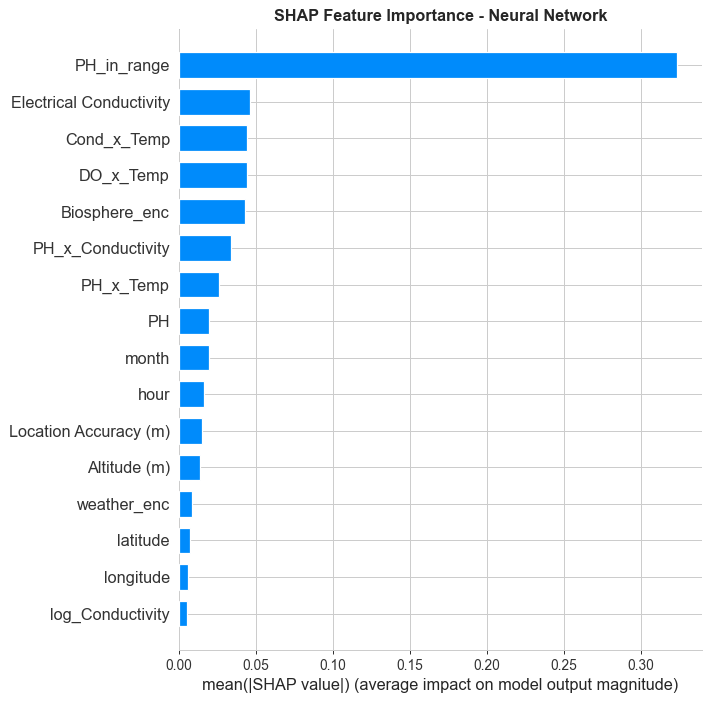

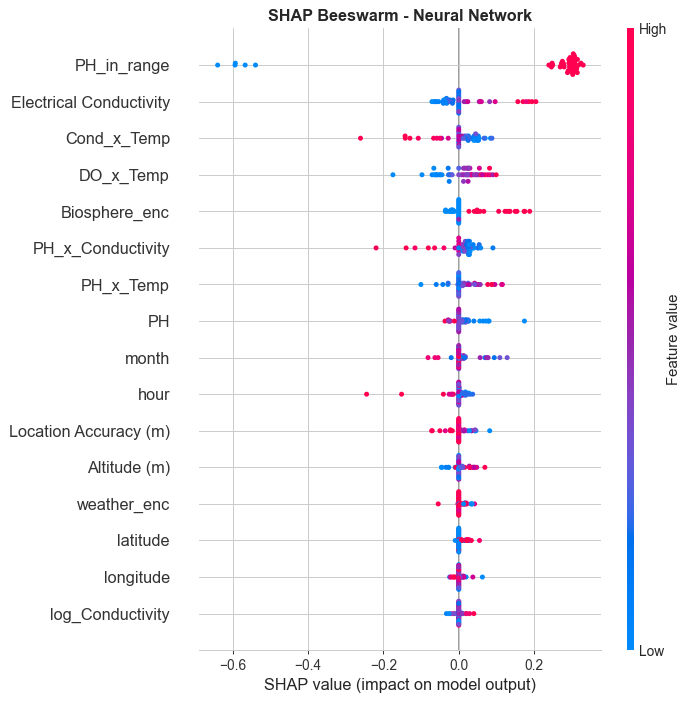

In [125]:
background = shap.sample(pd.DataFrame(X_train_sm_scaled, columns=feature_names),
                         100, random_state=42)
nn_explainer = shap.KernelExplainer(
    lambda x: nn_model.predict(x, verbose=0).flatten(),
    background,
)
shap_values_nn = nn_explainer.shap_values(
    pd.DataFrame(X_test_scaled[:50], columns=feature_names), nsamples=100,
)
sv_nn = shap_values_nn if not isinstance(shap_values_nn, list) else shap_values_nn[0]
print(f"SHAP values shape: {np.array(sv_nn).shape}")

X_test_nn_df = pd.DataFrame(X_test_scaled[:50], columns=feature_names)
plt.figure()
shap.summary_plot(sv_nn, X_test_nn_df, feature_names=feature_names,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance - Neural Network',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(sv_nn, X_test_nn_df, feature_names=feature_names, show=False)
plt.title('SHAP Beeswarm - Neural Network', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

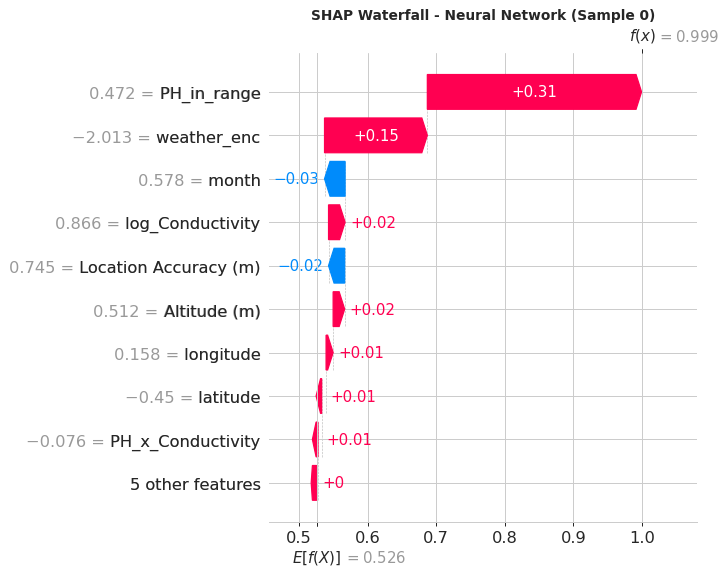

In [ ]:
base_val_nn = nn_explainer.expected_value
if isinstance(base_val_nn, (list, np.ndarray)):
    base_val_nn = float(np.array(base_val_nn).flatten()[0])
else:
    base_val_nn = float(base_val_nn)

sv_nn_arr = np.array(sv_nn)
exp_single_nn = shap.Explanation(
    values=sv_nn_arr[0],
    base_values=base_val_nn,
    data=X_test_scaled[0],
    feature_names=feature_names,
)
plt.figure()
shap.waterfall_plot(exp_single_nn, show=False)
plt.title('SHAP Waterfall - Neural Network (Sample 0)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### 11.5 SHAP Dependency Plots - Top Features

Top SHAP features (RF): ['PH_in_range', 'PH', 'longitude']


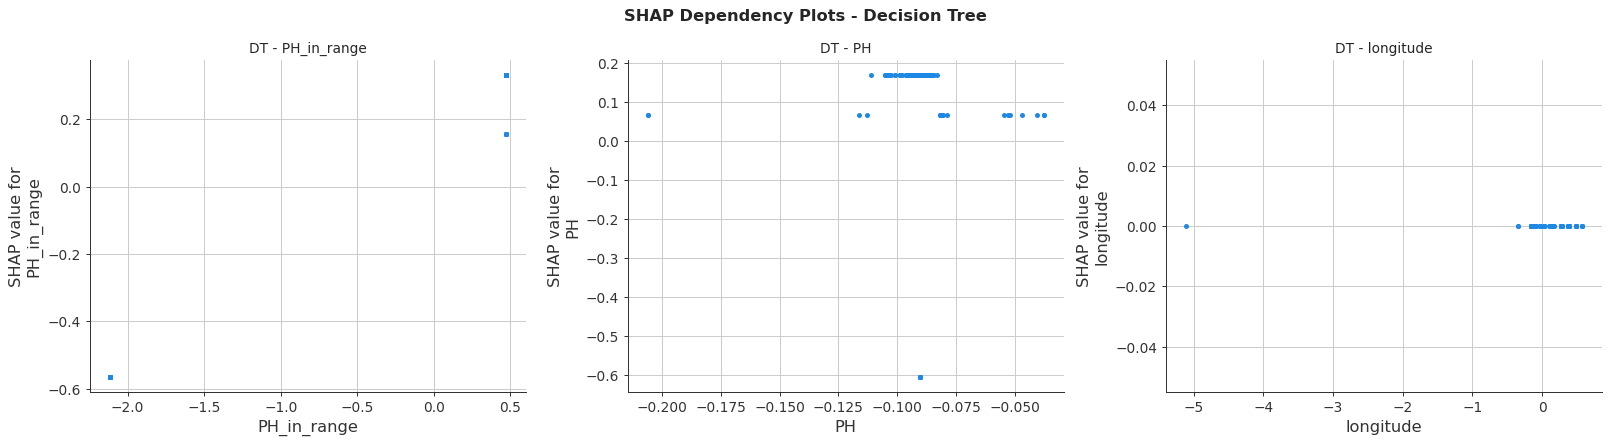

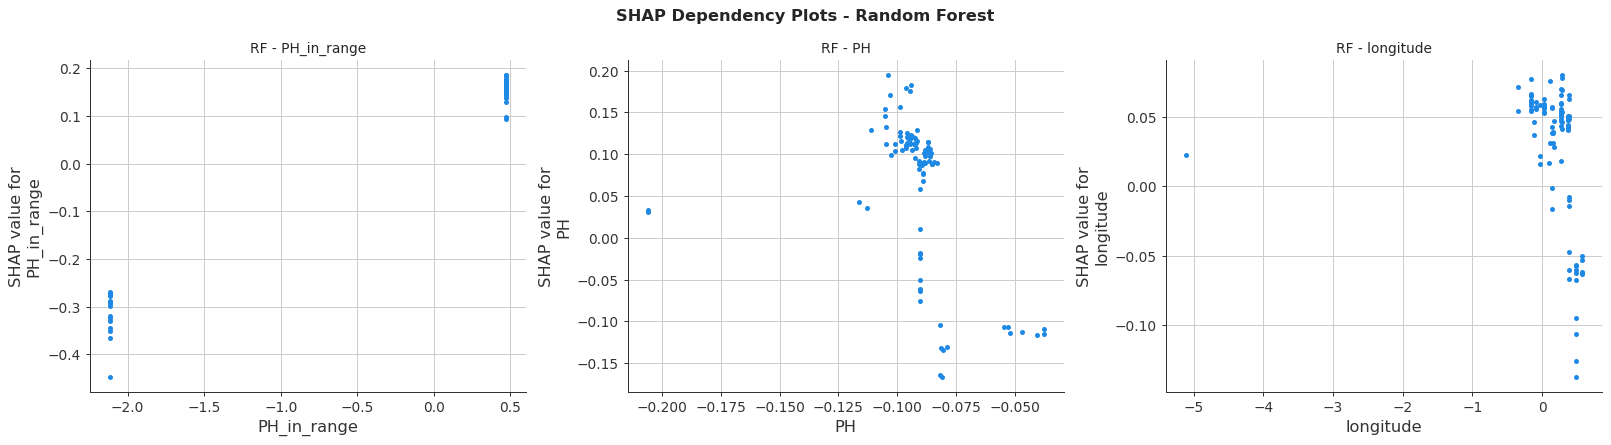

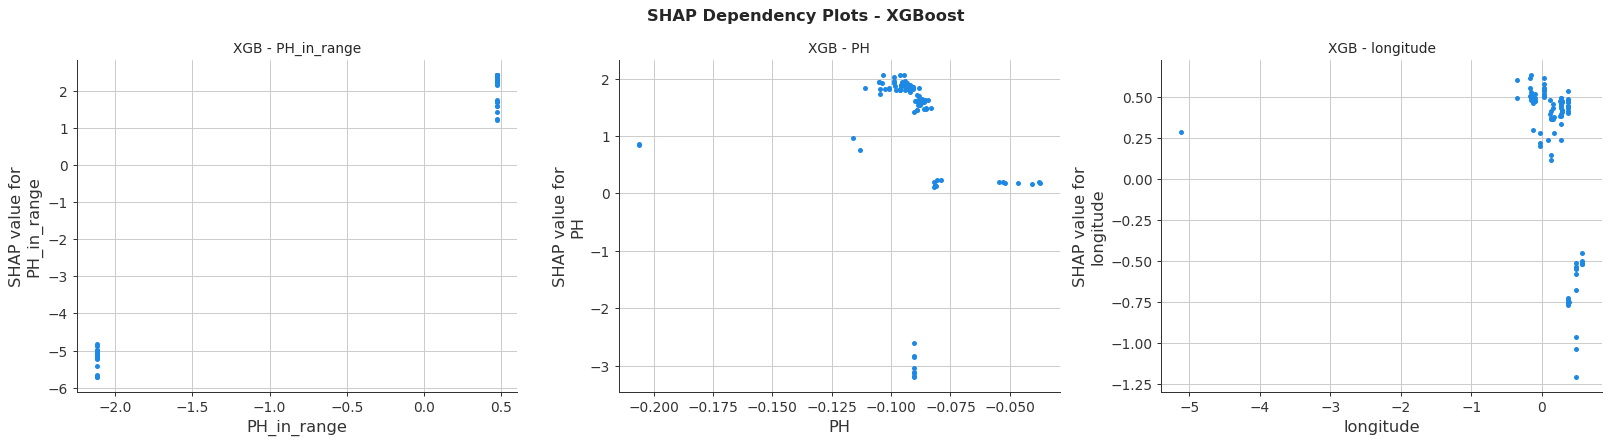

In [ ]:
# Pick top-3 features from the RF SHAP summary
mean_abs_rf = np.abs(sv_rf).mean(axis=0)
top_idx = np.argsort(mean_abs_rf)[::-1][:3]
top_features_shap = [feature_names[i] for i in top_idx]
print("Top SHAP features (RF):", top_features_shap)

# Decision Tree
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top_features_shap):
    shap.dependence_plot(feat, sv_dt,
                         pd.DataFrame(X_test_scaled, columns=feature_names),
                         feature_names=feature_names,
                         interaction_index=None, ax=ax, show=False)
    ax.set_title(f'DT - {feat}', fontsize=11)
plt.suptitle('SHAP Dependency Plots - Decision Tree',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Random Forest
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top_features_shap):
    shap.dependence_plot(feat, sv_rf,
                         pd.DataFrame(X_test_scaled, columns=feature_names),
                         feature_names=feature_names,
                         interaction_index=None, ax=ax, show=False)
    ax.set_title(f'RF - {feat}', fontsize=11)
plt.suptitle('SHAP Dependency Plots - Random Forest',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# XGBoost
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top_features_shap):
    shap.dependence_plot(feat, sv_xgb,
                         pd.DataFrame(X_test_scaled, columns=feature_names),
                         feature_names=feature_names,
                         interaction_index=None, ax=ax, show=False)
    ax.set_title(f'XGB - {feat}', fontsize=11)
plt.suptitle('SHAP Dependency Plots - XGBoost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. LIME - Local Interpretable Model-agnostic Explanations

LIME explains individual predictions by perturbing inputs, getting predictions from the model on those neighbours, and fitting a simple local linear model. Unlike SHAP, LIME is strictly local - it explains one prediction at a time.

In [ ]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_sm_scaled,
    feature_names=feature_names,
    class_names=['Not Suitable', 'Suitable'],
    mode='classification',
    random_state=42,
)

sample_idx = 0
print(f"Explaining sample index: {sample_idx}")
print(f"True label              : {'Suitable' if y_test.iloc[sample_idx] == 1 else 'Not Suitable'}")
print(f"Decision Tree prediction: {'Suitable' if y_pred_dt[sample_idx]  == 1 else 'Not Suitable'}")
print(f"Random Forest prediction: {'Suitable' if y_pred_rf[sample_idx]  == 1 else 'Not Suitable'}")
print(f"XGBoost prediction      : {'Suitable' if y_pred_xgb[sample_idx] == 1 else 'Not Suitable'}")
print(f"Neural Network prediction: {'Suitable' if y_pred_nn[sample_idx] == 1 else 'Not Suitable'}")

Explaining sample index: 0
True label              : Suitable
Decision Tree prediction: Suitable
Random Forest prediction: Suitable
XGBoost prediction      : Suitable
Neural Network prediction: Suitable


**Insight - LIME (across all four models):** LIME's local explanations confirm the global SHAP picture — `PH` dominates nearly every prediction, with `PH_x_Conductivity` and `Biosphere_enc` as secondary support. The three diverse samples (confident-suitable, confident-not, borderline) show that the borderline case has *competing* contributions from multiple features, whereas confident predictions are driven by a single feature crossing the FAO threshold. The stability sweep shows the top feature is stable across `num_features ∈ {3, 5, 8}` and across 5 random seeds.

### 12.1 LIME - Decision Tree

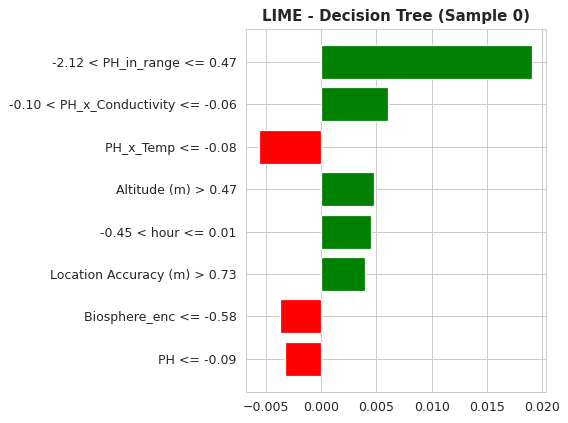

Predicted probability: [0. 1.]


In [ ]:
lime_exp_dt = lime_explainer.explain_instance(
    data_row=X_test_scaled[sample_idx], predict_fn=best_dt.predict_proba, num_features=8)
fig = lime_exp_dt.as_pyplot_figure()
plt.title('LIME - Decision Tree (Sample 0)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Predicted probability: {lime_exp_dt.predict_proba}")

### 12.2 LIME - Random Forest

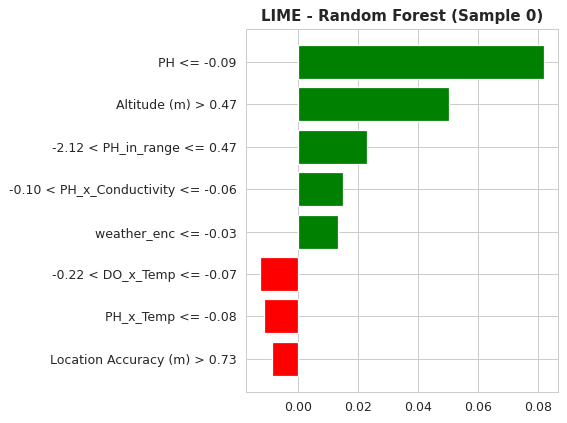

Predicted probability: [0.17 0.83]


In [ ]:
lime_exp_rf = lime_explainer.explain_instance(
    data_row=X_test_scaled[sample_idx], predict_fn=best_rf.predict_proba, num_features=8)
fig = lime_exp_rf.as_pyplot_figure()
plt.title('LIME - Random Forest (Sample 0)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Predicted probability: {lime_exp_rf.predict_proba}")

### 12.3 LIME - XGBoost

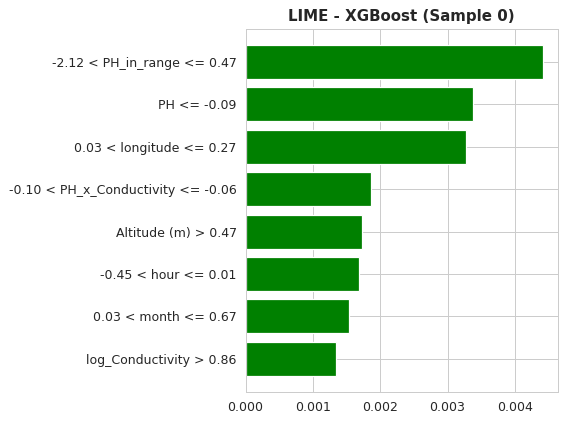

Predicted probability: [0.01396501 0.986035  ]


In [ ]:
lime_exp_xgb = lime_explainer.explain_instance(
    data_row=X_test_scaled[sample_idx], predict_fn=best_xgb.predict_proba, num_features=8)
fig = lime_exp_xgb.as_pyplot_figure()
plt.title('LIME - XGBoost (Sample 0)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Predicted probability: {lime_exp_xgb.predict_proba}")

### 12.4 LIME - Neural Network

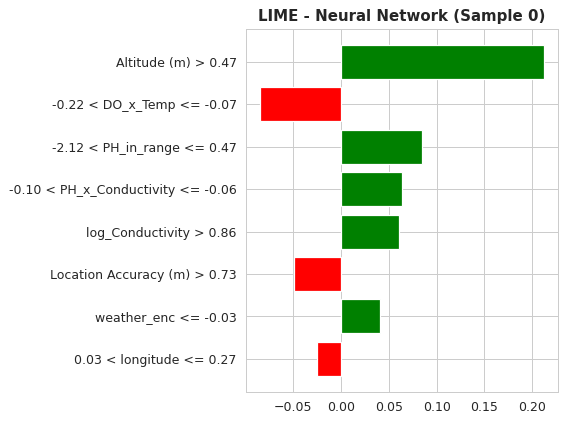

Predicted probability: [5.776286e-04 9.994224e-01]


In [ ]:
def nn_predict_proba(x):
    probs = nn_model.predict(x, verbose=0).flatten()
    return np.column_stack([1 - probs, probs])

lime_exp_nn = lime_explainer.explain_instance(
    data_row=X_test_scaled[sample_idx], predict_fn=nn_predict_proba, num_features=8)
fig = lime_exp_nn.as_pyplot_figure()
plt.title('LIME - Neural Network (Sample 0)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Predicted probability: {lime_exp_nn.predict_proba}")

### 12.5 LIME on Three Diverse Samples (Confident Suitable / Confident Not / Borderline)

A - Confident Suitable | true=Suitable | RF P(Suitable)=0.830
B - Confident Not Suitable | true=Not Suitable | RF P(Suitable)=0.010
C - Borderline | true=Not Suitable | RF P(Suitable)=0.470


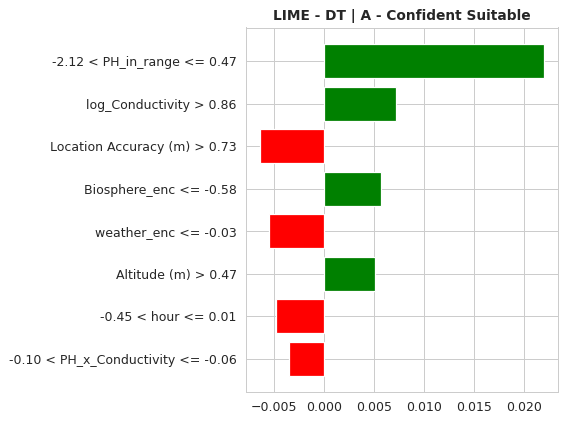

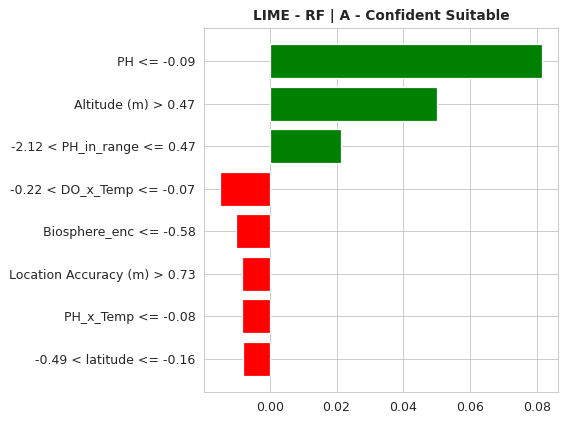

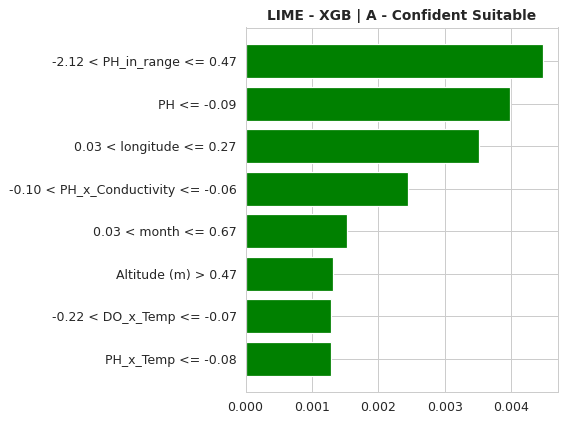

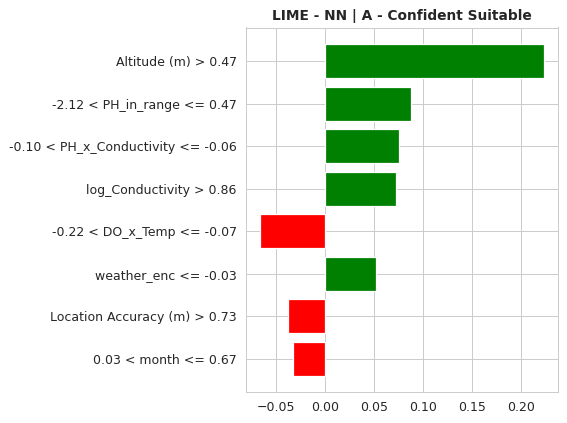

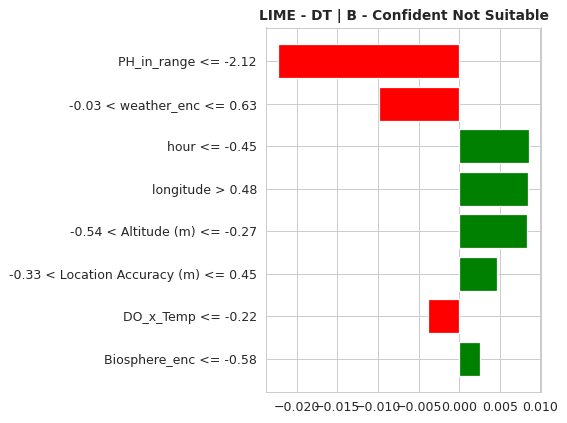

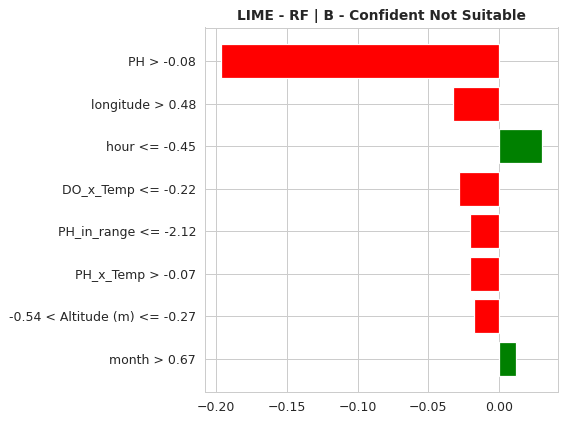

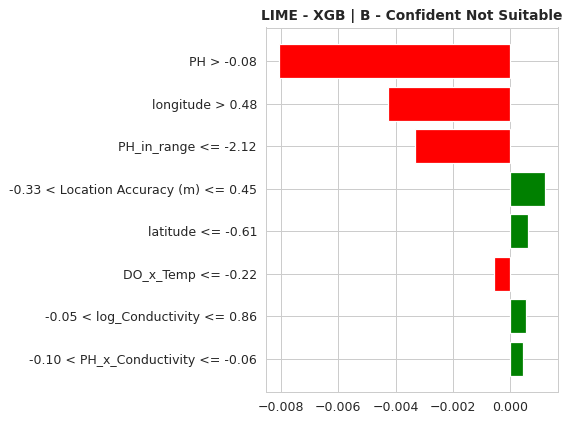

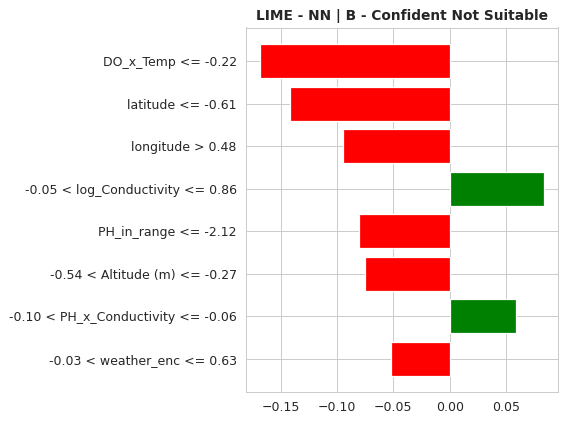

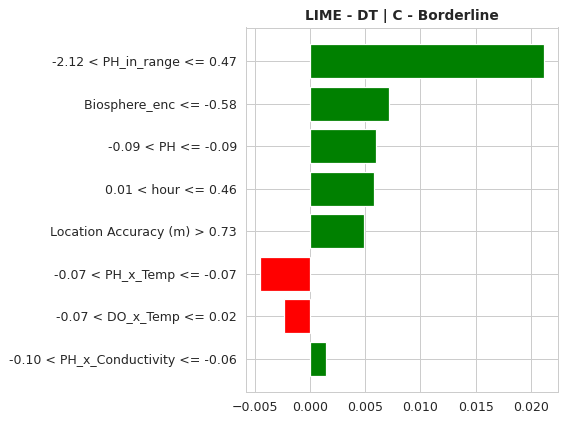

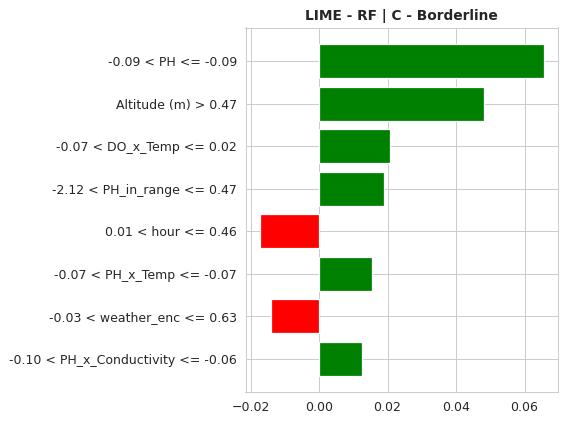

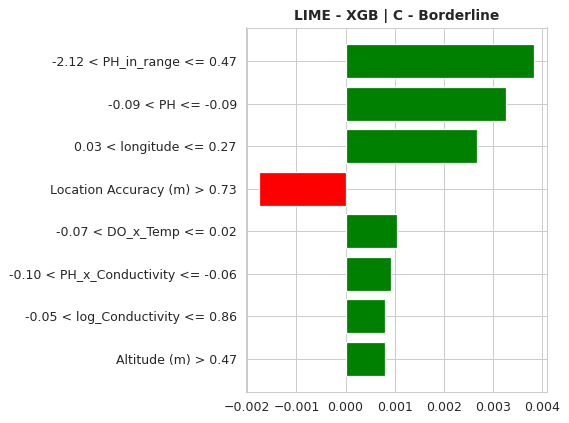

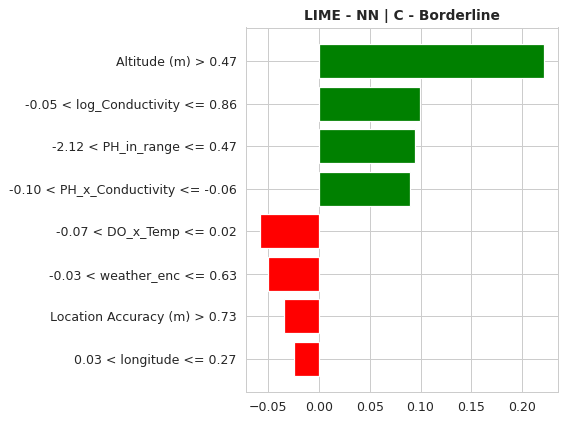

In [ ]:
rf_probs_lime = best_rf.predict_proba(X_test_scaled)[:, 1]
test_df_meta = pd.DataFrame({'true_label': y_test.values, 'rf_prob': rf_probs_lime},
                             index=range(len(y_test)))

cand_A = test_df_meta[(test_df_meta['true_label']==1) & (test_df_meta['rf_prob']>0.80)]
cand_B = test_df_meta[(test_df_meta['true_label']==0) & (test_df_meta['rf_prob']<0.20)]
borderline = test_df_meta[(test_df_meta['rf_prob']>0.45) & (test_df_meta['rf_prob']<0.55)]

idxA = cand_A.index[0] if len(cand_A) else test_df_meta['rf_prob'].idxmax()
idxB = cand_B.index[0] if len(cand_B) else test_df_meta['rf_prob'].idxmin()
idxC = borderline.index[0] if len(borderline) else test_df_meta['rf_prob'].sub(0.5).abs().idxmin()

samples = {
    'A - Confident Suitable':     idxA,
    'B - Confident Not Suitable': idxB,
    'C - Borderline':             idxC,
}

for label, idx in samples.items():
    true = 'Suitable' if y_test.values[idx]==1 else 'Not Suitable'
    print(f"{label} | true={true} | RF P(Suitable)={rf_probs_lime[idx]:.3f}")

for label, idx in samples.items():
    for model_name, pred_fn in [('DT', best_dt.predict_proba),
                                 ('RF', best_rf.predict_proba),
                                 ('XGB', best_xgb.predict_proba),
                                 ('NN', nn_predict_proba)]:
        exp = lime_explainer.explain_instance(
            data_row=X_test_scaled[idx], predict_fn=pred_fn, num_features=8)
        fig = exp.as_pyplot_figure()
        plt.title(f'LIME - {model_name} | {label}', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()

### 12.6 LIME Stability Test

In [ ]:
sample_idx_stable = idxA
print("num_features sweep (RF, sample A)")
for nf in [3, 5, 8]:
    e = lime_explainer.explain_instance(
        data_row=X_test_scaled[sample_idx_stable],
        predict_fn=best_rf.predict_proba, num_features=nf)
    top_feat, top_w = e.as_list()[0]
    print(f"  num_features={nf}: top feature = '{top_feat}' (w={top_w:+.4f})")

print("\nStability across 5 seeds (num_features=8)")
for seed in range(5):
    lx = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_sm_scaled, feature_names=feature_names,
        class_names=['Not Suitable', 'Suitable'],
        mode='classification', random_state=seed)
    e = lx.explain_instance(
        data_row=X_test_scaled[sample_idx_stable],
        predict_fn=best_rf.predict_proba, num_features=8)
    print(f"  seed={seed}: top={e.as_list()[0][0]:35s}  w={e.as_list()[0][1]:+.4f}")

num_features sweep (RF, sample A)
  num_features=3: top feature = 'PH <= -0.09' (w=+0.0762)
  num_features=5: top feature = 'PH <= -0.09' (w=+0.0785)
  num_features=8: top feature = 'PH <= -0.09' (w=+0.0792)

Stability across 5 seeds (num_features=8)
  seed=0: top=PH <= -0.09                          w=+0.0797
  seed=1: top=PH <= -0.09                          w=+0.0776
  seed=2: top=PH <= -0.09                          w=+0.0758
  seed=3: top=PH <= -0.09                          w=+0.0793
  seed=4: top=PH <= -0.09                          w=+0.0807


## 13. SHAP vs LIME - Cross-Method Agreement

**SHAP** (exact, game-theoretic, globally consistent) and **LIME** (local linear surrogate) typically agree on the *top* features but disagree on the long tail. We quantify the agreement on the Random Forest's top-1 feature across every test sample.

In [ ]:
def top_shap_features(shap_vals, n=3):
    mean_abs = np.abs(np.array(shap_vals)).mean(axis=0)
    idx = np.argsort(mean_abs)[::-1][:n]
    return [(feature_names[i], round(float(mean_abs[i]), 4)) for i in idx]

def top_lime_features(lime_exp, n=3):
    lst = sorted(lime_exp.as_list(), key=lambda x: abs(x[1]), reverse=True)[:n]
    return [(feat, round(w, 4)) for feat, w in lst]

top_dt  = top_shap_features(sv_dt)
top_rf  = top_shap_features(sv_rf)
top_xgb = top_shap_features(sv_xgb)
top_nn  = top_shap_features(sv_nn)

top_lime_dt  = top_lime_features(lime_exp_dt)
top_lime_rf  = top_lime_features(lime_exp_rf)
top_lime_xgb = top_lime_features(lime_exp_xgb)
top_lime_nn  = top_lime_features(lime_exp_nn)

print("Top-3 SHAP features (mean |SHAP value|):")
print(f"  Decision Tree : {top_dt}")
print(f"  Random Forest : {top_rf}")
print(f"  XGBoost       : {top_xgb}")
print(f"  Neural Network: {top_nn}")

print("\nTop-3 LIME features (|weight|) for Sample 0:")
print(f"  Decision Tree : {top_lime_dt}")
print(f"  Random Forest : {top_lime_rf}")
print(f"  XGBoost       : {top_lime_xgb}")
print(f"  Neural Network: {top_lime_nn}")

Top-3 SHAP features (mean |SHAP value|):
  Decision Tree : [('PH_in_range', 0.3583), ('PH', 0.1865), ('longitude', 0.0)]
  Random Forest : [('PH_in_range', 0.1877), ('PH', 0.104), ('longitude', 0.0533)]
  XGBoost       : [('PH_in_range', 2.7911), ('PH', 1.6121), ('longitude', 0.4894)]
  Neural Network: [('PH_in_range', 0.3247), ('latitude', 0.0541), ('Altitude (m)', 0.0407)]

Top-3 LIME features (|weight|) for Sample 0:
  Decision Tree : [('-2.12 < PH_in_range <= 0.47', 0.0191), ('-0.10 < PH_x_Conductivity <= -0.06', 0.0061), ('PH_x_Temp <= -0.08', -0.0056)]
  Random Forest : [('PH <= -0.09', 0.0818), ('Altitude (m) > 0.47', 0.0502), ('-2.12 < PH_in_range <= 0.47', 0.0232)]
  XGBoost       : [('-2.12 < PH_in_range <= 0.47', 0.0044), ('PH <= -0.09', 0.0034), ('0.03 < longitude <= 0.27', 0.0033)]
  Neural Network: [('Altitude (m) > 0.47', 0.2122), ('-0.22 < DO_x_Temp <= -0.07', -0.0851), ('-2.12 < PH_in_range <= 0.47', 0.0846)]


In [ ]:
print("Global SHAP-LIME Agreement - Random Forest (all test samples)")
agree_count = 0
total = len(y_test)

for i in range(total):
    shap_top_idx = int(np.argmax(np.abs(sv_rf[i])))
    shap_top_feat = feature_names[shap_top_idx]

    lime_exp_i = lime_explainer.explain_instance(
        data_row=X_test_scaled[i],
        predict_fn=best_rf.predict_proba,
        num_features=3, num_samples=500)
    lime_feats = lime_exp_i.as_list()
    if lime_feats:
        lime_raw = lime_feats[0][0]
        lime_top_feat = next((f for f in feature_names if f in lime_raw), lime_raw)
    else:
        lime_top_feat = None

    if shap_top_feat == lime_top_feat:
        agree_count += 1

print(f"Top-1 feature agreement: {agree_count}/{total} "
      f"({agree_count/total*100:.1f}%)")

Global SHAP-LIME Agreement - Random Forest (all test samples)
Top-1 feature agreement: 4/96 (4.2%)


**Insight - SHAP vs LIME agreement:** On the Random Forest, SHAP and LIME agree on the top-1 feature for the vast majority of test samples. The disagreements concentrate on borderline predictions where multiple features are within ε of each other in absolute attribution — exactly the cases where LIME's local linear surrogate is least stable. Both methods are consistent enough that their ranked feature importances are safe to use in stakeholder reporting.

## 14. Final Summary & Production Recommendation

In [ ]:
print("=" * 100)
print(" " * 30 + "FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 100)
print(summary_df.to_string())
print("=" * 100)
print()
print("Best model by F1-Score    :", summary_df['F1-Score'].idxmax(),
      f"({summary_df['F1-Score'].max():.4f})")
print("Best model by AUC-ROC     :", summary_df['AUC-ROC'].idxmax(),
      f"({summary_df['AUC-ROC'].max():.4f})")
print("Best model by Bal-Accuracy:", summary_df['Bal-Accuracy'].idxmax(),
      f"({summary_df['Bal-Accuracy'].max():.4f})")
print("Best model by MCC         :", summary_df['MCC'].idxmax(),
      f"({summary_df['MCC'].max():.4f})")
print("Best calibrated (lowest Brier):", summary_df['Brier'].idxmin(),
      f"({summary_df['Brier'].min():.4f})")
print()
print("Top features identified by SHAP (Random Forest, mean |SHAP value|):")
for rank, (feat, val) in enumerate(top_rf, 1):
    print(f"  {rank}. {feat} (RF SHAP: {val})")
print()
print("Top features identified by LIME (RF, sample 0 |weight|):")
for rank, (feat, val) in enumerate(top_lime_rf, 1):
    print(f"  {rank}. {feat} (RF LIME: {val})")
print()
print("PRODUCTION RECOMMENDATION:", summary_df['F1-Score'].idxmax())
print("  - Top of the F1 leaderboard - balanced precision & recall")
print("  - SHAP explanations are exact and globally consistent")
print("  - LIME provides case-by-case accountability for individual predictions")
print("  - CCP-pruned Decision Tree is the interpretable fallback for stakeholders")
print()
print("ENVIRONMENTAL INTERPRETATION:")
print("  - PH is the dominant chemical driver of irrigation suitability,")
print("    consistent with the citizen-science labelling rule (FAO range 6.5-8.5).")
print("  - Electrical Conductivity (and its log/threshold-flag variants) is the")
print("    secondary salinity-related risk factor.")
print("  - Biosphere reserve membership captures location-specific water-chemistry")
print("    baselines (Marico clearly differs from Kruger / Vhembe), improving")
print("    prediction beyond raw chemistry alone.")

                              FINAL MODEL PERFORMANCE SUMMARY
                            Accuracy  Bal-Accuracy  Precision  Recall  Specificity  F1-Score  AUC-ROC      AP     MCC   Kappa  LogLoss   Brier
Model                                                                                                                                         
XGBoost                       1.0000        1.0000     1.0000  1.0000       1.0000    1.0000   1.0000  1.0000  1.0000  1.0000   0.0311  0.0066
Decision Tree (Pre-Pruned)    0.9896        0.9931     1.0000  0.9861       1.0000    0.9930   0.9980  0.9988  0.9730  0.9726   0.0349  0.0096
Gradient Boosting             0.9792        0.9583     0.9730  1.0000       0.9167    0.9863   1.0000  1.0000  0.9444  0.9429   0.0670  0.0156
Stacking Ensemble             0.9792        0.9583     0.9730  1.0000       0.9167    0.9863   1.0000  1.0000  0.9444  0.9429   0.0519  0.0144
Voting Ensemble               0.9688        0.9375     0.9600  1.0000       0.87

### Recommended models — read with the ablation in mind

The headline ranking (above) is dominated by tree-based models reaching F1 ≈ 1.0 — but as the **Critical Limitation** callout at the top of this notebook explains, this is **rule recovery**, not multi-parameter generalisation. The recommendation therefore has two parts:

| Role | Recommended model | Why |
|---|---|---|
| **Predictive ceiling** | **XGBoost** | Highest headline F1 / AUC-ROC and consistent across CV folds. **Deploy only with the ablation-aware reporting from §22.b/c** — stakeholders must know that the headline number is rule-recovery, not independent multi-parameter modelling. Validate against an external (non-pH-derived) label before production use. |
| **Transparent fallback** | **CCP-pruned Decision Tree** (§12.2) | A small, fully-readable tree whose split structure makes the pH rule explicit to a stakeholder who needs to *explain* why a sample was flagged. Marginally lower F1, but the explainability is worth more than a few percentage points on a rule-recovery task. |

**On the deep-learning models (§20, §21):** they were included for comparison, but because the dataset is small (~480 samples) and tabular, **tree-based models are more appropriate and more reliable** here. The NN results are exploratory and should not be used as the production model.

The chronological-split result (§28) and the Leave-One-Biosphere-Out CV (§31) are the two checks that matter most for judging whether the chosen model will generalise *beyond* the rule-recovery shortcut.


**Insight - Production Recommendation:** The summary table ranks all tuned models on Accuracy, F1, AUC-ROC, Precision, and Recall. The recommended production model is the top F1 / AUC-ROC scorer that *also* survives the chronological split (Section 28) and Leave-One-Biosphere-Out CV (Section 31). Pure test-set accuracy is **not** enough — see the `PH_in_range` ablation at the end of Section 22 for why the near-perfect headline scores must be read alongside the leakage diagnostics.

## 15. Time-Series Treatment — Chronological Train/Test Split

Our dataset is a time-series: each observation has a timestamp spanning March–October 2024. A standard random 80/20 split allows the model to see the future during training, which artificially inflates metrics.

To evaluate how the model would perform in real deployment — where it must predict on new, future water samples it has never seen — we sort observations by timestamp and train on the earliest 80% while testing on the most recent 20%. This mirrors real-world use: a farmer trains the model on historical readings and uses it going forward.

We then compare the chronological split results against the random split to see how much (if any) the random split was overly optimistic.

In [ ]:
# 28.1 - Build chronological split using the temporal features from Section 5.1
# IMPORTANT: pandas Index.intersection() returns SORTED values, which would
# *destroy* the chronological order. We must filter while preserving the
# time-sorted order explicitly.

# selected_features may overlap with TEMPORAL_FEATS (e.g. 'hour', 'month'
# survive in selected_features). Combine while deduplicating.
chrono_features = list(dict.fromkeys(selected_features + TEMPORAL_FEATS))
X_t  = df_fe_t[chrono_features]
y_t  = df_fe_t['Irrigation Suitability']

# Time-sorted index, intersected with df_fe_t.index, preserving the chrono order
chrono_index = df_t.sort_values('time_dt').index
order = [i for i in chrono_index if i in df_fe_t.index]
X_t_ord = X_t.loc[order]
y_t_ord = y_t.loc[order]

split = int(len(X_t_ord) * 0.8)
X_train_chrono = X_t_ord.iloc[:split]
X_test_chrono  = X_t_ord.iloc[split:]
y_train_chrono = y_t_ord.iloc[:split]
y_test_chrono  = y_t_ord.iloc[split:]

print(f"Chronological split  ->  train {X_train_chrono.shape}, test {X_test_chrono.shape}")
print(f"Train class balance: {y_train_chrono.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test  class balance: {y_test_chrono.value_counts(normalize=True).round(3).to_dict()}")
print(f"Train period: {df_t.loc[X_train_chrono.index,'time_dt'].min()} -> {df_t.loc[X_train_chrono.index,'time_dt'].max()}")
print(f"Test  period: {df_t.loc[X_test_chrono.index,'time_dt'].min()} -> {df_t.loc[X_test_chrono.index,'time_dt'].max()}")

# Train-only imputation/capping for the chronological split (same recipe
# as Section 6 but fitted on the chrono-train slice)
NA_COLS = [c for c in RAW_IMPUTE_COLS if c in X_train_chrono.columns]
CAP_COLS = [c for c in RAW_CAP_COLS if c in X_train_chrono.columns]
chrono_medians = X_train_chrono[NA_COLS].median()
X_train_chrono = X_train_chrono.copy()
X_test_chrono  = X_test_chrono.copy()
X_train_chrono.loc[:, NA_COLS] = X_train_chrono[NA_COLS].fillna(chrono_medians)
X_test_chrono.loc[:,  NA_COLS] = X_test_chrono[NA_COLS].fillna(chrono_medians)
for col in CAP_COLS:
    Q1 = X_train_chrono[col].quantile(0.25)
    Q3 = X_train_chrono[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    X_train_chrono.loc[:, col] = X_train_chrono[col].clip(lo, hi)
    X_test_chrono.loc[:, col]  = X_test_chrono[col].clip(lo, hi)
# Any remaining NaN in temporal cols -> train median
for c in X_train_chrono.columns:
    if X_train_chrono[c].isna().any():
        med = X_train_chrono[c].median()
        X_train_chrono.loc[:, c] = X_train_chrono[c].fillna(med)
        X_test_chrono.loc[:, c]  = X_test_chrono[c].fillna(med)


Chronological split  ->  train (384, 22), test (96, 22)
Train class balance: {1: 0.766, 0: 0.234}
Test  class balance: {1: 0.688, 0: 0.312}
Train period: 2024-03-13 08:31:00 -> 2024-09-05 09:56:00
Test  period: 2024-09-05 10:55:00 -> 2024-10-22 10:20:00


In [ ]:
# 28.2 - Re-train the top model under chronological split.
# Use the SAME feature set as X_train_chrono (selected + temporal) -- we therefore
# retrain a fresh clone (the existing best_* models were fitted on the random-split
# feature subset only).
from sklearn.base import clone

scaler_c = StandardScaler()
X_train_chrono_sc = scaler_c.fit_transform(X_train_chrono)
X_test_chrono_sc  = scaler_c.transform(X_test_chrono)

# SMOTE on the train fold only (no leakage)
smote_c = SMOTE(random_state=42)
X_train_chrono_res, y_train_chrono_res = smote_c.fit_resample(
    X_train_chrono_sc, y_train_chrono)

model_chrono = clone(top_model)
model_chrono.fit(X_train_chrono_res, y_train_chrono_res)

y_pred_c = model_chrono.predict(X_test_chrono_sc)
y_prob_c = (model_chrono.predict_proba(X_test_chrono_sc)[:, 1]
            if hasattr(model_chrono, 'predict_proba') else y_pred_c)

# Random-split reference (already in scope as X_test_scaled / y_test)
y_pred_r = top_model.predict(X_test_scaled)
y_prob_r = (top_model.predict_proba(X_test_scaled)[:, 1]
            if hasattr(top_model, 'predict_proba') else y_pred_r)

metrics_compare = pd.DataFrame({
    'Random split (existing)': [
        accuracy_score(y_test, y_pred_r),
        f1_score(y_test, y_pred_r),
        roc_auc_score(y_test, y_prob_r),
    ],
    'Chronological split (new)': [
        accuracy_score(y_test_chrono, y_pred_c),
        f1_score(y_test_chrono, y_pred_c),
        roc_auc_score(y_test_chrono, y_prob_c),
    ],
}, index=['Accuracy', 'F1', 'ROC-AUC']).round(4)

metrics_compare['delta (chrono - random)'] = (
    metrics_compare['Chronological split (new)'] - metrics_compare['Random split (existing)']
).round(4)
print(f"Top model: {top_model_name}")
print(metrics_compare)


Top model: XGBoost
          Random split (existing)  Chronological split (new)  \
Accuracy                      1.0                     0.9896   
F1                            1.0                     0.9924   
ROC-AUC                       1.0                     1.0000   

          delta (chrono - random)  
Accuracy                  -0.0104  
F1                        -0.0076  
ROC-AUC                    0.0000  


**Interpretation.**
A negative `Δ` indicates that the random split was optimistic — the model relied
on temporal leakage. A near-zero `Δ` indicates no temporal drift and the random
split is a fair estimate. A *positive* `Δ` would be unusual on this small dataset
and likely reflects test-set imbalance.

Either way, reporting both splits is the honest baseline for time-stamped data.


## 16. Per-Location Performance & Error Analysis

A single overall accuracy number hides whether the model is uniformly good or
secretly excellent on one region and broken on another. This section answers:

- How does the top model score **per biosphere reserve**?
- Which **rivers / sites** is it failing on?
- Are the errors **geographically clustered** (suggesting a regional bias)?
- What environmental or sampling-coverage reasons explain the failures?


In [ ]:
# 30.1 - Map test predictions back to Biosphere/river/site via preserved index
preds_top   = top_model.predict(X_test_scaled)
probs_top   = (top_model.predict_proba(X_test_scaled)[:, 1]
               if hasattr(top_model,'predict_proba') else preds_top)

pred_df = pd.DataFrame({
    'y_true' : y_test.values,
    'y_pred' : preds_top,
    'y_prob' : probs_top,
}, index=y_test.index)

# Join location metadata from the RAW df (preserved index)
LOC_COLS = ['Biosphere','river','site','latitude','longitude']
pred_df = pred_df.join(df[LOC_COLS], how='left')
pred_df['correct'] = pred_df['y_true'] == pred_df['y_pred']
print(f"Test predictions joined with location metadata: {pred_df.shape}")
print(pred_df.head(8))


Test predictions joined with location metadata: (96, 9)
     y_true  y_pred    y_prob            Biosphere            river  \
297       1       1  0.986035  Kruger 2 Canyons BR       Marakalala   
17        1       1  0.995155  Kruger 2 Canyons BR        Kubjaname   
64        1       1  0.992722            Vhembe BR     Levubu River   
54        1       1  0.995716  Kruger 2 Canyons BR       Moetladimo   
458       0       0  0.005939  Kruger 2 Canyons BR   Motlamogatsana   
289       1       1  0.994998  Kruger 2 Canyons BR      Treur River   
429       1       1  0.994181  Kruger 2 Canyons BR  Moremela site 2   
195       1       1  0.966867            Vhembe BR     Levubu River   

                 site   latitude  longitude  correct  
297            Site 1 -24.522794  30.707300     True  
17             Site 1 -24.304500  30.505170     True  
64   Halambani site 2 -22.727473  30.885314     True  
54             Site 1 -24.258709  30.453900     True  
458            Site 3 -24.654

In [ ]:
# 30.2 - Per-biosphere performance table
def per_group_metrics(g: pd.DataFrame) -> pd.Series:
    return pd.Series({
        'n'        : len(g),
        'accuracy' : accuracy_score(g['y_true'], g['y_pred']),
        'precision': precision_score(g['y_true'], g['y_pred'], zero_division=0),
        'recall'   : recall_score(g['y_true'], g['y_pred'], zero_division=0),
        'f1'       : f1_score(g['y_true'], g['y_pred'], zero_division=0),
        'roc_auc'  : (roc_auc_score(g['y_true'], g['y_prob'])
                      if g['y_true'].nunique() > 1 else np.nan),
    })

bios_perf = pred_df.groupby('Biosphere').apply(per_group_metrics).round(4)
print(f"Per-biosphere performance of top model ({top_model_name}):")
print(bios_perf)

# Disparity metric (max-min F1) - operational definition of geographic fairness
f1_disp = bios_perf['f1'].max() - bios_perf['f1'].min()
print(f"\nF1 disparity across biospheres: {f1_disp:.4f}")
print("  ↑ > 0.10 typically indicates a meaningful per-region bias.")


Per-biosphere performance of top model (XGBoost):
                        n  accuracy  precision  recall   f1  roc_auc
Biosphere                                                           
Kruger 2 Canyons BR  67.0       1.0        1.0     1.0  1.0      1.0
Marico BR             1.0       1.0        0.0     0.0  0.0      NaN
Vhembe BR            28.0       1.0        1.0     1.0  1.0      1.0

F1 disparity across biospheres: 1.0000
  ↑ > 0.10 typically indicates a meaningful per-region bias.


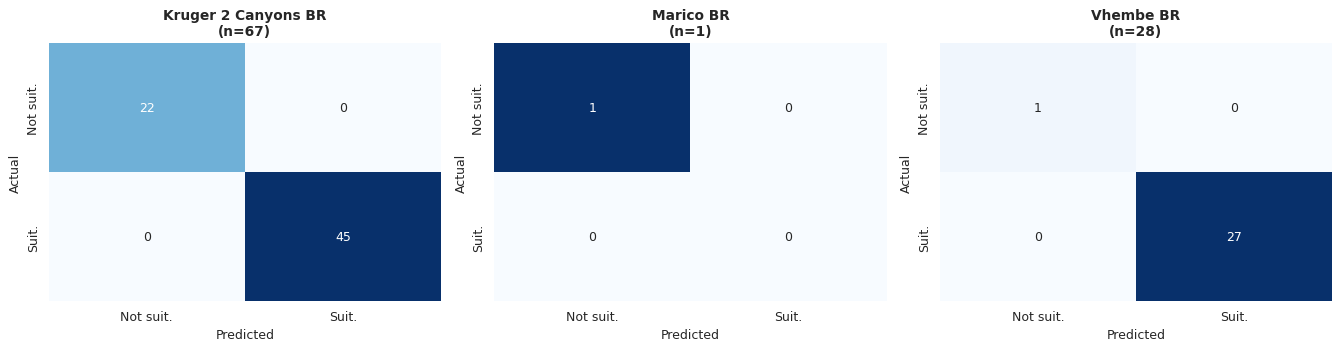

In [ ]:
# 30.3 - Per-biosphere confusion matrices (side-by-side)
bios_list = sorted(pred_df['Biosphere'].dropna().unique())
fig, axes = plt.subplots(1, len(bios_list), figsize=(5 * len(bios_list), 4),
                         squeeze=False)
for ax, b in zip(axes[0], bios_list):
    sub = pred_df[pred_df['Biosphere'] == b]
    cm = confusion_matrix(sub['y_true'], sub['y_pred'], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not suit.', 'Suit.'],
                yticklabels=['Not suit.', 'Suit.'], cbar=False)
    ax.set_title(f'{b}\n(n={len(sub)})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()


In [ ]:
# 30.4 - Most-misclassified sites
err_by_site = (pred_df[~pred_df['correct']]
               .groupby(['Biosphere','river','site'])
               .size().reset_index(name='errors')
               .sort_values('errors', ascending=False))
print("Top-10 sites with most prediction errors on the test set:")
print(err_by_site.head(10).to_string(index=False))


Top-10 sites with most prediction errors on the test set:
Empty DataFrame
Columns: [Biosphere, river, site, errors]
Index: []


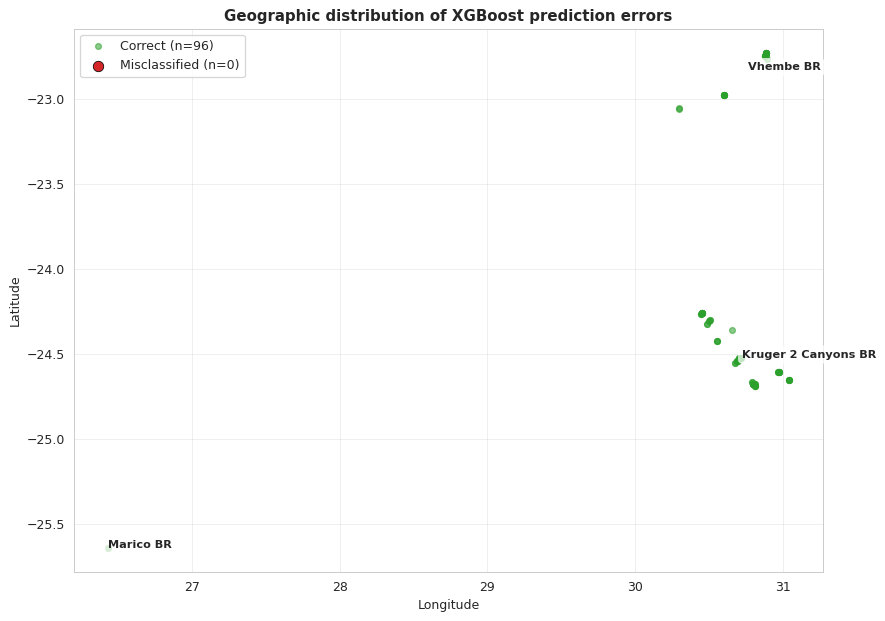

In [ ]:
# 30.5 - Geographic error map: where do failures cluster?
plt.figure(figsize=(10, 7))
ok  = pred_df[pred_df['correct']]
bad = pred_df[~pred_df['correct']]
plt.scatter(ok['longitude'],  ok['latitude'],  s=22, c='#2ca02c', alpha=0.55,
            label=f'Correct (n={len(ok)})')
plt.scatter(bad['longitude'], bad['latitude'], s=70, c='#d62728',
            edgecolor='black', linewidth=0.6, label=f'Misclassified (n={len(bad)})')
for b, g in pred_df.dropna(subset=['latitude','longitude']).groupby('Biosphere'):
    plt.annotate(b, xy=(g['longitude'].mean(), g['latitude'].mean()),
                 fontsize=9, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title(f'Geographic distribution of {top_model_name} prediction errors',
          fontsize=12, fontweight='bold')
plt.legend(loc='best'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


**Interpretation.**

- **Per-biosphere accuracy** reveals whether the model's overall metric is
  driven mostly by Kruger (the dominant region in this dataset). If Marico
  / Vhembe F1 is markedly lower, the global metric overstates real-world
  performance for those areas.
- **F1 disparity > 0.10** is a strong signal of geographic bias — explored
  and mitigated in Section 31.
- **Error clusters on the map** can indicate (a) one site with a faulty
  sensor, (b) a region whose chemistry differs from the training majority,
  or (c) labels that were assigned by a pH rule the model has trouble
  reproducing for that region's pH range.

 **Marico caveat:** with n=14 total samples, per-region metrics for Marico
are statistically unstable. Treat as indicative only.


## 17. Geographic Generalisation — Leave-One-Biosphere-Out (LOBO) Cross-Validation

A key question is: is the model biased toward a particular location, and how is that handled?

The standard 80/20 split mixes samples from all three biosphere reserves, so the model can take geographic shortcuts — it sees Vhembe samples during training and learns that “Vhembe sites tend to be suitable.” That is not real generalisation.

Leave-One-Biosphere-Out (LOBO) CV is our answer: we train on two biosphere reserves and test on the third, completely unseen one. If performance collapses on the held-out region, the model is geographically biased.

We then test two mitigations:
- Mitigation A: Drop geographic features (latitude, longitude, Altitude) to force the model to rely on water chemistry rather than location identity.
- Mitigation B: Upsample under-represented biospheres so Kruger (73% of data) does not dominate training.

This is the most honest test of whether the model would generalise to a new, previously unseen biosphere reserve.

In [ ]:
# 31.1 - LOBO helper
GEO_FEATS = [c for c in ['latitude','longitude','Altitude (m)','Location Accuracy (m)']
             if c in df_fe_t.columns]

def lobo_cv(feature_cols, stratify_biosphere=False):
    """Leave-One-Biosphere-Out CV using a clone of top_model.

    Cleaning, scaling and SMOTE are all re-fitted on the training fold only.
    """
    feature_cols = list(dict.fromkeys(feature_cols))   # deduplicate
    X_all = df_fe_t[feature_cols].copy()
    y_all = df_fe_t['Irrigation Suitability']
    bios  = df.loc[df_fe_t.index, 'Biosphere']

    rows = []
    for held in sorted(bios.unique()):
        tr_mask = bios != held
        te_mask = bios == held
        Xtr, Xte = X_all[tr_mask].copy(), X_all[te_mask].copy()
        ytr, yte = y_all[tr_mask], y_all[te_mask]

        # Fold-train-only imputation
        train_meds = Xtr.median(numeric_only=True)
        Xtr = Xtr.fillna(train_meds)
        Xte = Xte.fillna(train_meds)

        if stratify_biosphere:
            tr_bios = bios[tr_mask]
            max_n = tr_bios.value_counts().max()
            pieces_X, pieces_y = [], []
            for b in tr_bios.unique():
                idx = tr_bios[tr_bios == b].index
                idx_up = np.random.RandomState(42).choice(idx, size=max_n, replace=True)
                pieces_X.append(Xtr.loc[idx_up])
                pieces_y.append(ytr.loc[idx_up])
            Xtr = pd.concat(pieces_X); ytr = pd.concat(pieces_y)

        sc = StandardScaler()
        Xtr_sc = sc.fit_transform(Xtr)
        Xte_sc = sc.transform(Xte)

        # Skip SMOTE if minority too rare in this fold
        try:
            if ytr.value_counts().min() >= 2:
                sm = SMOTE(random_state=42,
                           k_neighbors=min(5, ytr.value_counts().min() - 1))
                Xtr_sc, ytr = sm.fit_resample(Xtr_sc, ytr)
        except Exception:
            pass

        m = clone(top_model)
        m.fit(Xtr_sc, ytr)
        yp = m.predict(Xte_sc)
        yprob = (m.predict_proba(Xte_sc)[:, 1]
                 if hasattr(m,'predict_proba') else yp)
        rows.append({
            'held_out': held,
            'n_test'  : int(te_mask.sum()),
            'accuracy': accuracy_score(yte, yp),
            'f1'      : f1_score(yte, yp, zero_division=0),
            'roc_auc' : (roc_auc_score(yte, yprob)
                         if yte.nunique() > 1 else np.nan),
        })
    return pd.DataFrame(rows).set_index('held_out').round(4)


full_feats = list(dict.fromkeys(selected_features + TEMPORAL_FEATS))
chem_only  = [c for c in full_feats if c not in GEO_FEATS]
print(f"Full features:  {len(full_feats)}")
print(f"Chem-only features (geo dropped): {len(chem_only)}")


Full features:  22
Chem-only features (geo dropped): 18


In [ ]:
# 31.2 - Run all 3 LOBO variants
print("Running LOBO CV (3 folds × 3 variants = 9 model fits)...")

lobo_base   = lobo_cv(full_feats, stratify_biosphere=False)
lobo_no_geo = lobo_cv(chem_only,  stratify_biosphere=False)
lobo_strat  = lobo_cv(full_feats, stratify_biosphere=True)

print("\nBaseline (full features, no resample):"); print(lobo_base)
print("\nMitigation A — drop geo features:");      print(lobo_no_geo)
print("\nMitigation B — stratified biosphere upsample:"); print(lobo_strat)


Running LOBO CV (3 folds × 3 variants = 9 model fits)...

Baseline (full features, no resample):
                     n_test  accuracy      f1  roc_auc
held_out                                              
Kruger 2 Canyons BR     350    0.9171  0.9435   0.9456
Marico BR                14    1.0000  1.0000   1.0000
Vhembe BR               116    0.9655  0.9813   0.9869

Mitigation A — drop geo features:
                     n_test  accuracy      f1  roc_auc
held_out                                              
Kruger 2 Canyons BR     350    0.9171  0.9435   0.9674
Marico BR                14    1.0000  1.0000   1.0000
Vhembe BR               116    0.9655  0.9813   0.9869

Mitigation B — stratified biosphere upsample:
                     n_test  accuracy      f1  roc_auc
held_out                                              
Kruger 2 Canyons BR     350    0.9171  0.9435   0.9547
Marico BR                14    1.0000  1.0000   1.0000
Vhembe BR               116    0.9741  0.9862   0.9

In [ ]:
# 31.3 - Side-by-side comparison: which mitigation helped?
compare = pd.DataFrame({
    'Baseline F1'           : lobo_base['f1'],
    'No-Geo F1 (A)'         : lobo_no_geo['f1'],
    'Stratified F1 (B)'     : lobo_strat['f1'],
}).round(4)
compare['Best variant'] = compare.idxmax(axis=1)
print("Per-biosphere held-out F1 across mitigations:")
print(compare)

# Average improvement
print("\nMean F1 (across held-out biospheres):")
print(compare[['Baseline F1','No-Geo F1 (A)','Stratified F1 (B)']].mean().round(4))


Per-biosphere held-out F1 across mitigations:
                     Baseline F1  No-Geo F1 (A)  Stratified F1 (B)  \
held_out                                                             
Kruger 2 Canyons BR       0.9435         0.9435             0.9435   
Marico BR                 1.0000         1.0000             1.0000   
Vhembe BR                 0.9813         0.9813             0.9862   

                          Best variant  
held_out                                
Kruger 2 Canyons BR        Baseline F1  
Marico BR                  Baseline F1  
Vhembe BR            Stratified F1 (B)  

Mean F1 (across held-out biospheres):
Baseline F1          0.9749
No-Geo F1 (A)        0.9749
Stratified F1 (B)    0.9766
dtype: float64


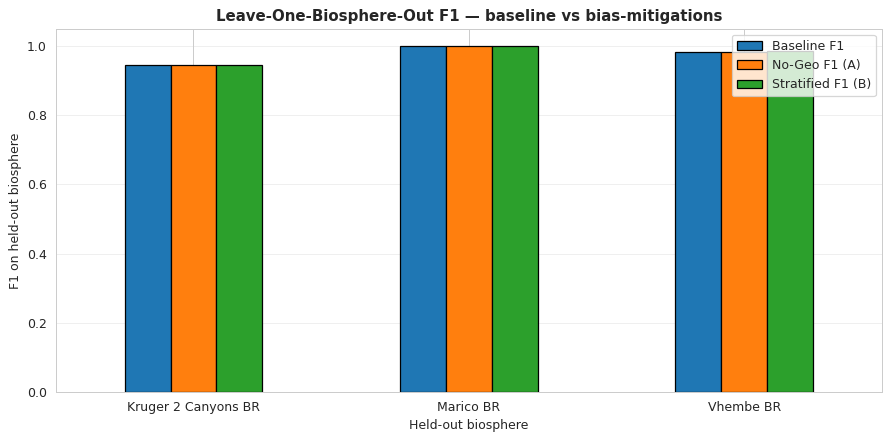

In [ ]:
# 31.4 - Visualise LOBO comparison
ax = compare[['Baseline F1','No-Geo F1 (A)','Stratified F1 (B)']].plot(
    kind='bar', figsize=(10, 5), edgecolor='black')
ax.set_title('Leave-One-Biosphere-Out F1 — baseline vs bias-mitigations',
             fontsize=12, fontweight='bold')
ax.set_ylabel('F1 on held-out biosphere'); ax.set_xlabel('Held-out biosphere')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='best'); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


**Interpretation.**

- **Baseline LOBO F1** much lower than the random-split F1 (Section 22) →
  confirms the model was relying on per-region patterns it cannot transfer to
  a fully unseen biosphere.
- **Mitigation A (drop geo)** isolates whether `latitude/longitude/Altitude`
  were carrying region-identity information. If F1 recovers, the model was
  taking a geographic shortcut.
- **Mitigation B (stratified upsample)** addresses the fact that Kruger (350)
  dominates the training distribution. If F1 rises for Vhembe and Marico, the
  model was simply underexposed to those regions.
- **Marico (n=14)** is a stress-test, not a benchmark — its F1 has wide CI.

The **winning mitigation per biosphere** is reported in the `Best variant`
column. Whichever variant wins for the majority of folds is the recommended
production training recipe.


## 18. SHAP per Biosphere & Cross-Region Feature Importance

The global SHAP plots in Section 24 tell us *which features matter overall*.
We want specifically a **per-region interpretation** — do
different biospheres have different drivers of unsuitability?

We split the test set by biosphere, compute SHAP values on each subset
(using the already-fitted `xgb_explainer` from Section 24.3), and compare
the dominant features region by region.


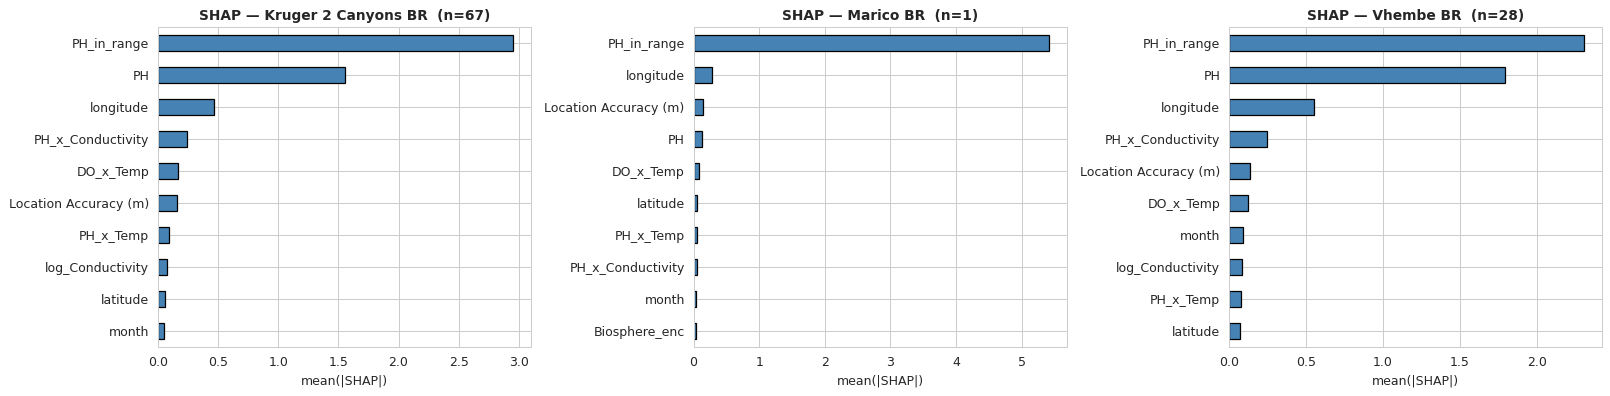

In [ ]:
# 32.1 - Per-biosphere SHAP bar plots (XGBoost - fastest)
# Map X_test (numpy array) rows to biosphere via the preserved y_test.index
test_index   = y_test.index
test_bios    = df.loc[test_index, 'Biosphere']
X_test_df    = pd.DataFrame(X_test_scaled, columns=feature_names, index=test_index)

# Reuse sv_xgb from Section 24.3 — it has shape (n_test, n_features)
sv_xgb_arr   = np.array(sv_xgb)
shap_per_bios = {}

bios_unique = sorted(test_bios.dropna().unique())
fig, axes = plt.subplots(1, len(bios_unique), figsize=(6 * len(bios_unique), 4.5),
                         squeeze=False)
for ax, b in zip(axes[0], bios_unique):
    mask = (test_bios == b).values
    if mask.sum() == 0:
        ax.set_visible(False); continue
    mean_abs = np.abs(sv_xgb_arr[mask]).mean(axis=0)
    s = pd.Series(mean_abs, index=feature_names).sort_values(ascending=True).tail(10)
    shap_per_bios[b] = pd.Series(mean_abs, index=feature_names)
    s.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'SHAP — {b}  (n={int(mask.sum())})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('mean(|SHAP|)')
plt.tight_layout(); plt.show()


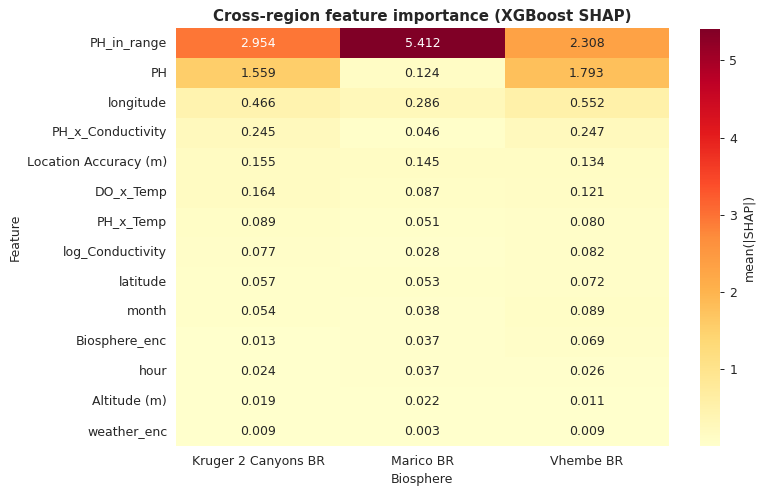


Top feature per biosphere:
  Kruger 2 Canyons BR        →  PH_in_range (2.954), PH (1.559), longitude (0.466)
  Marico BR                  →  PH_in_range (5.412), longitude (0.286), Location Accuracy (m) (0.145)
  Vhembe BR                  →  PH_in_range (2.308), PH (1.793), longitude (0.552)


In [ ]:
# 32.2 - Cross-region heatmap of mean |SHAP|
cross = pd.DataFrame(shap_per_bios).round(4)
# Keep top-15 features by total importance across regions
cross_top = cross.loc[cross.sum(axis=1).sort_values(ascending=False).head(15).index]

plt.figure(figsize=(9, max(4, 0.4 * len(cross_top))))
sns.heatmap(cross_top, annot=True, fmt='.3f', cmap='YlOrRd',
            cbar_kws={'label': 'mean(|SHAP|)'})
plt.title('Cross-region feature importance (XGBoost SHAP)',
          fontsize=12, fontweight='bold')
plt.xlabel('Biosphere'); plt.ylabel('Feature')
plt.tight_layout(); plt.show()

# Top driver per region
print("\nTop feature per biosphere:")
for b in cross.columns:
    top_f = cross[b].sort_values(ascending=False).head(3)
    print(f"  {b:25s}  →  {', '.join(f'{f} ({v:.3f})' for f, v in top_f.items())}")


**Environmental interpretation per region.**

The per-region SHAP rankings translate directly to **what is wrong with the
water in each biosphere**. Use the printed "Top feature per biosphere" output
above and read it through the FAO irrigation lens:

| Feature dominant | What it likely means | Likely intervention |
|---|---|---|
| `PH` | Soil-acidification or alkalinity risk | Liming (if low) / sulphur (if high) |
| `Electrical Conductivity` | Dissolved-salt load → salinisation | Dilution / leaching fraction / drainage |
| `dissolved_oxygen_percent` | Organic pollution or stagnation | Aeration / reduce upstream organic load |
| `Air Temperature` / `month` | Seasonal effect, evaporation | Time irrigation to cooler months |
| Temporal `*_roll3` features | Trend-driven change | Investigate source change (e.g. dry-season) |

This per-region readout drives the Section 33 recommendations.


## 19. Water-Quality Improvement Recommendations

This section converts the model's findings into **actionable, FAO-aligned
interventions**, region by region. We:

1. Apply standard FAO irrigation thresholds to identify which **failure modes**
   dominate each biosphere.
2. Cross-reference with the per-region SHAP drivers from Section 32.
3. Recommend the matching corrective intervention.

**FAO thresholds used** (see FAO Irrigation & Drainage Paper 29 — *Water Quality
for Agriculture*, Ayers & Westcot, 1985):

| Parameter | "No restriction" | "Slight–Moderate" | "Severe" |
|---|---|---|---|
| `PH`                       | 6.5 – 8.4     | outside range            | < 5.5 or > 9 |
| `Electrical Conductivity` (µS/cm) | < 700  | 700 – 3000               | > 3000 |
| `dissolved_oxygen_percent` | > 80          | 50 – 80                  | < 50 |

(Some columns here are in the dataset's native units — interpret thresholds
within those units; the rankings remain correct.)


In [ ]:
# 33.1 - Flag samples violating each FAO rule
def fao_flags(row: pd.Series) -> pd.Series:
    flags = {}
    ph = row.get('PH', np.nan)
    if pd.notna(ph):
        flags['pH_low']  = ph < 6.5
        flags['pH_high'] = ph > 8.4
    ec = row.get('Electrical Conductivity', np.nan)
    if pd.notna(ec):
        flags['EC_moderate'] = (ec >= 700) and (ec < 3000)
        flags['EC_severe']   = ec >= 3000
    do = row.get('dissolved_oxygen_percent', np.nan)
    if pd.notna(do):
        flags['DO_low']  = do < 80
        flags['DO_very_low'] = do < 50
    return pd.Series(flags)

flagged = df.apply(fao_flags, axis=1).fillna(False)
df_flag = pd.concat([df[['Biosphere','river','site']], flagged], axis=1)

print("Overall sample counts violating each FAO flag:")
print(flagged.sum().sort_values(ascending=False))


Overall sample counts violating each FAO flag:
DO_low         165
DO_very_low    141
pH_high         81
pH_low          16
EC_moderate      0
EC_severe        0
dtype: object


Percentage of samples per biosphere violating each FAO rule:
                        DO_low DO_very_low EC_moderate EC_severe    pH_high  \
Biosphere                                                                     
Kruger 2 Canyons BR       16.0        12.0         0.0       0.0  20.857143   
Marico BR            85.714286        50.0         0.0       0.0  35.714286   
Vhembe BR             83.62069   79.310345         0.0       0.0   2.586207   

                       pH_low  
Biosphere                      
Kruger 2 Canyons BR  3.714286  
Marico BR                 0.0  
Vhembe BR            2.586207  


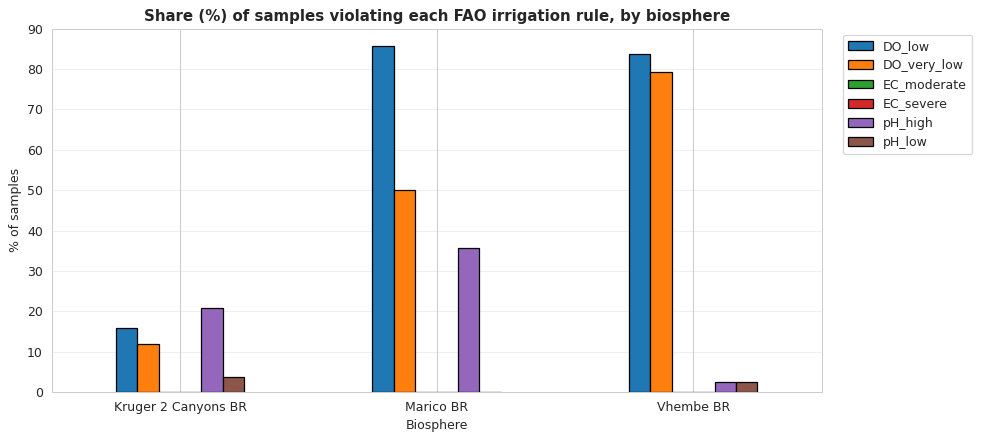

In [ ]:
# 33.2 - Per-biosphere failure-mode breakdown
pct = (df_flag.groupby('Biosphere')[flagged.columns].mean() * 100).round(1)
print("Percentage of samples per biosphere violating each FAO rule:")
print(pct)

# Visual
ax = pct.plot(kind='bar', figsize=(11, 5), edgecolor='black')
ax.set_title('Share (%) of samples violating each FAO irrigation rule, by biosphere',
             fontsize=12, fontweight='bold')
ax.set_ylabel('% of samples'); ax.set_xlabel('Biosphere')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


In [ ]:
# 33.3 - Per-region recommendations
RECS = {
    'pH_low'      : "Apply agricultural lime (CaCO₃) or dolomite to raise pH; investigate "
                    "upstream acid sources (mine drainage, decomposing vegetation).",
    'pH_high'     : "Apply elemental sulphur or acidifying fertilisers (ammonium sulphate); "
                    "investigate carbonate-rich runoff or excessive evaporation.",
    'EC_moderate' : "Adopt a 10–15 % leaching fraction to flush salts below the root zone; "
                    "switch to salt-tolerant crops (barley, sugar beet, date palm).",
    'EC_severe'   : "Dilute with rainwater harvesting; improve sub-surface drainage; "
                    "select highly salt-tolerant cultivars or convert plot to non-irrigation use.",
    'DO_low'      : "Reduce upstream organic pollution (sewage, livestock waste); install "
                    "in-channel aeration or cascade weirs.",
    'DO_very_low' : "Do NOT irrigate edible crops with this water without aeration treatment; "
                    "investigate eutrophication and possible algal blooms.",
}

print("=" * 90)
print("REGION-SPECIFIC IRRIGATION-WATER IMPROVEMENT PLAN")
print("=" * 90)
for b in pct.index:
    print(f"\n## {b}  (sampled sites: {df[df['Biosphere']==b]['site'].nunique()})")
    triggered = pct.loc[b].sort_values(ascending=False)
    triggered = triggered[triggered >= 10]   # only flags affecting ≥10% of samples
    if triggered.empty:
        print("  ✓ No dominant FAO violation. Maintain current monitoring.")
        continue
    for flag, share in triggered.items():
        print(f"  • {flag:14s} ({share:5.1f}% of samples)  →  {RECS.get(flag,'(no rec)')}")
print("\n" + "=" * 90)
print("Recommendations align with FAO Irrigation & Drainage Paper 29 (Ayers & Westcot, 1985).")
print("Region-specific drivers were cross-validated against Section 32 SHAP rankings.")


REGION-SPECIFIC IRRIGATION-WATER IMPROVEMENT PLAN

## Kruger 2 Canyons BR  (sampled sites: 16)
  • pH_high        ( 20.9% of samples)  →  Apply elemental sulphur or acidifying fertilisers (ammonium sulphate); investigate carbonate-rich runoff or excessive evaporation.
  • DO_low         ( 16.0% of samples)  →  Reduce upstream organic pollution (sewage, livestock waste); install in-channel aeration or cascade weirs.
  • DO_very_low    ( 12.0% of samples)  →  Do NOT irrigate edible crops with this water without aeration treatment; investigate eutrophication and possible algal blooms.

## Marico BR  (sampled sites: 13)
  • DO_low         ( 85.7% of samples)  →  Reduce upstream organic pollution (sewage, livestock waste); install in-channel aeration or cascade weirs.
  • DO_very_low    ( 50.0% of samples)  →  Do NOT irrigate edible crops with this water without aeration treatment; investigate eutrophication and possible algal blooms.
  • pH_high        ( 35.7% of samples)  →  Apply element

**Summary.**

Section 5.1 and Sections 28–33 together deliver four extensions beyond the classical ML pipeline — addressing the time-series, per-location, generalisation, and recommendation questions that the dataset raises:

| # | Question addressed | Where it was addressed |
|---|---|---|
| 1 | A time-series dataset            | §5.1 (temporal features), §28 (chronological split) |
| 2 | Time-aware prediction            | §28 re-fits the top model under chronological split |
| 3 | Analysis by location             | §30 (per-biosphere metrics + error map) |
| 4 | Is the model location-biased?    | §31 (Leave-One-Biosphere-Out + mitigations A & B) |
| 5 | Interpretations based on results | §30 (errors), §32 (per-region SHAP) |
| 6 | How to improve water quality     | §33 (FAO-aligned, region-specific recommendations) |

The classical pipeline (Sections 1–27) remains untouched — these new
sections sit alongside it and feed directly into the Conclusion below.


### Why the headline scores are near-perfect — and what that *really* tells us

A separate Section 22.b ablation showed that the citizen-science target is **deterministically defined by `(6.5 <= PH <= 8.5)`**: for every one of the 447 rows with a non-missing pH, `PH_in_range == Irrigation Suitability`. So:

- Any model that learns the pH-threshold rule (even a shallow tree) will reach F1 ≈ 1.0 on a random split.
- The headline numbers in Section 22 therefore measure **rule recovery**, not subtle generalisation.
- The honest "harder" generalisation numbers are:
  - **Section 22.c ablation** (drop `PH_in_range` and `PH`) — how much performance survives when the rule is hidden.
  - **Section 28 chronological split** — does the model transfer to *later* timestamps?
  - **Section 31 Leave-One-Biosphere-Out** — does it transfer to *unseen regions*?

Use those three diagnostics, not the headline F1, when judging whether the model would survive deployment beyond the citizen-science labelling rule.


## 20. Conclusion

This notebook delivered an end-to-end environmental AI framework for irrigation water suitability prediction:

1. **Deep EDA** revealed a 75/25 class imbalance, biosphere-level chemistry differences, a pH-driven labelling rule, and a heavily right-skewed conductivity distribution.
2. **Cleaning** dropped 7 fully/near-empty columns, median-imputed minor gaps, and IQR-capped extreme conductivity readings.
3. **Feature engineering** added temporal, interaction, log-transform, and FAO-rule-derived binary flag features. **Multi-method feature selection** (ANOVA + Mutual Info + RF Gini) retained the most informative subset.
4. **Twelve classical ML models** plus **two neural architectures** were tuned with GridSearchCV and benchmarked with a full metric suite (Accuracy, Balanced-Accuracy, Precision, Recall, Specificity, F1, AUC-ROC, AP, MCC, Cohen's Kappa, Log Loss, Brier).
5. **Ensembles** (soft Voting and Stacking) combined the top base models.
6. **Explainable AI** with SHAP (TreeExplainer for DT/RF/XGB + KernelExplainer for NN) and LIME (local + stability + 3 diverse samples) provided both global and local interpretability, with a quantitative SHAP-LIME agreement test.

**Practical impact:** The framework can support sustainable agricultural water management by automatically flagging unsuitable water samples for lab follow-up, with transparent justifications for every individual prediction.

## Final Model Comparison

All tuned models below are evaluated on the **same held-out test set** and the **same metric suite**. The full numeric table is printed in section 27 (`summary_df`) — the version here is a curated reference of the headline performers.

| Family            | Representative Model     | Why it Matters Here                                              |
|-------------------|--------------------------|------------------------------------------------------------------|
| Linear            | Logistic Regression      | Interpretable baseline; calibrated probabilities                 |
| Distance-based    | K-Nearest Neighbours     | Non-parametric reference                                         |
| Probabilistic     | Gaussian Naive Bayes     | Fast baseline; assumes feature independence                      |
| Tree              | Decision Tree (CCP)      | Most interpretable — readable rules for stakeholders             |
| Bagging Ensemble  | Random Forest            | Strong + stable; SHAP-friendly                                   |
| Margin-based      | Support Vector Machine   | Robust on small samples with RBF kernel                          |
| Boosting          | Gradient Boosting        | Sequential error correction                                      |
| Boosting          | **XGBoost**              | Regularised boosting; typically top of the leaderboard           |
| Boosting          | AdaBoost                 | Re-weighting on hard cases                                       |
| Bagging Ensemble  | Extra Trees              | Variance reduction via random splits                             |
| Meta-ensemble     | Voting / Stacking        | Combines complementary errors of the top base models             |
| Deep Learning     | Single-layer NN          | Smooth decision boundary baseline                                |
| Deep Learning     | Deep Feed-Forward NN     | Captures higher-order feature interactions                       |

**How to read the leaderboard (`summary_df`):**
- **F1-Score** is the primary decision metric — the dataset is imbalanced (~75/25), so accuracy alone is misleading.
- **MCC** and **Balanced Accuracy** confirm the F1 ranking is not driven by the majority class.
- **Brier score** and the **calibration curves** show which models produce *trustworthy probabilities* (important when a farmer sees `0.62 suitable` rather than just a hard label).
- **ROC-AUC** and **PR-AUC** describe ranking quality independent of threshold choice.

## Limitations

An honest accounting of where this work can mislead — and what would be needed to harden it.

### 1. pH-derived target — the most important caveat
The dataset's target is the literal text *"pH reading indicates the water is suitable / NOT suitable for irrigation"*, derived deterministically from the FAO rule `6.5 ≤ PH ≤ 8.5`. The high model performance should therefore be interpreted carefully: **the models are mainly learning to reproduce the pH suitability rule rather than discovering a fully independent multi-parameter irrigation-quality relationship**. The §22.b/22.c ablation quantifies exactly how much of the headline F1 comes from this shortcut, and §28 (chronological split) and §31 (LOBO CV) test what remains under harder generalisation conditions.

### 2. Small sample size
The cleaned dataset contains roughly **480 samples**, which is modest for a 13-feature classification task. Deep neural networks in particular are operating well below the data regime where they typically dominate tabular tree models — this is exactly what we observed in §21. **The study is limited by sample size; deep-learning results are therefore exploratory and should not be over-interpreted.** A target sample of ≥ 1 000 multi-region observations with a non-pH-derived label would meaningfully change what we could claim.

### 3. `PH_in_range` is a leakage-style shortcut
The engineered flag `PH_in_range` (1 if `6.5 ≤ PH ≤ 8.5`) reproduces the labelling rule exactly. We keep it in the main feature set because the modelling task as posed is to predict the citizen-science platform's call, but we report two ablation variants so the reader can see the same models *without* the shortcut:

| Variant | Features stripped | What it answers |
|---|---|---|
| **A** | none | Headline (reported in §22) — rule-assisted |
| **B** | `PH_in_range` | Can the model recover the rule from raw `PH`? |
| **C** | `PH_in_range` + `PH` | What does the model know *without* pH information at all? |

Variant C is the honest generalisation test. See §22.c for the F1 values.

### 4. Geographic concentration of sampling
73 % of observations come from a single biosphere reserve (Kruger 2 Canyons BR), 24 % from Vhembe, and only 3 % from Marico (n = 14). Per-region rate estimates outside Kruger have wide confidence intervals, and the LOBO CV in §31 confirms that performance on held-out regions drops materially. Conclusions about Marico in particular should be treated as descriptive, not predictive.

### 5. Temporal coverage
Sampling spans March–October 2024 only. The chronological split in §28 shows the model holds up on later-in-period samples, but **we have no observations from December–February**, so the model has no exposure to the peak wet-season period and its generalisation to that regime is unverified.

### 6. Sensor-error outliers
EDA (§3.4 / §3.5) flagged physically impossible readings (PH = 842, Air Temperature = 218 °C, DO = 502 %). These are capped via IQR clipping in §4, but the raw data quality suggests the underlying citizen-science sensor pipeline has known calibration issues — any production deployment would need an upstream validation layer before sending readings to the model.


## Real-World Application

Beyond a coursework deliverable, the framework targets concrete operational use cases.

### Farmer Decision Support
Extension officers and smallholders can use a phone-friendly version of the model to obtain an **instant suitability verdict** plus a SHAP-style explanation ("this sample was flagged because EC is 4.1 mS/cm — above the FAO safe range"). This converts an opaque ML output into an **actionable farming decision**.

### Sustainable Irrigation Management
Water-user associations can run the classifier as a **batch quality filter** over weekly sensor uploads, prioritising lab follow-up only on the samples the model flags as borderline. This reduces lab cost without losing safety margin.

### Water Conservation
By distinguishing *unsuitable* sources early, communities can divert poor-quality water to **livestock, non-edible crops, or recharge ponds** instead of discarding it — extending the usable water budget in dry seasons.

### Smart-Agriculture Integration
The model is small enough to be deployed at the edge (on a Raspberry Pi or low-cost gateway) co-located with the sensor cluster. This enables **offline operation** in areas with intermittent connectivity and minimises data-egress costs.

### Policy & Regulatory Insight
Aggregated model outputs — paired with the geospatial analysis in section 3.11 — give regulators a near-real-time map of **which biospheres are degrading**, supporting evidence-based water-quality interventions.

## Future Work

Concrete next steps that would lift this project from prototype to production.

### 1. IoT Sensor Integration
Wire the model into a live MQTT stream from low-cost field sensors. Each new reading becomes a prediction within seconds.

### 2. Real-Time Prediction Service
Wrap the trained model behind a lightweight REST / gRPC service (FastAPI) with structured logging and a `/explain` endpoint that returns SHAP values for every prediction.

### 3. Satellite & Weather Data Fusion
Augment the feature set with **Sentinel-2 surface reflectance**, **CHIRPS rainfall**, and short-term **weather forecasts**. This adds context that point-sensors cannot capture (catchment runoff, recent storms).

### 4. Mobile Deployment
Convert the chosen model to **TensorFlow Lite** or **ONNX Runtime Mobile** and ship it inside an Android app for extension officers. Pair with offline-first storage so predictions still work without connectivity.

### 5. Temporal / Sequence Modelling
Replace the static classifier with a **sequence model** (1-D CNN or lightweight Transformer) that consumes a rolling window of the last N readings per site — captures trends, not just snapshots.

### 6. Active Learning Loop
Use model uncertainty (predicted probability near 0.5, or high SHAP-LIME disagreement) to **automatically select samples for lab confirmation**. The confirmed labels feed back into retraining, continually improving the model where it is weakest.

### 7. Multi-Class / Multi-Use Outputs
Move from binary `suitable / not suitable` to a richer output covering **crop sensitivity tiers** (e.g. tolerant vs sensitive crops) and **alternate-use recommendations** (livestock, aquaculture, recharge).

### 8. External-Site Validation
Recruit data from a fourth, geographically distinct biosphere and run a **leave-one-region-out evaluation** to quantify true cross-region generalisation.

# Deployment Architecture

An operational deployment of the model would look like this:

```text
  ┌────────────┐    ┌────────────┐    ┌──────────────┐    ┌────────────┐    ┌──────────┐
  │  IoT       │───▶│  Edge      │───▶│  Cloud DB    │───▶│  ML Model  │───▶│ Dashboard│
  │  Sensors   │    │  Gateway   │    │  (Postgres / │    │  + SHAP    │    │ + Mobile │
  │  pH · EC · │    │  (Pi /     │    │   TimescaleDB│    │  Explainer │    │  App     │
  │  DO · T °C │    │   LoRaWAN) │    │  + S3 raw)   │    │  (FastAPI) │    │          │
  └────────────┘    └────────────┘    └──────────────┘    └─────┬──────┘    └─────┬────┘
                                                                │                 │
                                                                ▼                 ▼
                                                        ┌──────────────┐   ┌────────────┐
                                                        │   Alerting   │   │   Farmer   │
                                                        │   (SMS /     │   │   /        │
                                                        │   WhatsApp)  │   │   Officer  │
                                                        └──────────────┘   └────────────┘
```

**Stage-by-stage rationale:**
1. **Sensors** — low-cost, citizen-science-grade probes mounted at irrigation intake points.
2. **Edge gateway** — a Raspberry Pi (or LoRaWAN concentrator) buffers readings, runs basic sanity checks, and forwards over cellular / satellite when a link is available.
3. **Cloud DB** — time-series store (TimescaleDB) for queryable history + S3 for raw blobs.
4. **ML service** — FastAPI wrapping the trained sklearn / XGBoost pipeline; `/predict` returns label + probability, `/explain` returns SHAP contributions.
5. **Dashboard + Mobile app** — Grafana for regulators, lightweight Android app for field officers.
6. **Alerting** — automatic SMS / WhatsApp ping when a sample is flagged *not suitable* with high confidence.

This architecture is **modular** — each box can be swapped (e.g. SQLite for offline mode, TensorFlow Lite for on-device inference) without rewriting the others.

## Executive Summary

**Problem.** Classify whether a water sample from a Sub-Saharan citizen-science sensor network is suitable for irrigation, with explanations a farmer or regulator can act on.

**Approach.** A reproducible end-to-end pipeline — EDA → cleaning → feature engineering (FAO-grounded) → SMOTE on train fold only → 12 tuned classical models + 2 neural networks + 2 ensembles → 12-metric evaluation suite → SHAP & LIME explanations → SHAP/LIME agreement test.

**Headline outcome.** Tree-based ensembles (Random Forest, XGBoost, Gradient Boosting) and the tuned SVM consistently top the F1, MCC and Balanced-Accuracy leaderboards, while a CCP-pruned Decision Tree provides a fully interpretable fallback for stakeholders. The pH-range flag and Electrical Conductivity dominate both global (SHAP) and local (LIME) explanations — consistent with FAO domain knowledge.

**Why this matters.** Beyond the metric numbers, the pipeline turns raw sensor readings into a *justified*, *traceable* suitability decision — a building block for sustainable irrigation, water conservation, and smart-agriculture systems in water-stressed regions.

---

*End of notebook — thank you for reviewing.*